## 1. Tree-Based Methods

Import packages

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### (a) Read the APS Failure data (Original link is failed)

In [37]:

train = pd.read_csv(
    "../data/aps_failure_training_set.csv",
    na_values="na",
    skiprows=20
)

test = pd.read_csv(
    "../data/aps_failure_test_set.csv",
    na_values="na",
    skiprows=20
)

print(train.shape)
print(test.shape)

(60000, 171)
(16000, 171)


### (b) Data Preparation

#### (i) Research what types of techniques are usually used

1. Mean / Median Imputation: Use the specific feature mean or median to do the Imputation
2. Most Frequent: Use the most frequent value in the specific feature to do the Imputation
3. KNN Imputation : Use K-Nearest Neighbors to find similar samples and estimate missing values.
4. Model-based Imputation : Treat the missing feature as a target variable and use other features to predict missing values.
5. Indicator + Imputation : Perform imputation and add an indicator variable to mark missing values.

   In this case, I will choose Indicator with median imputation

In [38]:
from sklearn.impute import SimpleImputer
X_train = train.drop(columns=['class'])
y_train = train['class']

X_test = test.drop(columns=['class'])
y_test = test['class']

#Indicator with median imputation
imputer = SimpleImputer(strategy='median', add_indicator=True)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

feature_names = imputer.get_feature_names_out(X_train.columns)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=feature_names)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_names)
print(X_train_imputed.shape)
print(X_test_imputed.shape)

(60000, 339)
(16000, 339)


In [39]:
X_train_imputed

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,missingindicator_ee_002,missingindicator_ee_003,missingindicator_ee_004,missingindicator_ee_005,missingindicator_ee_006,missingindicator_ee_007,missingindicator_ee_008,missingindicator_ee_009,missingindicator_ef_000,missingindicator_eg_000
0,76698.0,0.0,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,33058.0,0.0,0.000000e+00,126.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,41040.0,0.0,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,12.0,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60874.0,0.0,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,153002.0,0.0,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,2564.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59996,2286.0,0.0,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,112.0,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59998,80292.0,0.0,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### (ii) Calculate the coefficient of variation

In [40]:
X_train_original = X_train_imputed.iloc[:, :170]
means = np.mean(X_train_original, axis=0)
stds = np.std(X_train_original, axis=0)

cv = stds / means.replace(0, np.nan)

cv_df = pd.DataFrame({
    'feature': X_train.columns,  
    'CV': cv
}).sort_values(by='CV', ascending=False)

print(cv_df.head())

       feature          CV
cf_000  cf_000  244.885476
co_000  co_000  244.505347
ad_000  ad_000  244.320780
cs_009  cs_009  237.928571
dh_000  dh_000  123.215070


#### (iii) Plot a correlation matrix

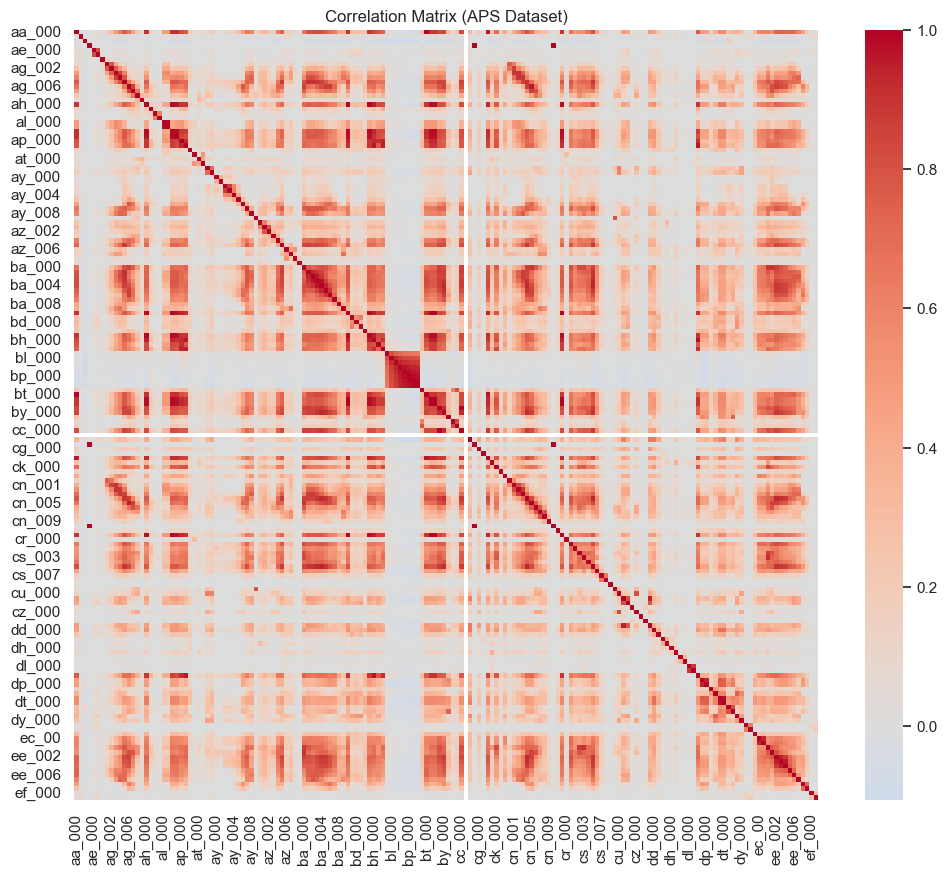

In [41]:
from matplotlib.colors import ListedColormap
corr_matrix = X_train_original.corr()

# 畫 heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (APS Dataset)")
plt.show()

#### (iv) Make scatter plots and box plots

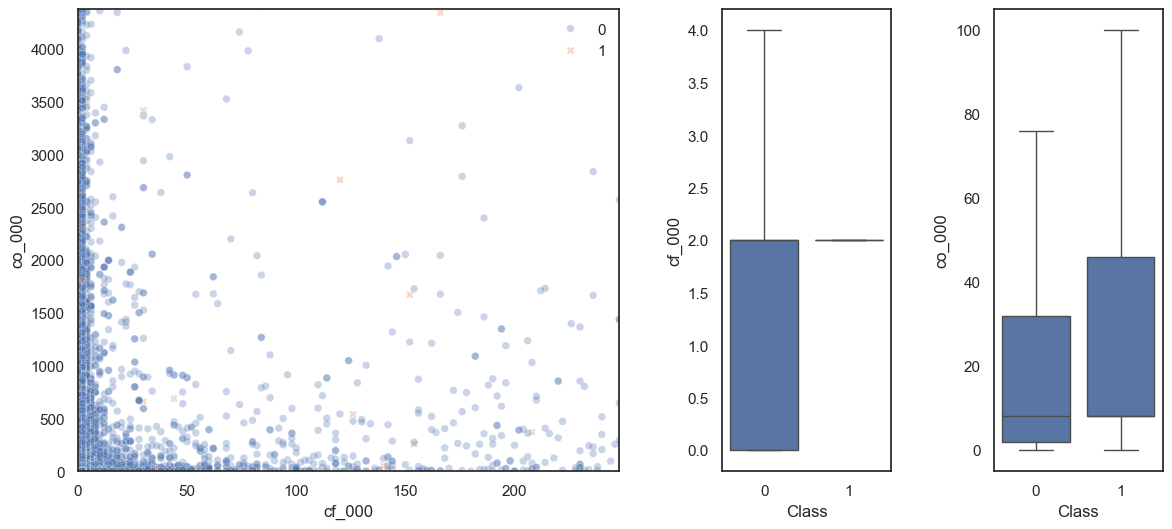

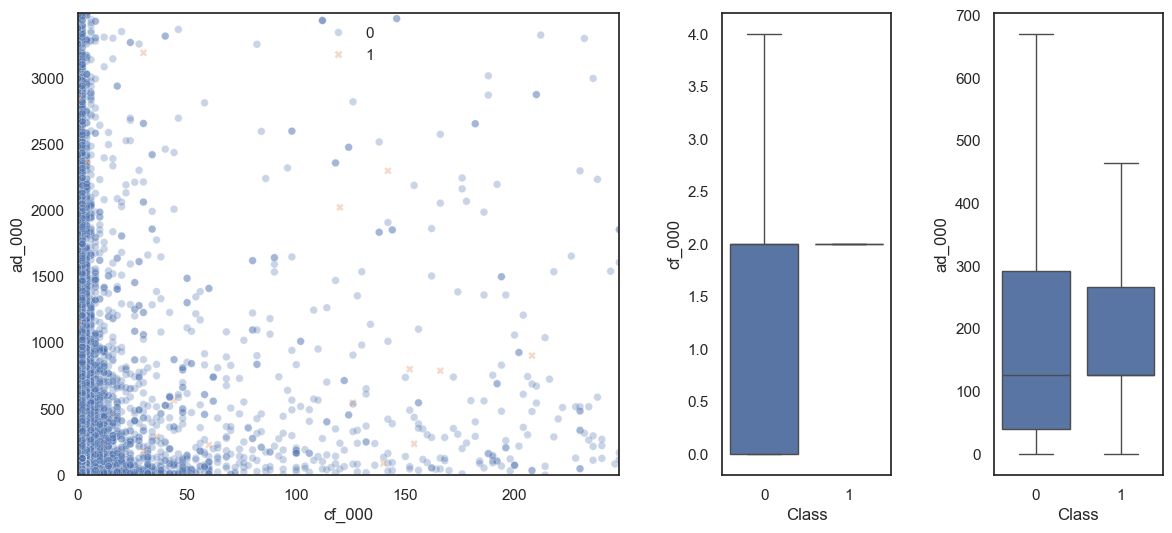

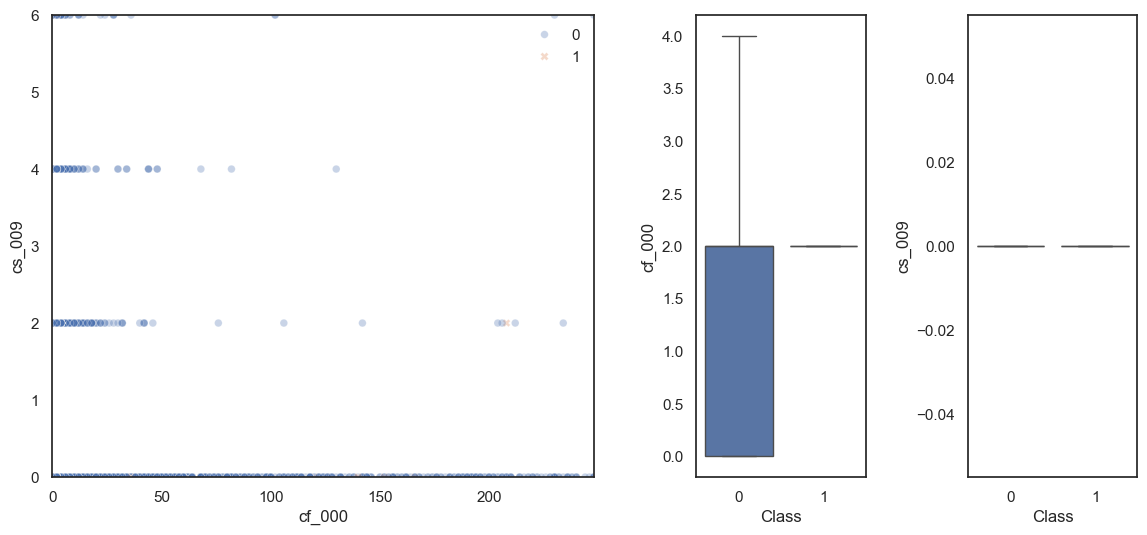

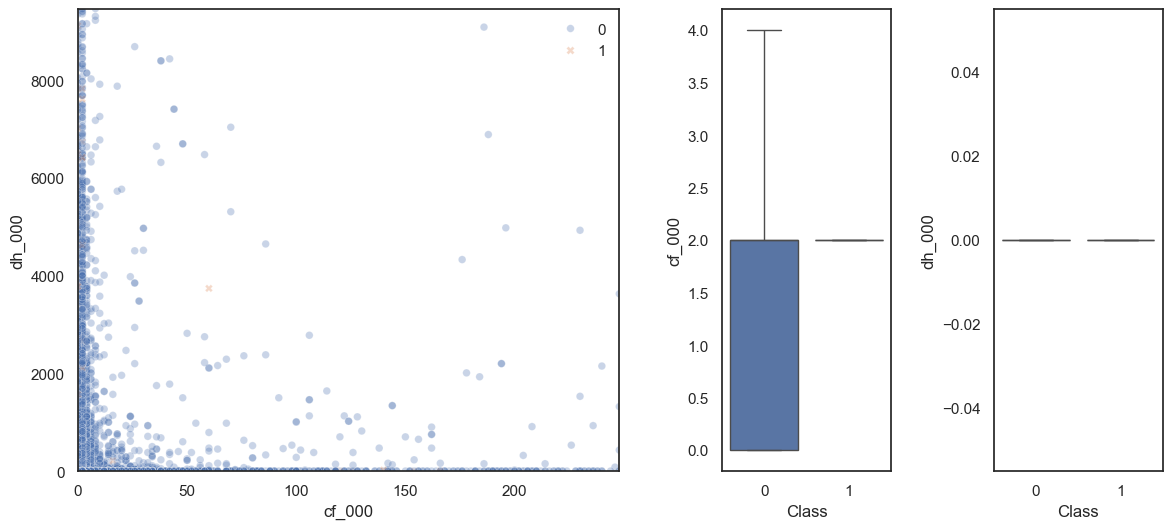

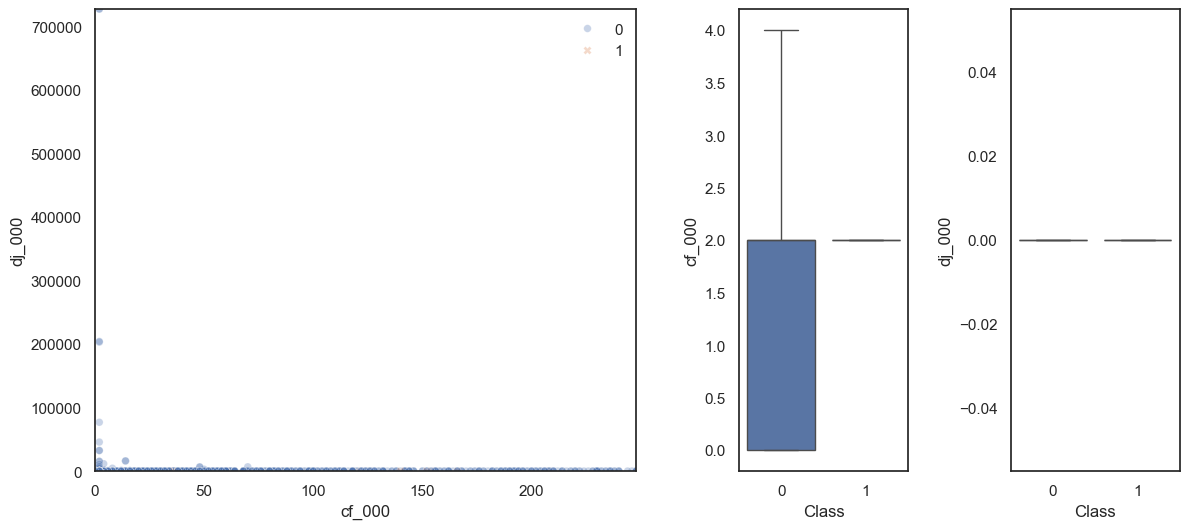

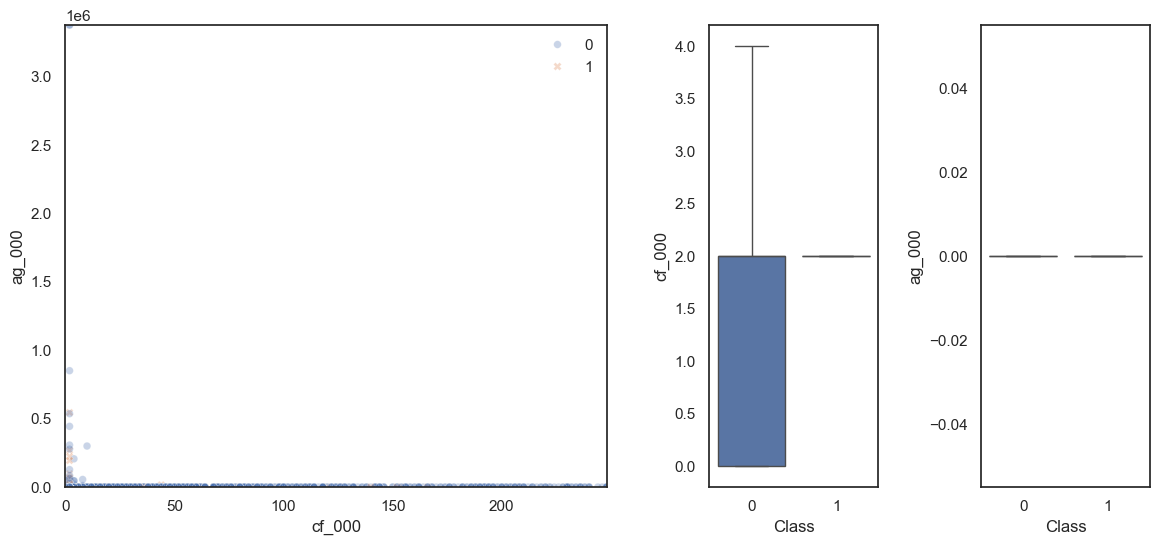

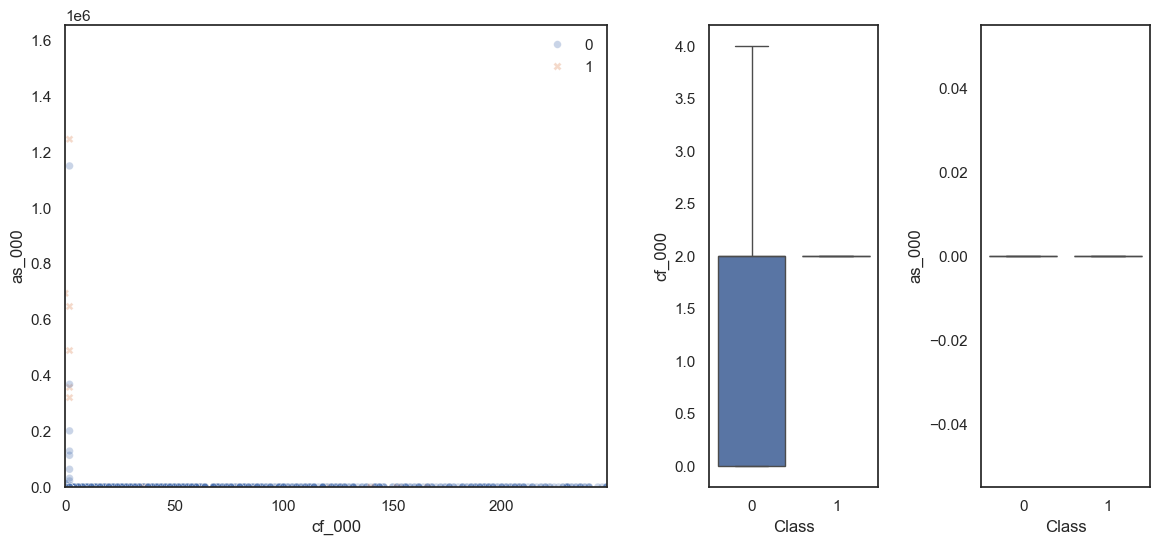

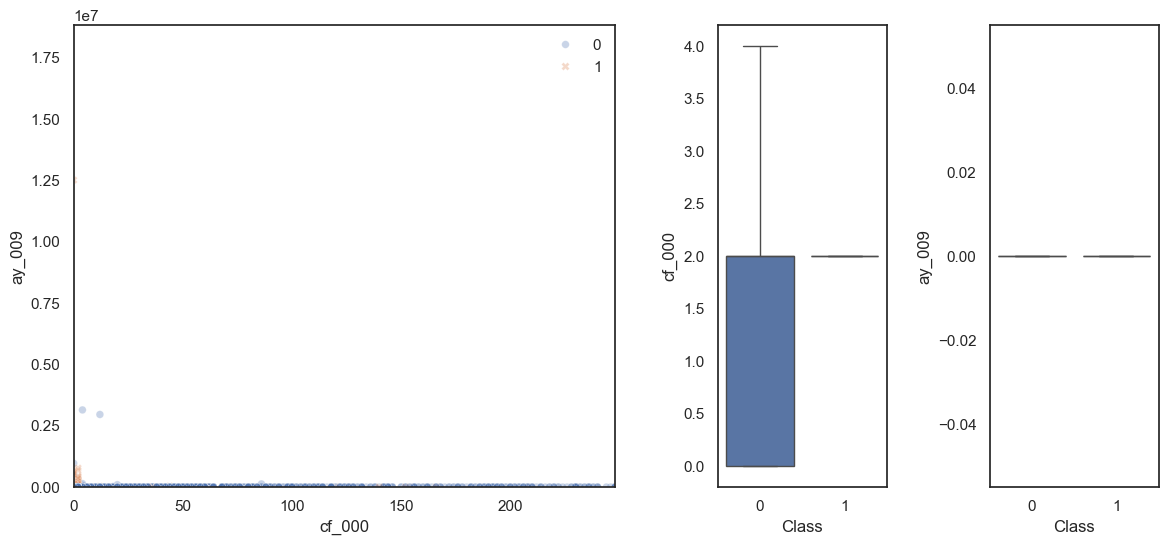

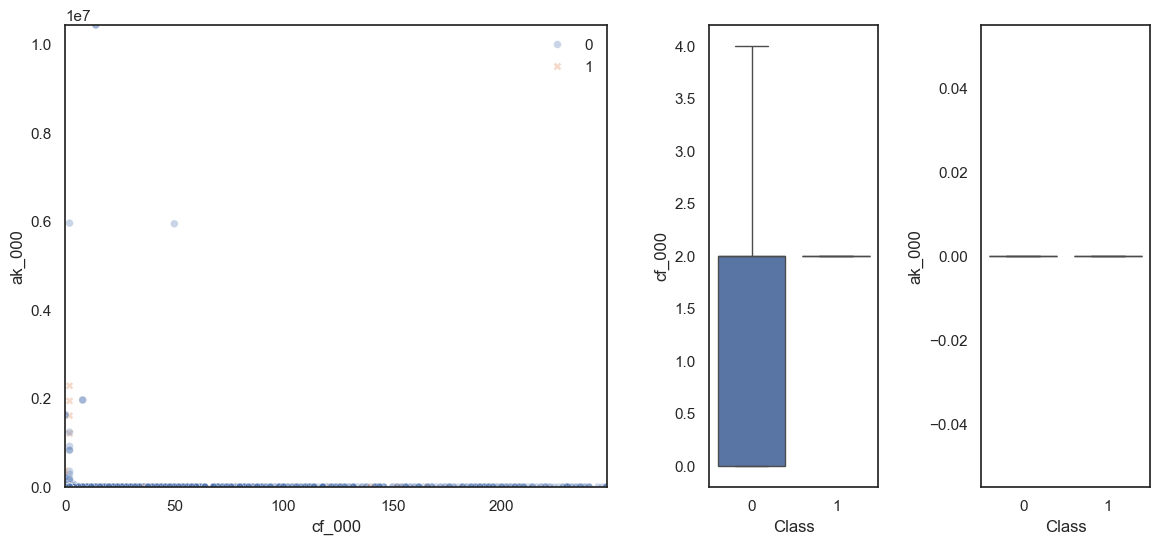

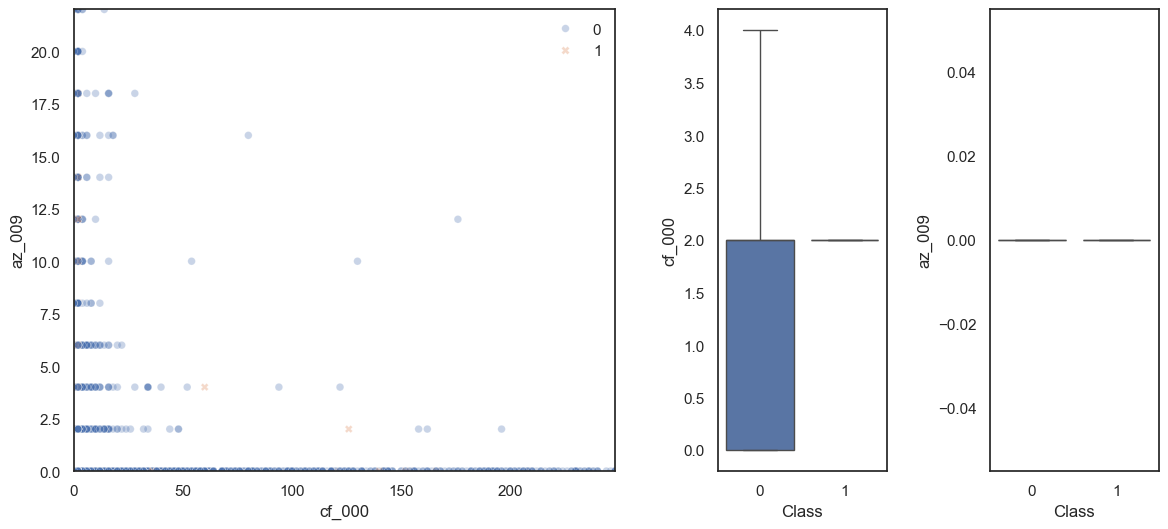

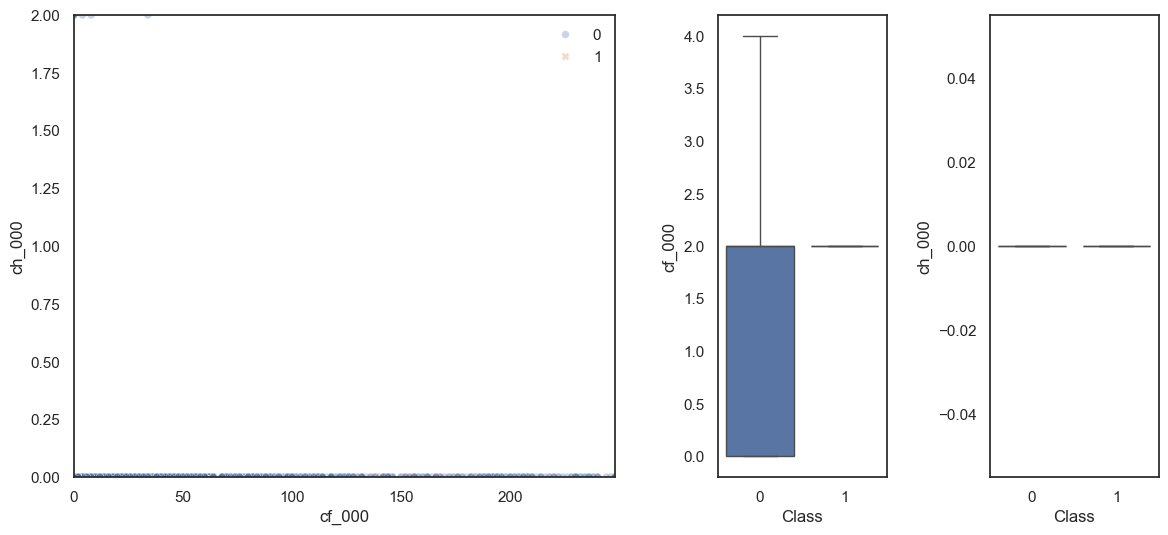

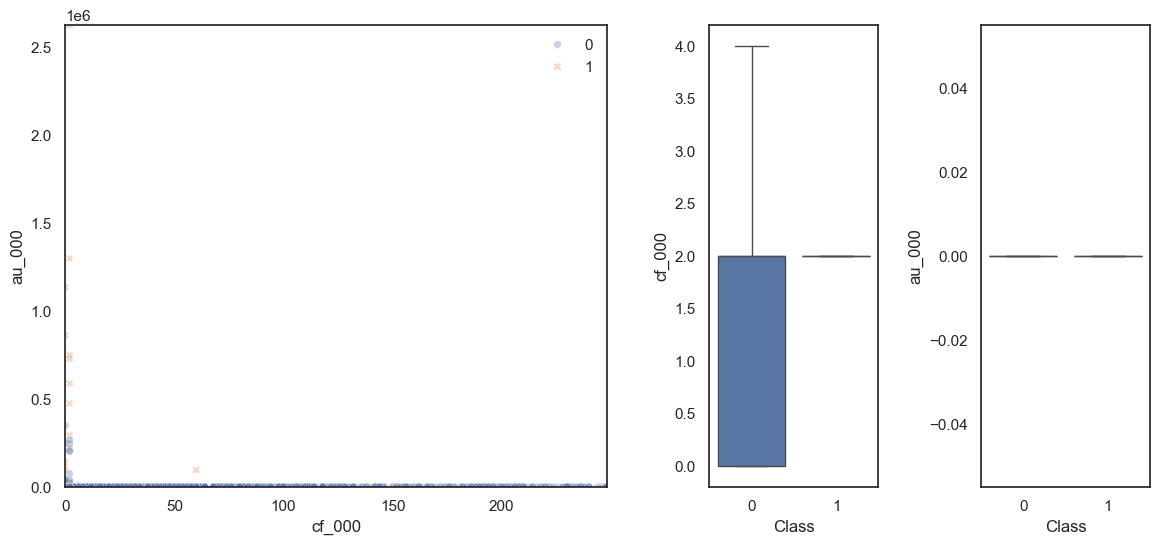

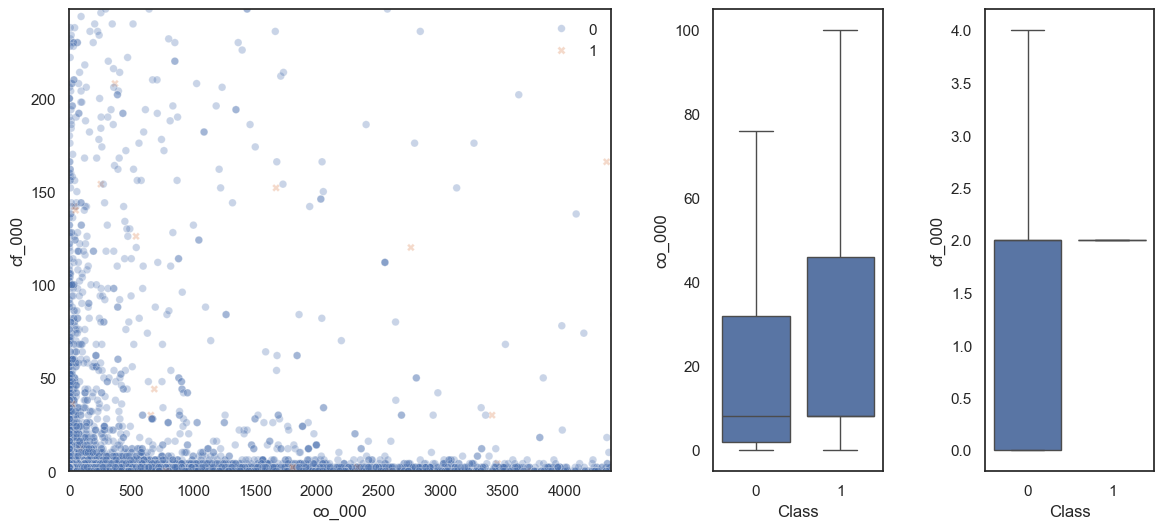

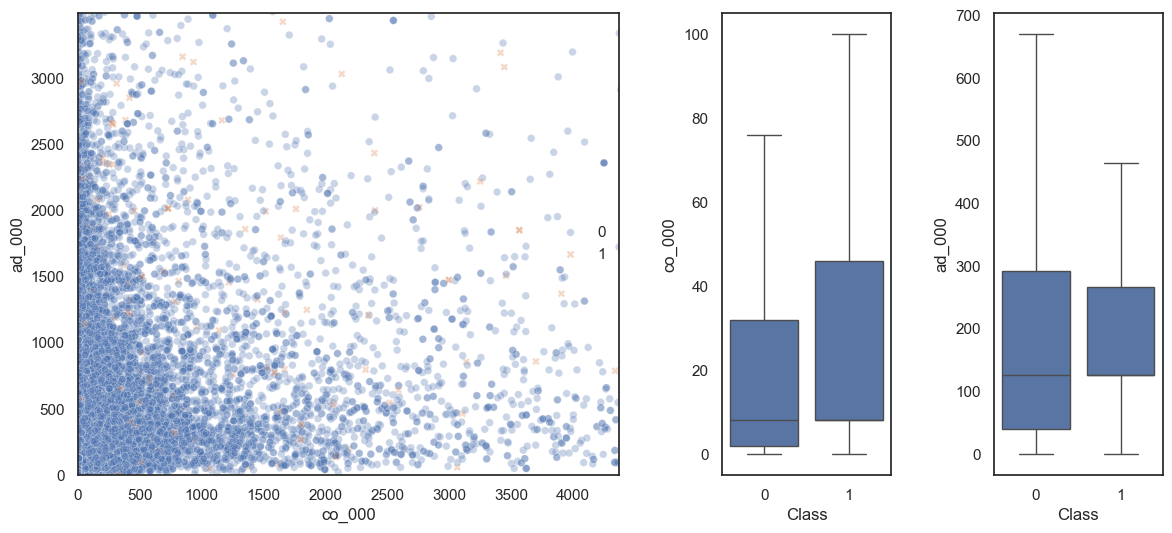

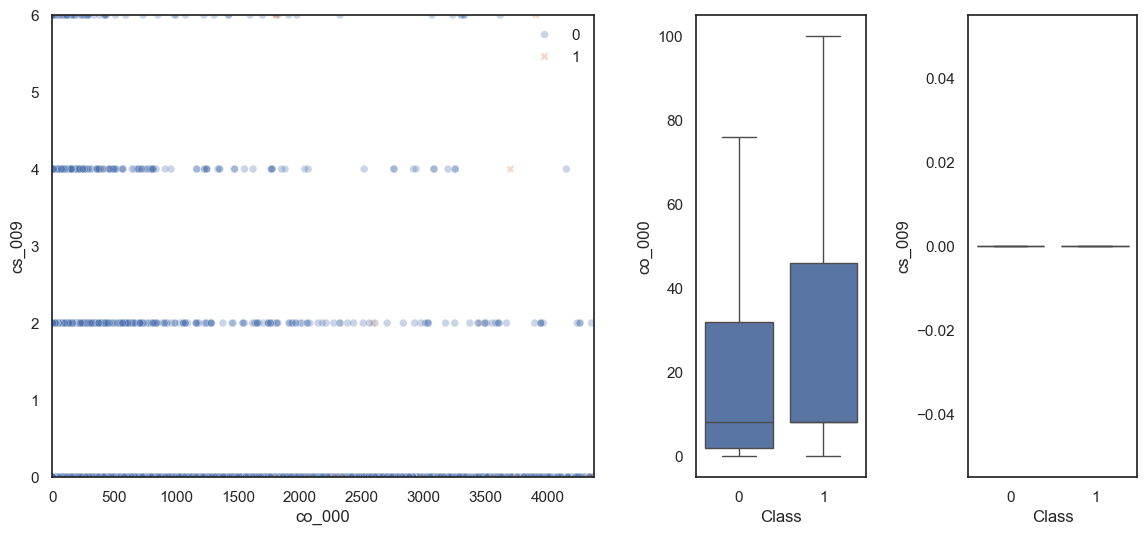

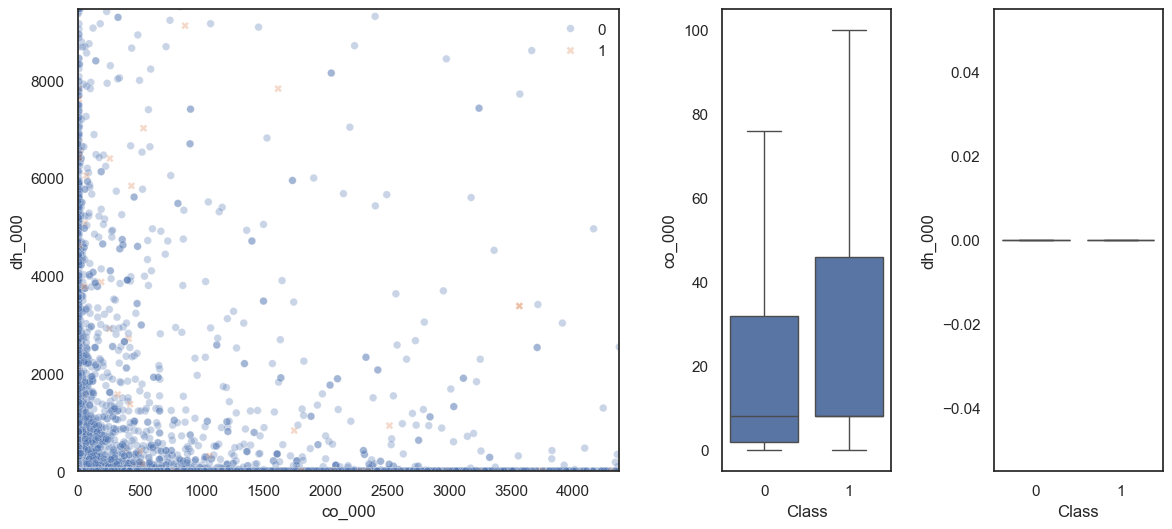

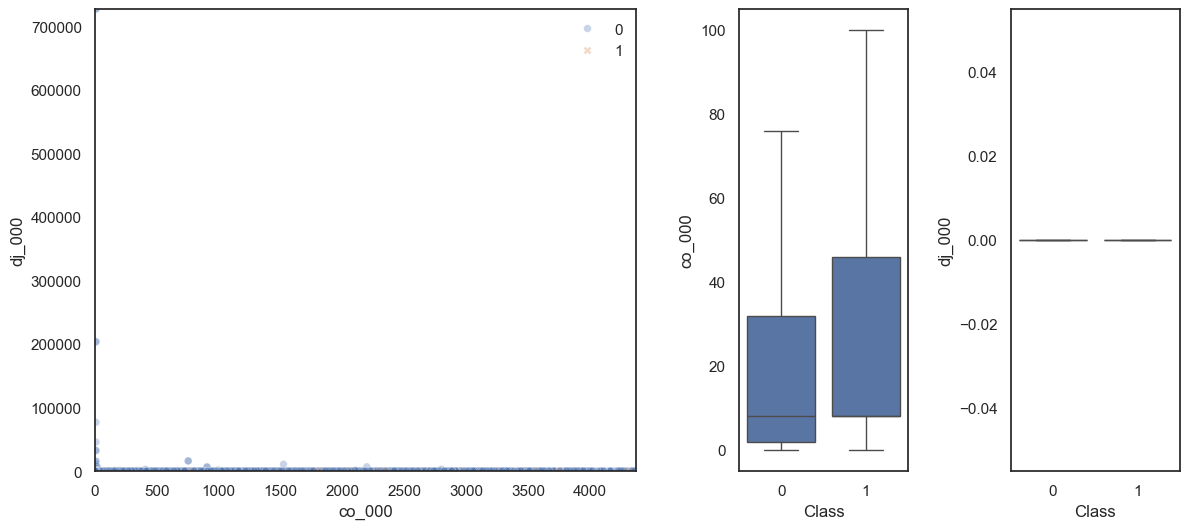

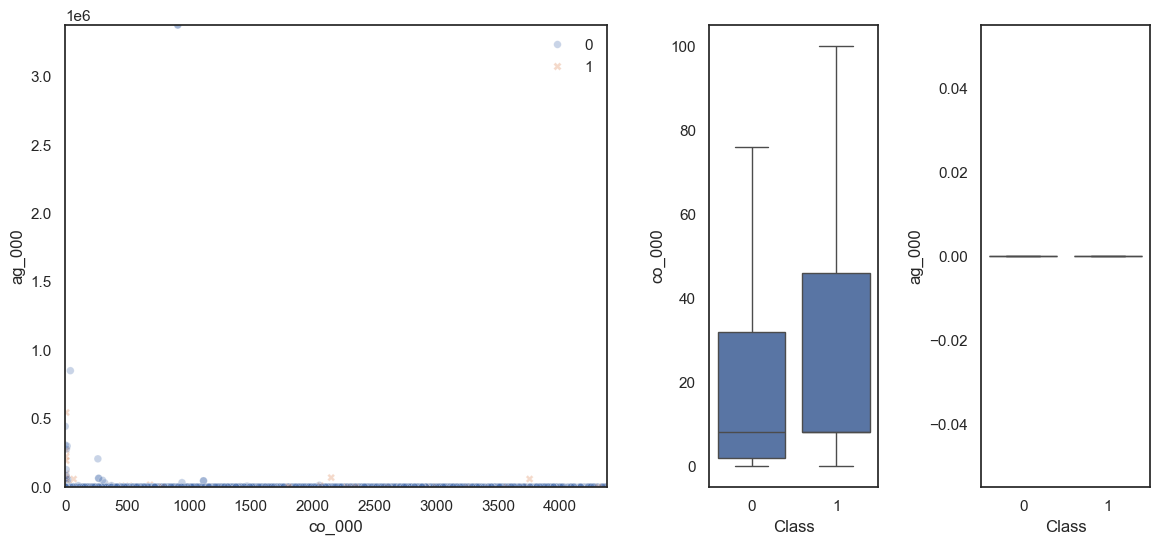

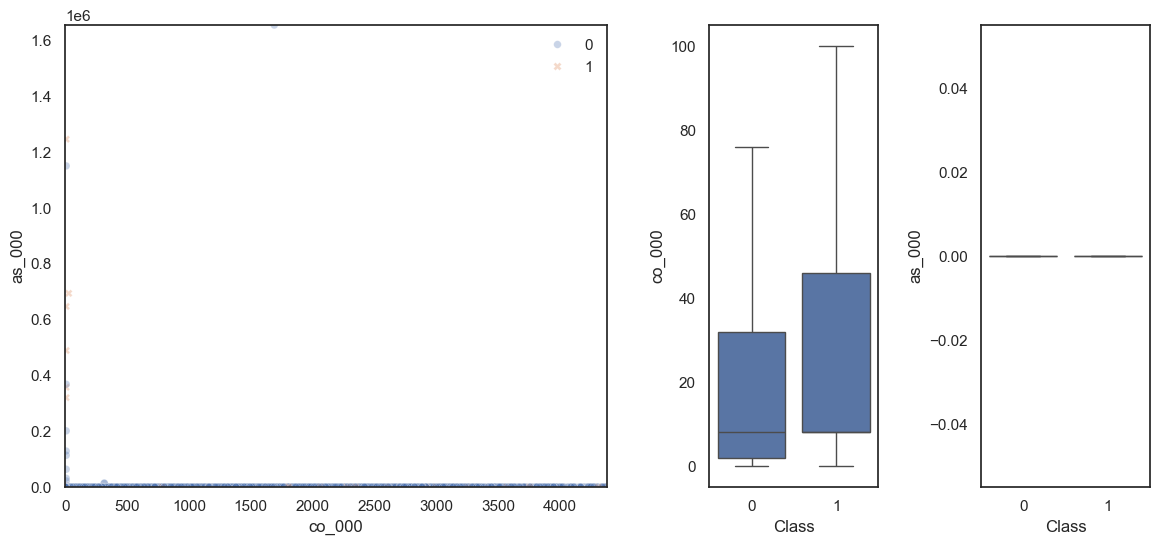

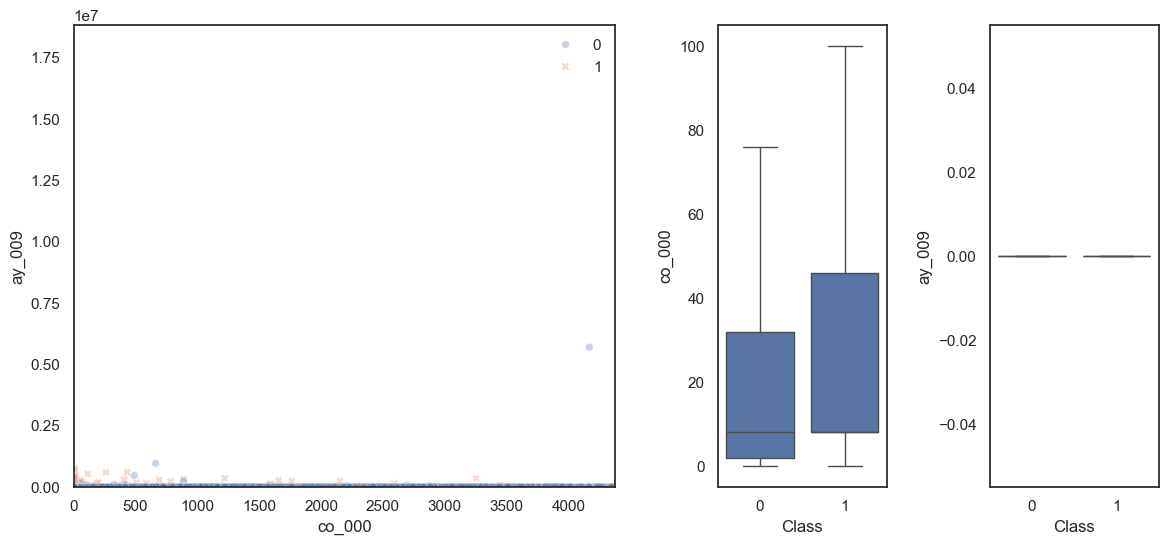

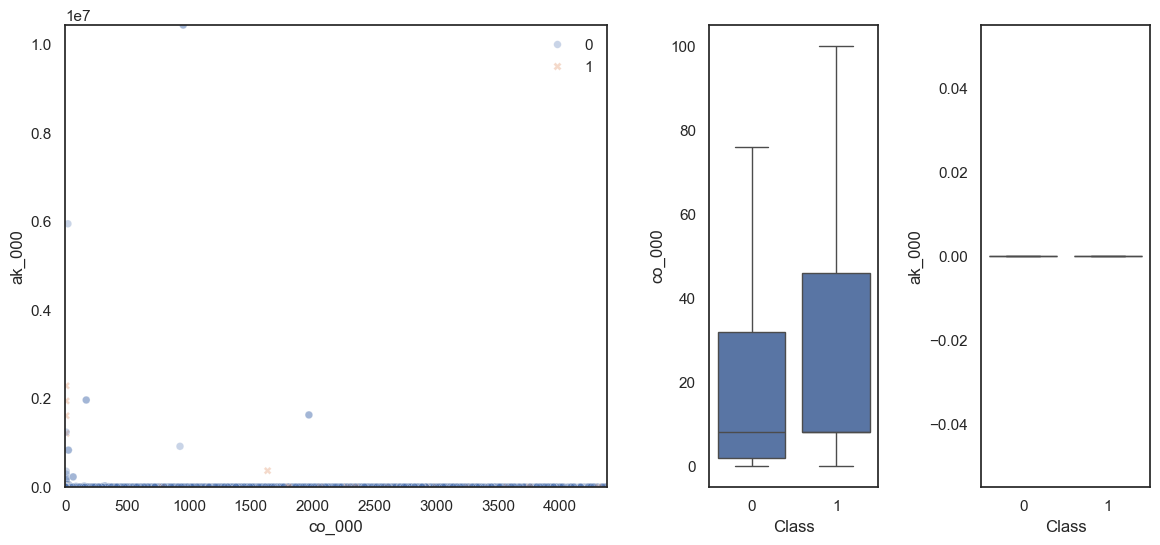

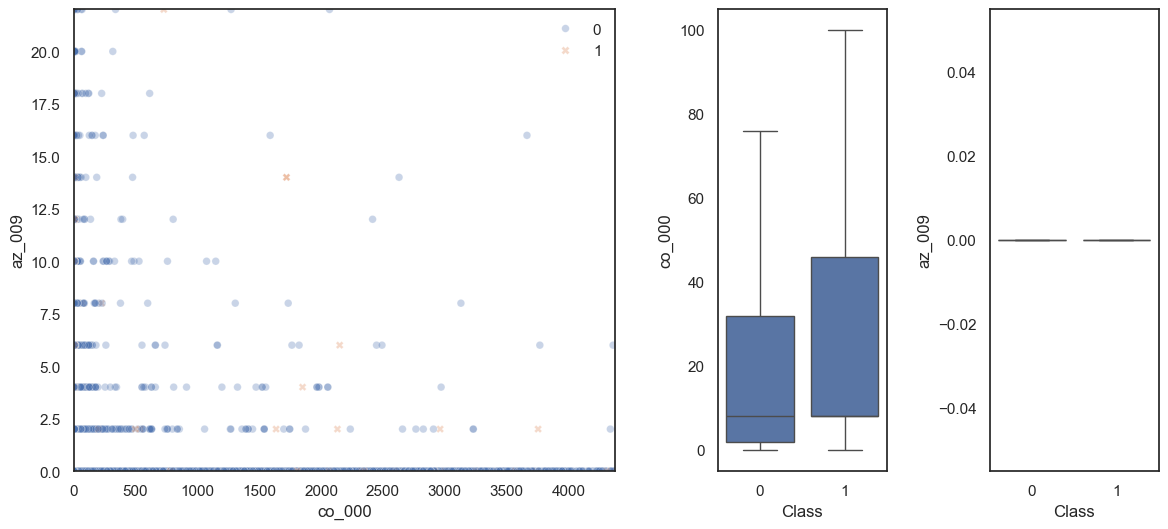

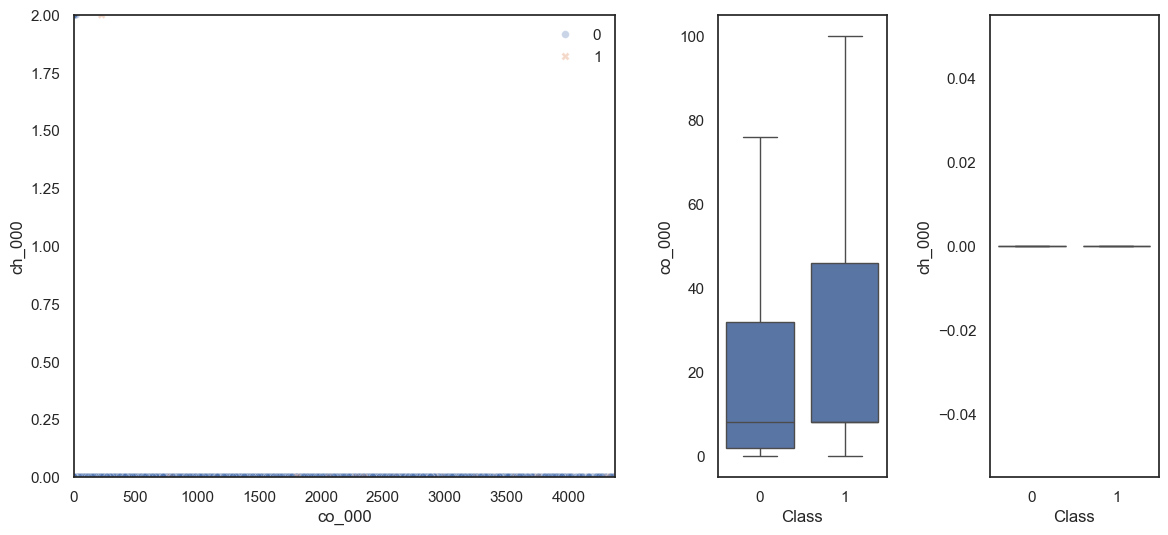

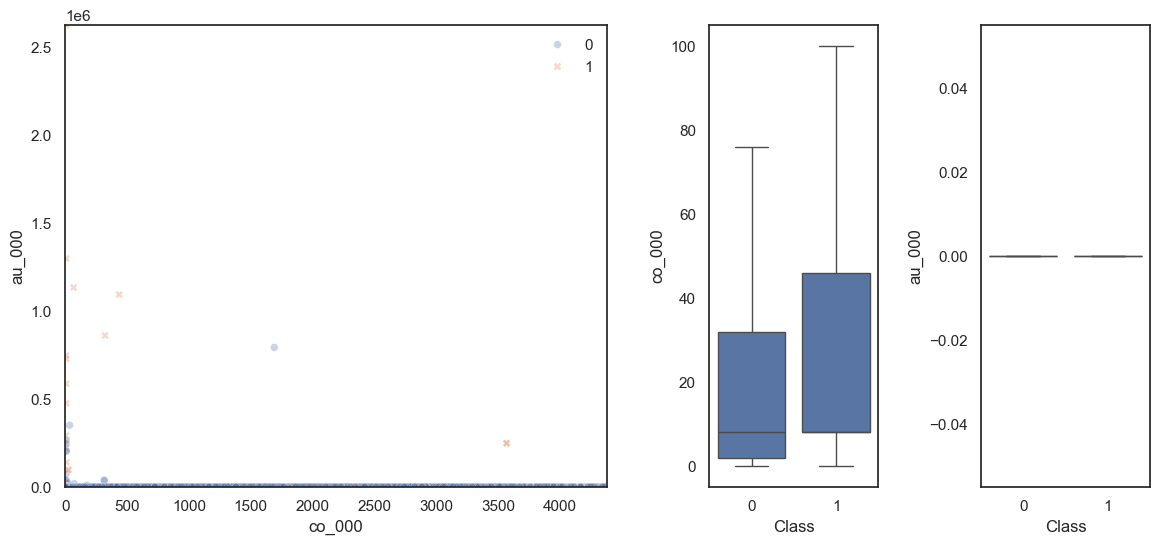

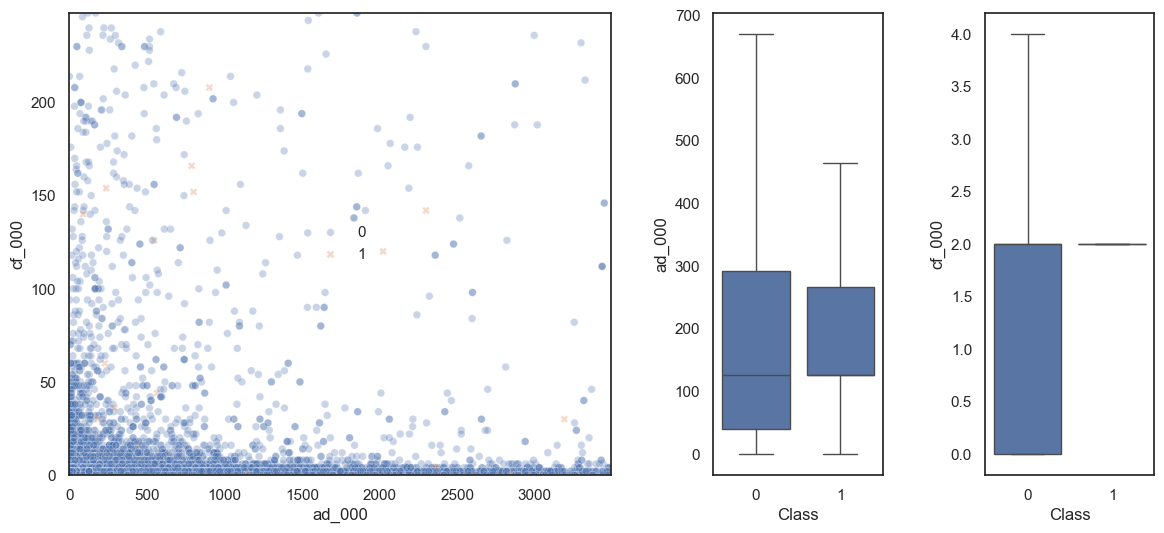

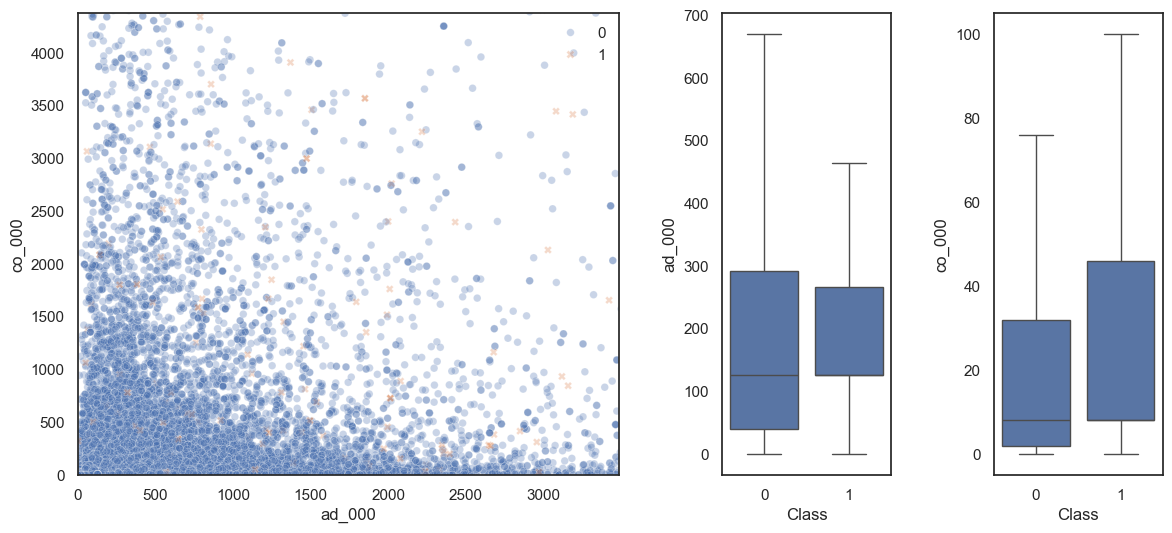

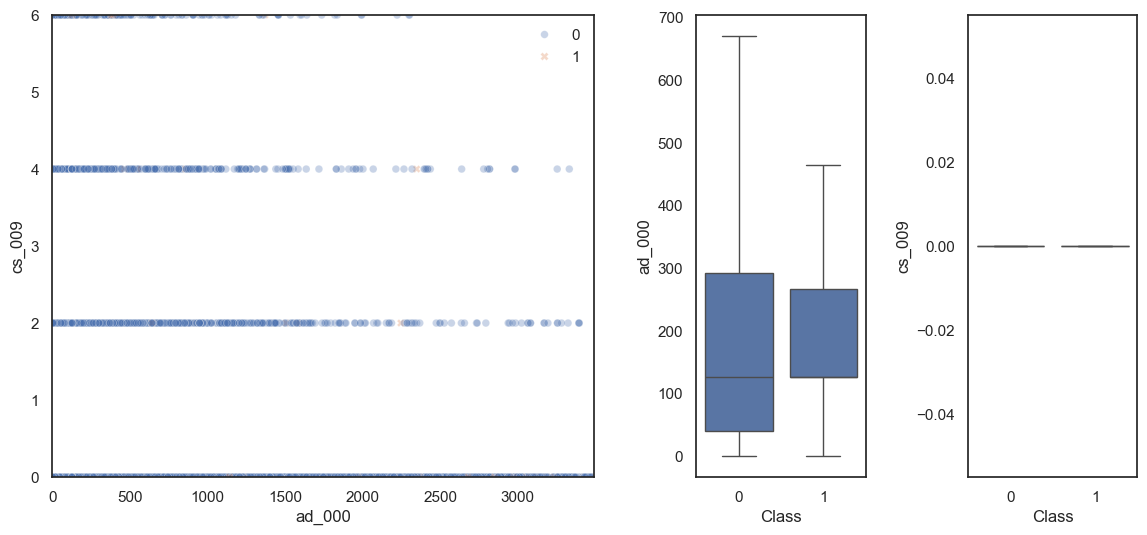

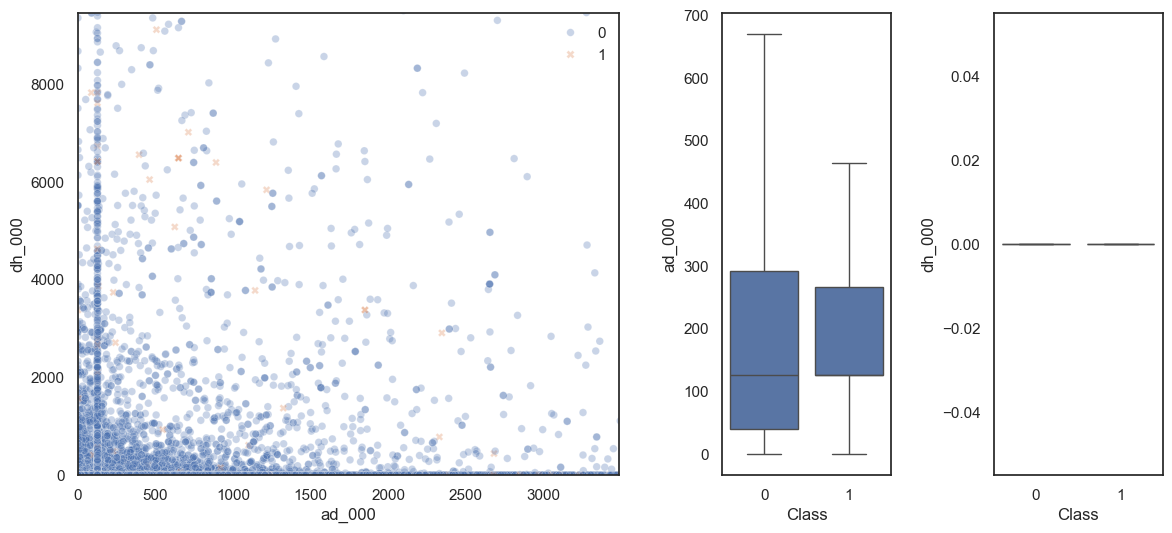

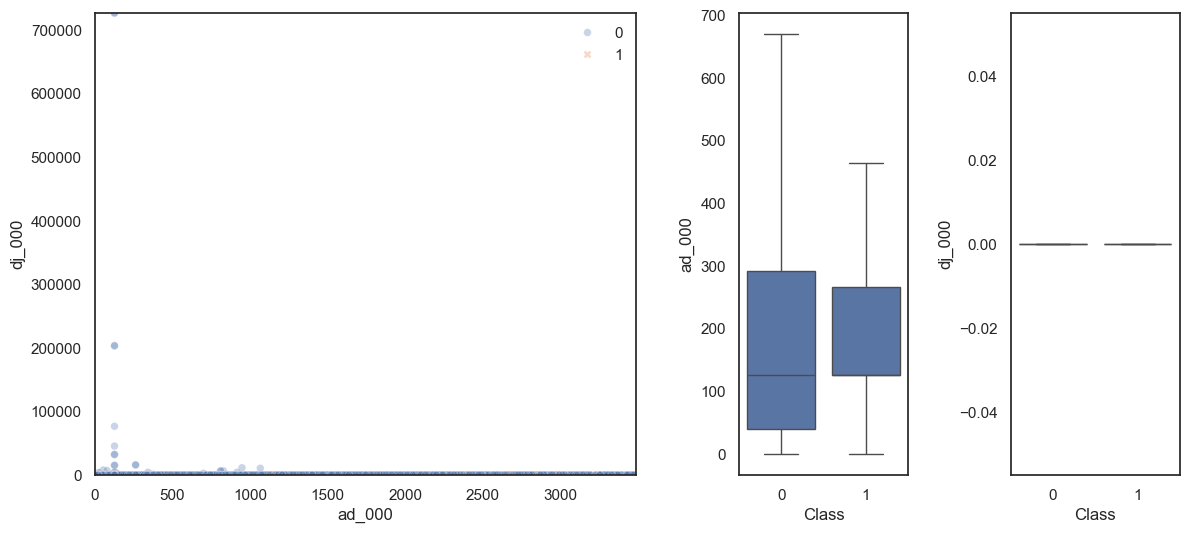

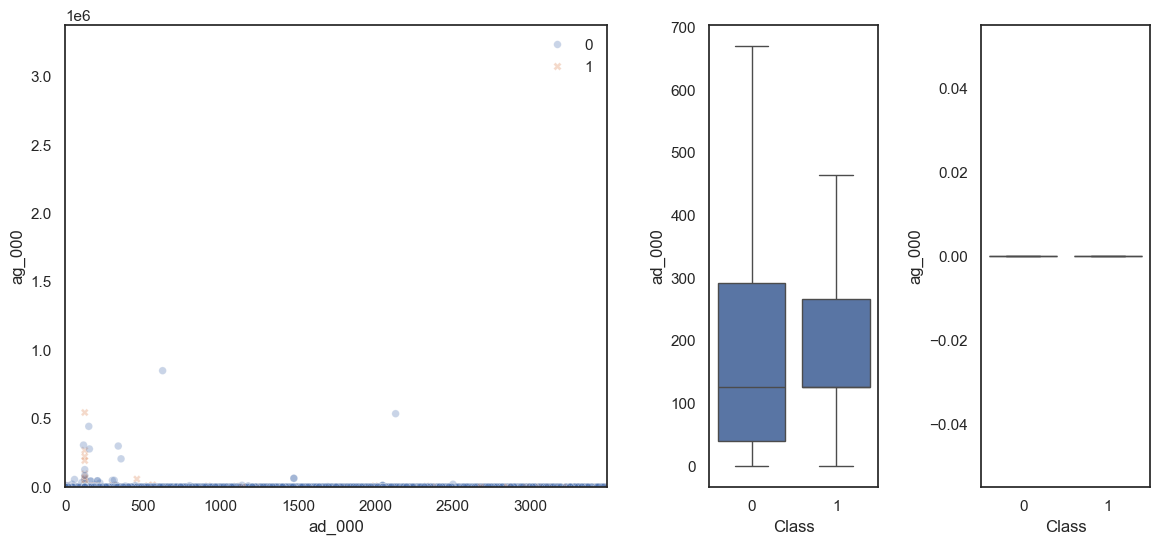

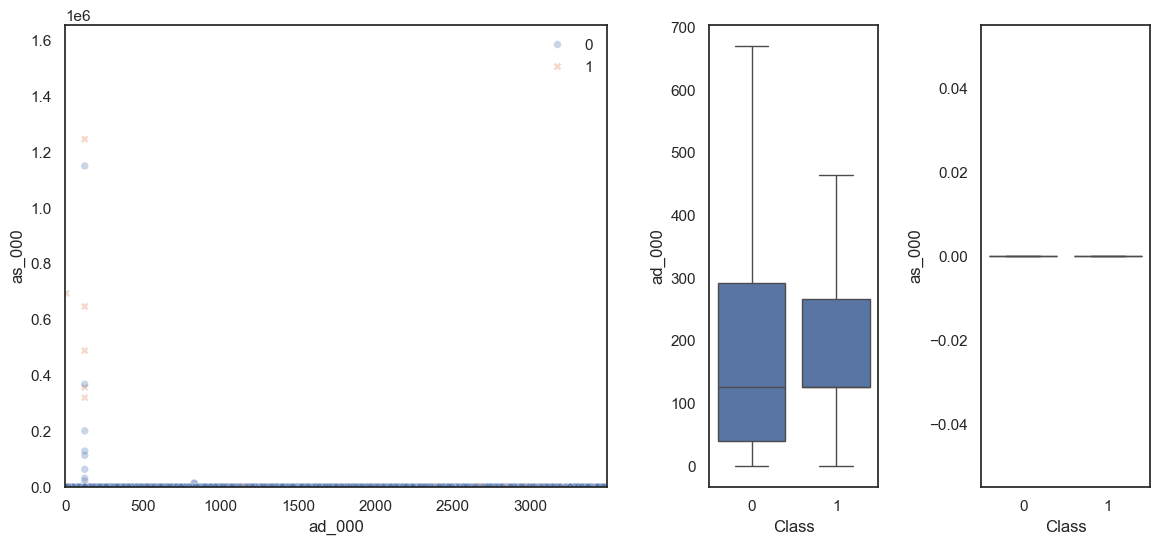

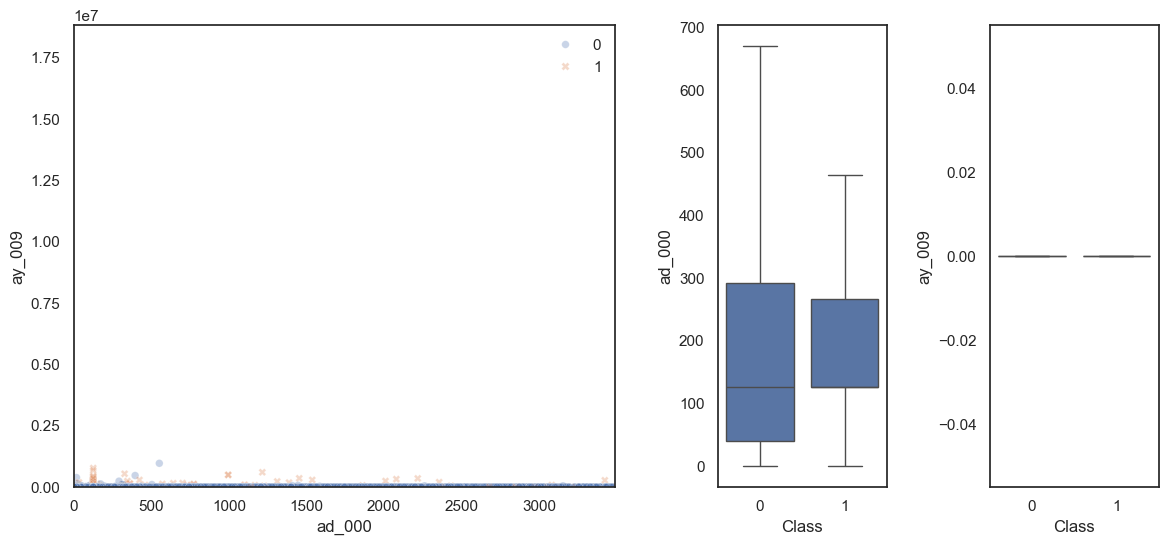

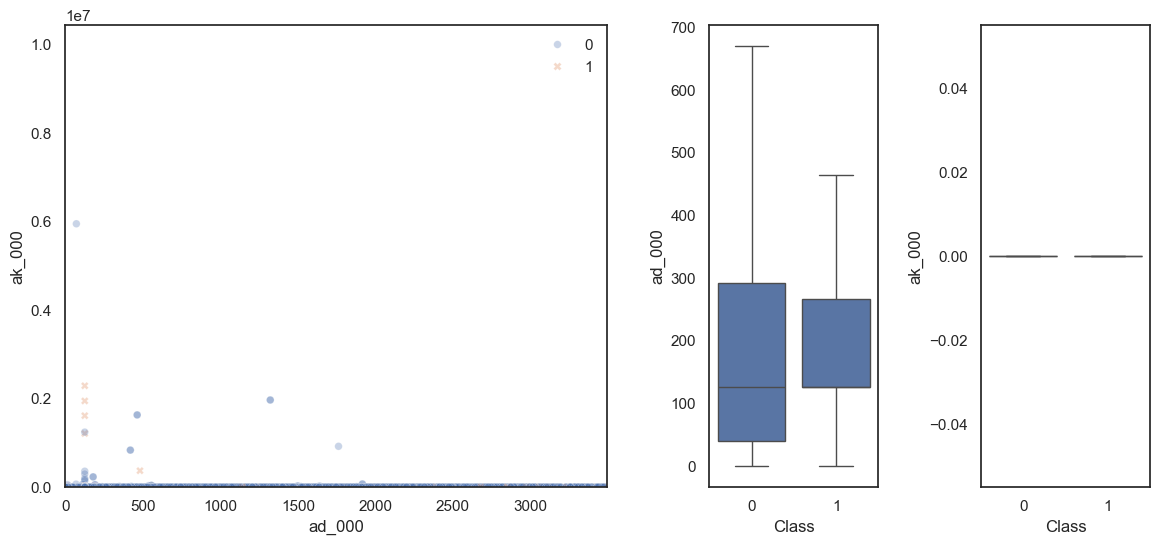

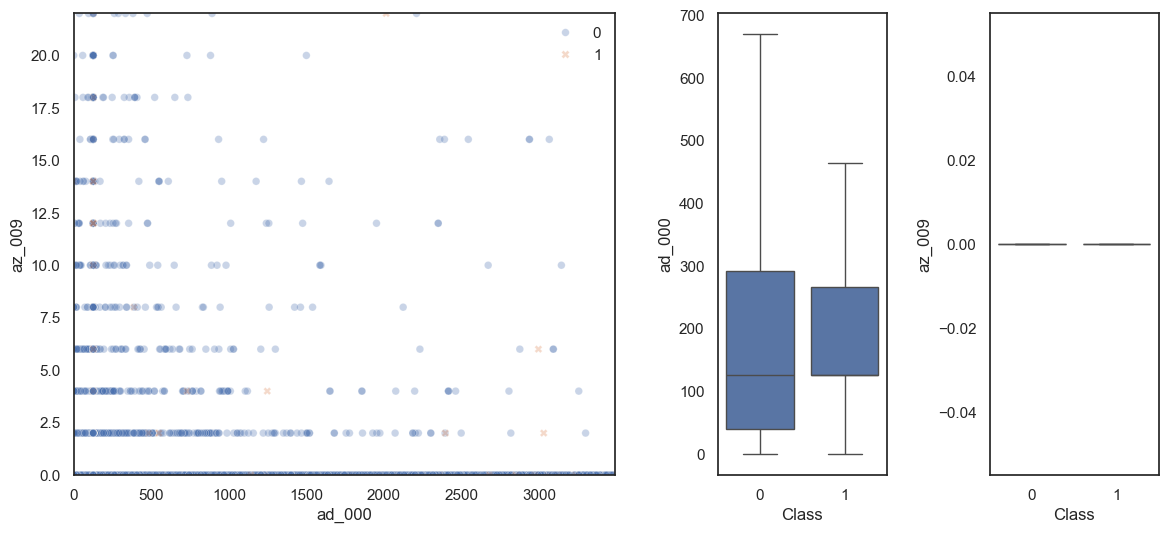

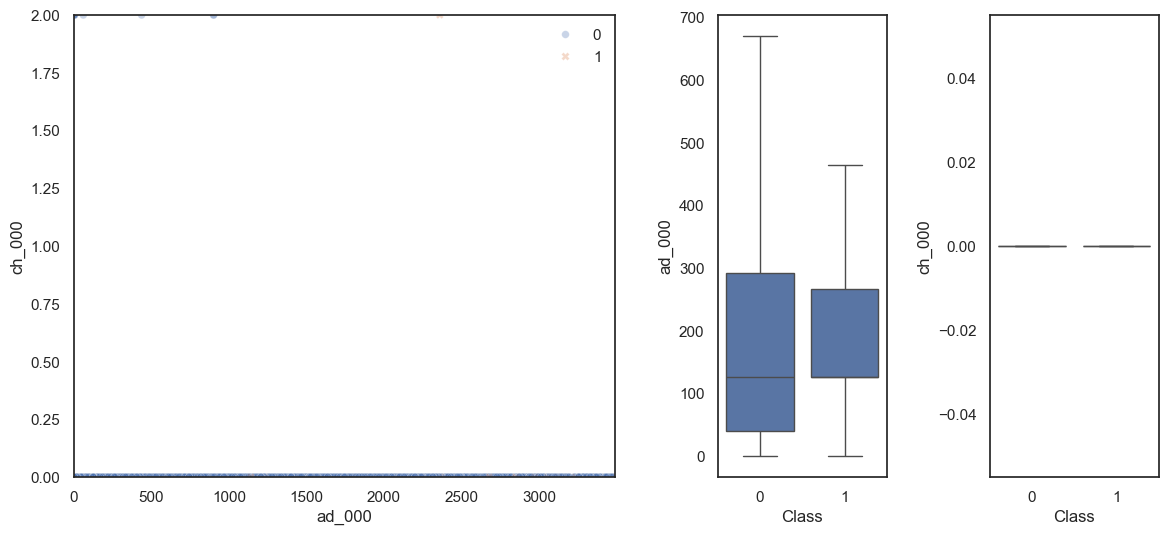

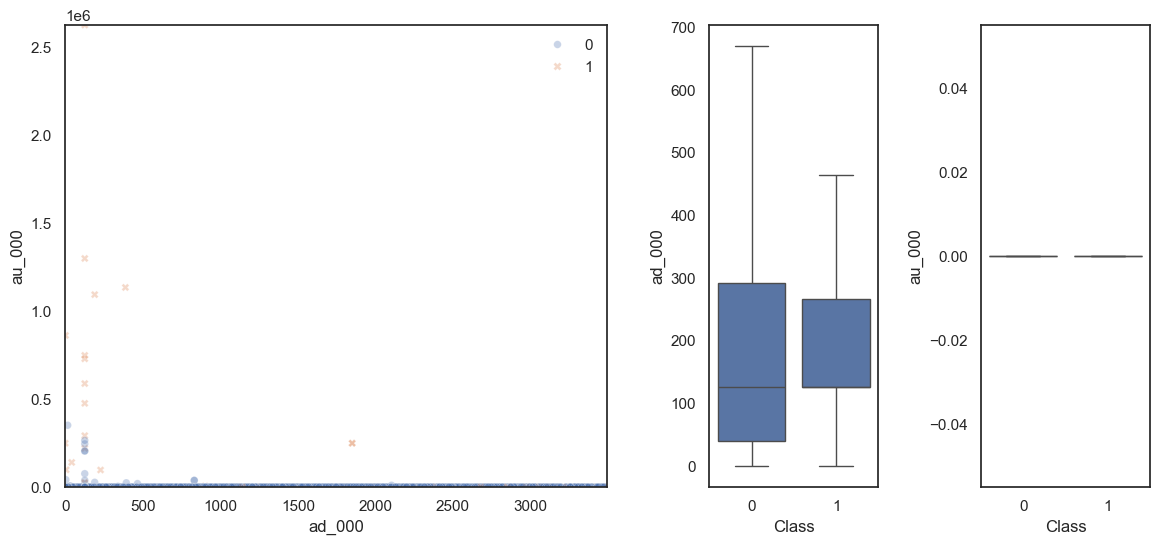

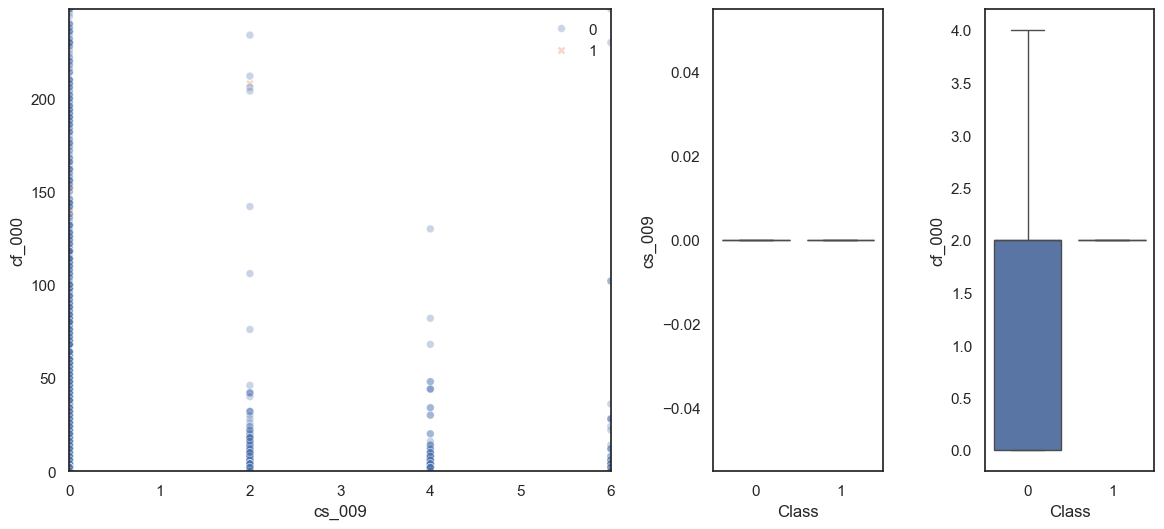

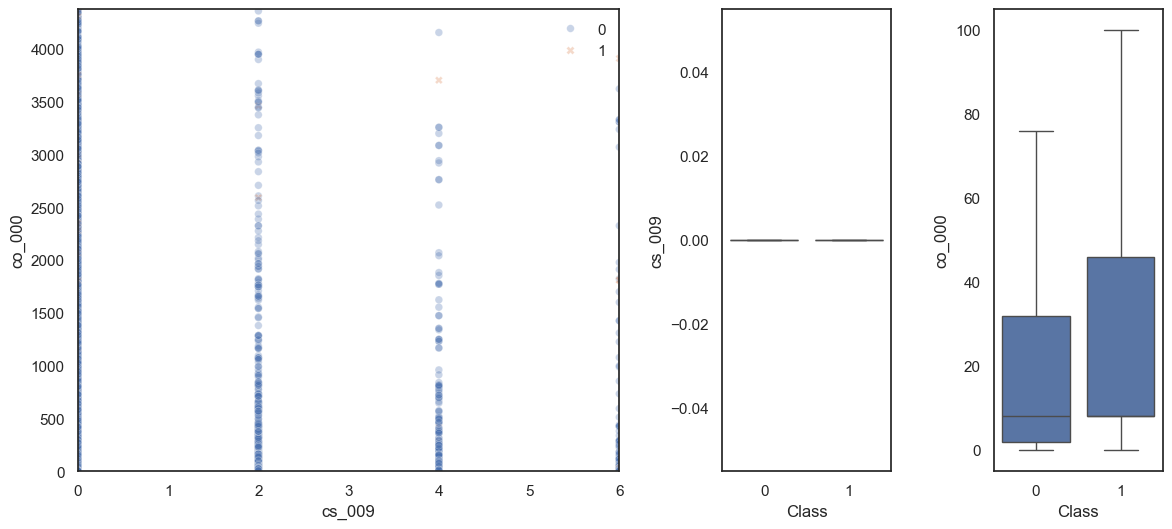

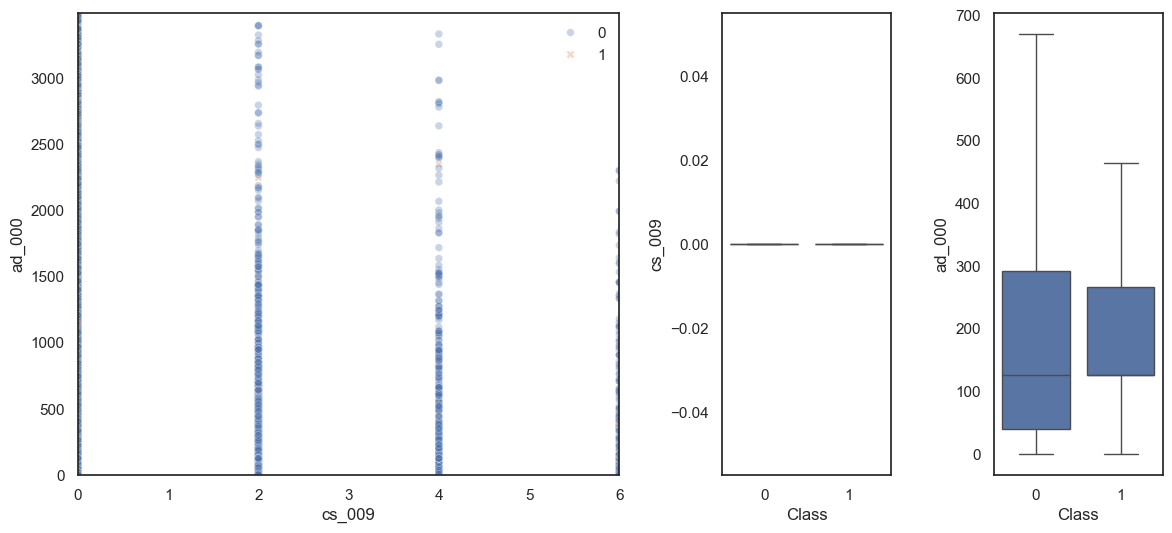

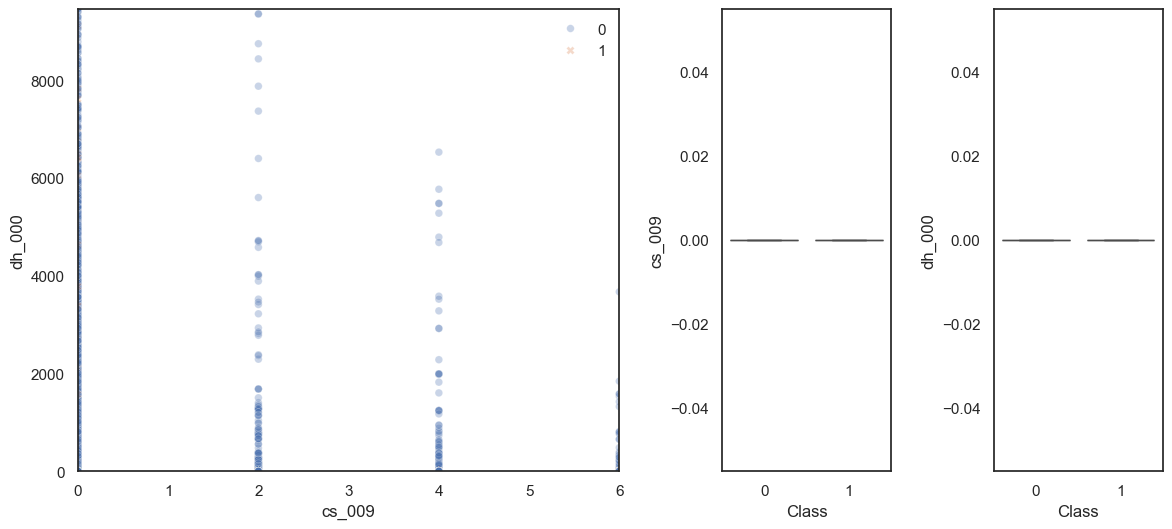

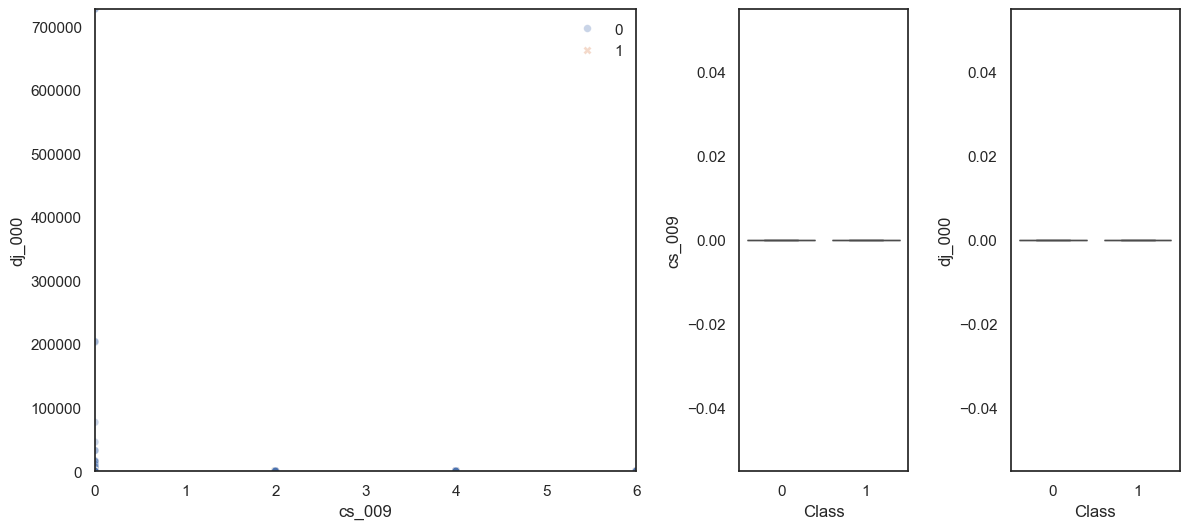

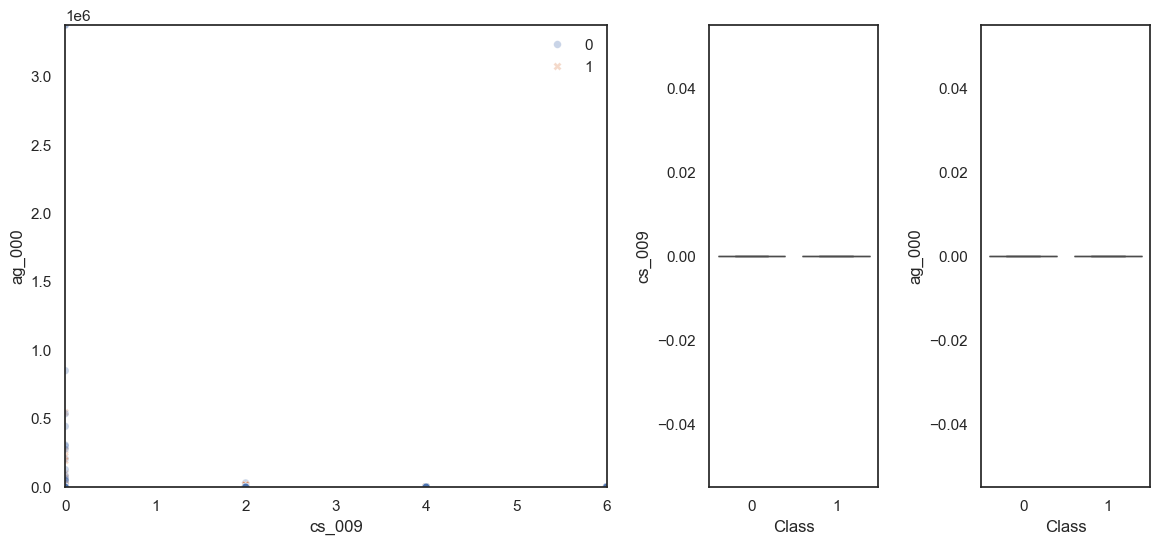

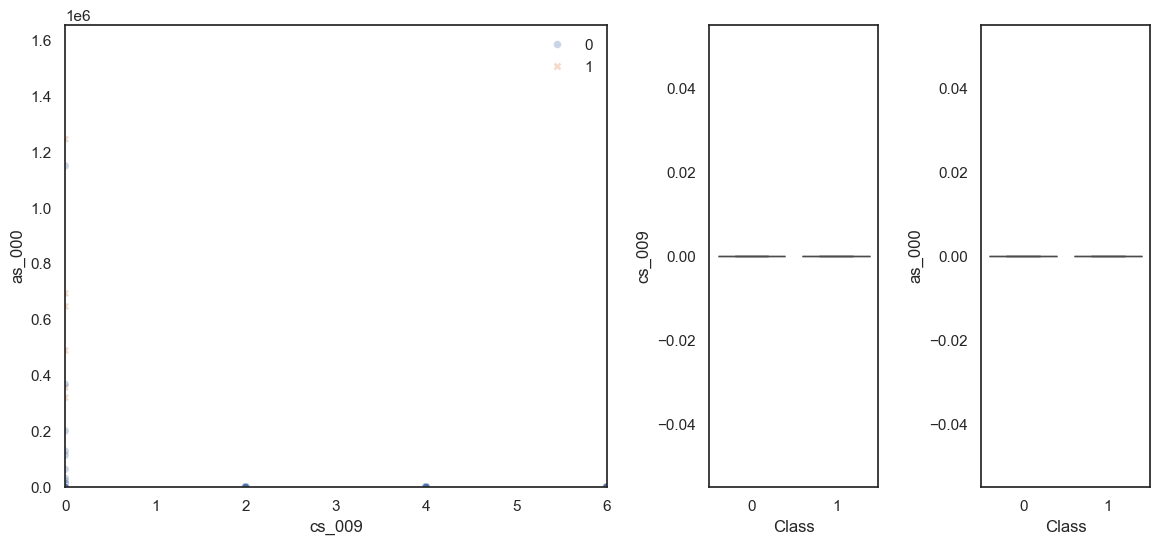

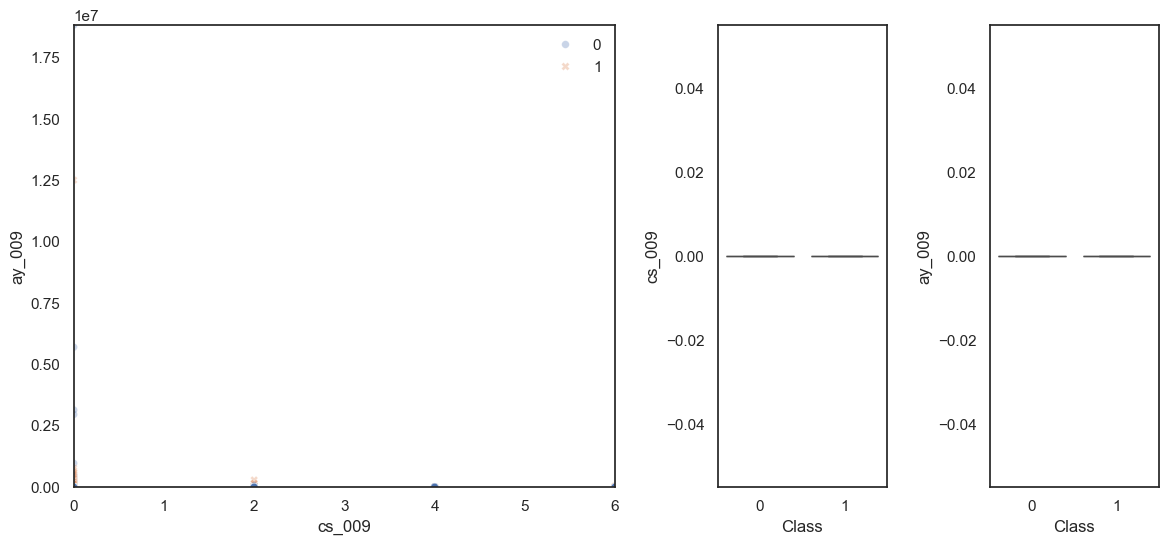

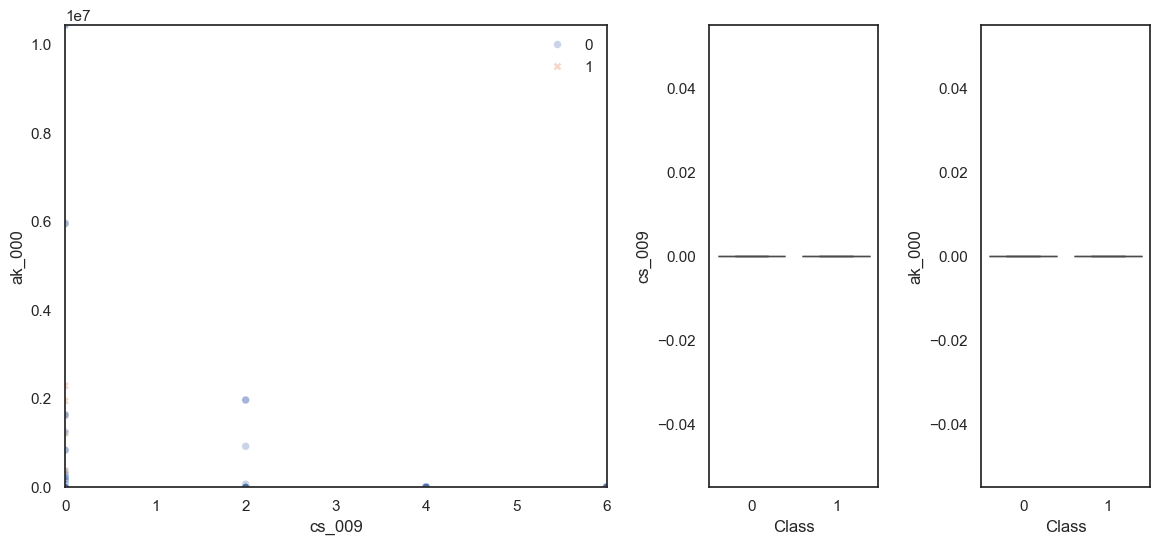

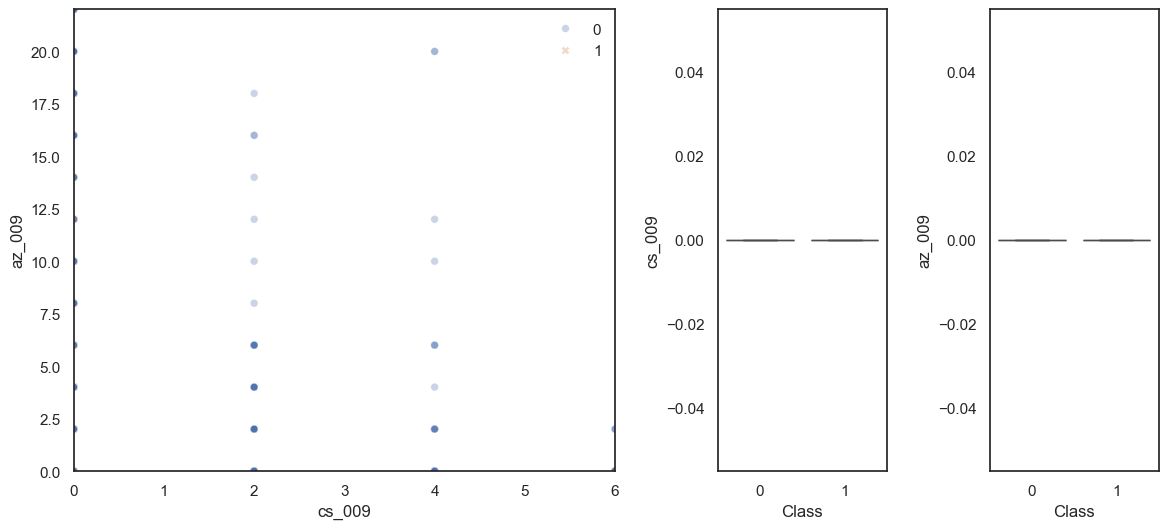

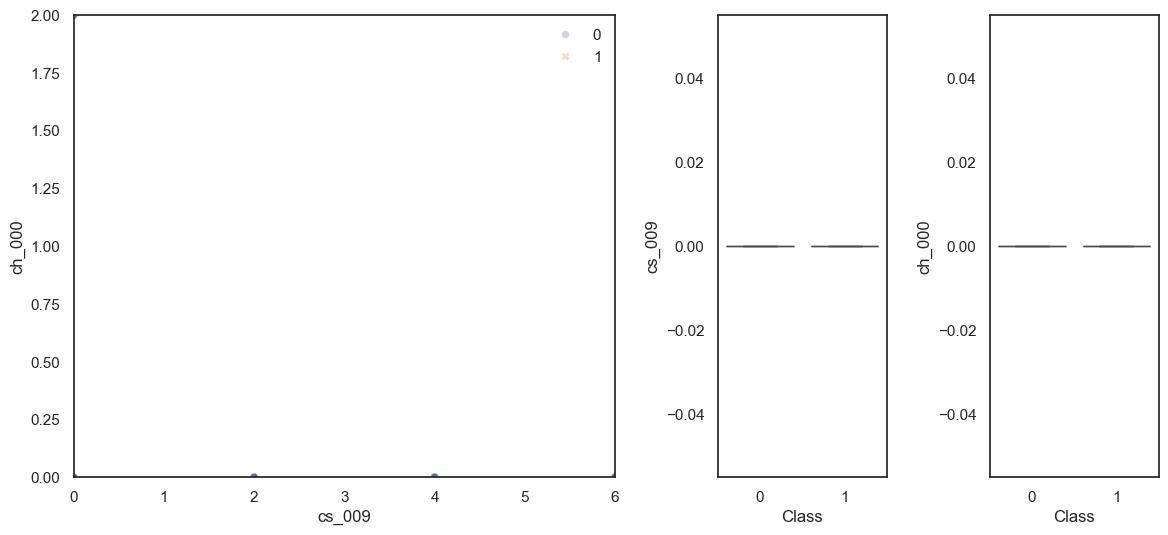

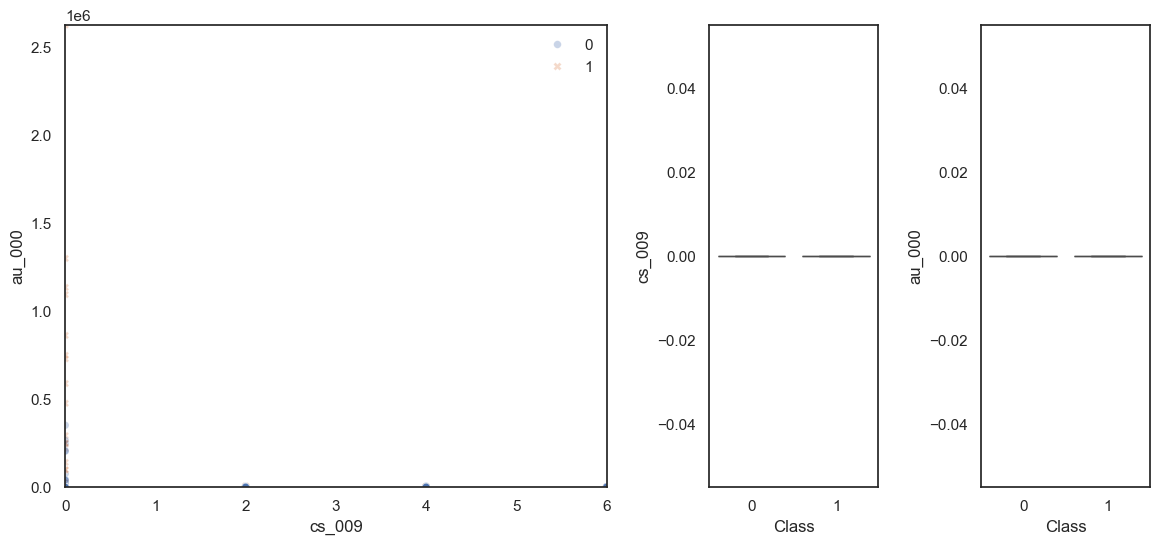

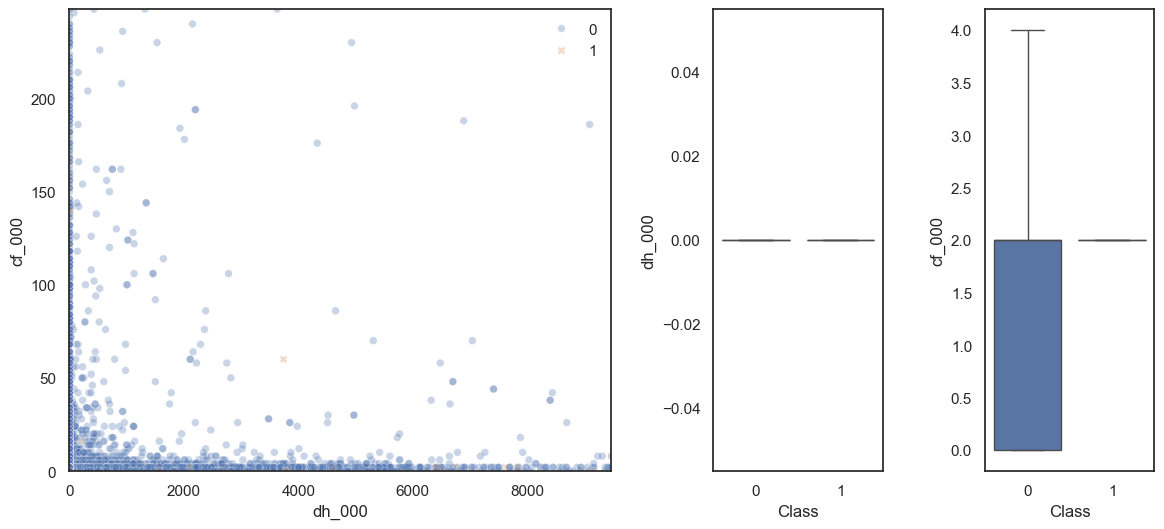

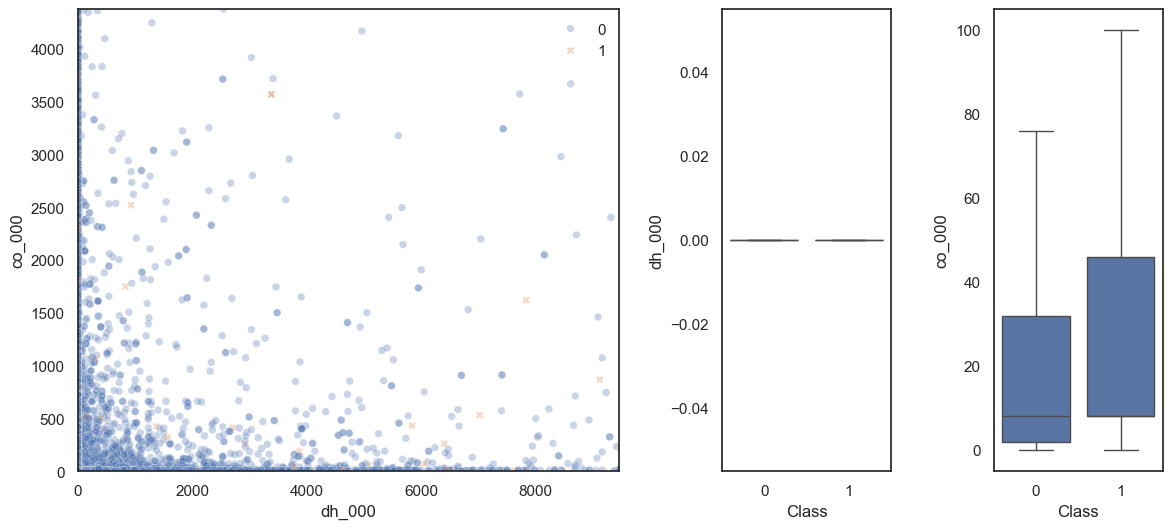

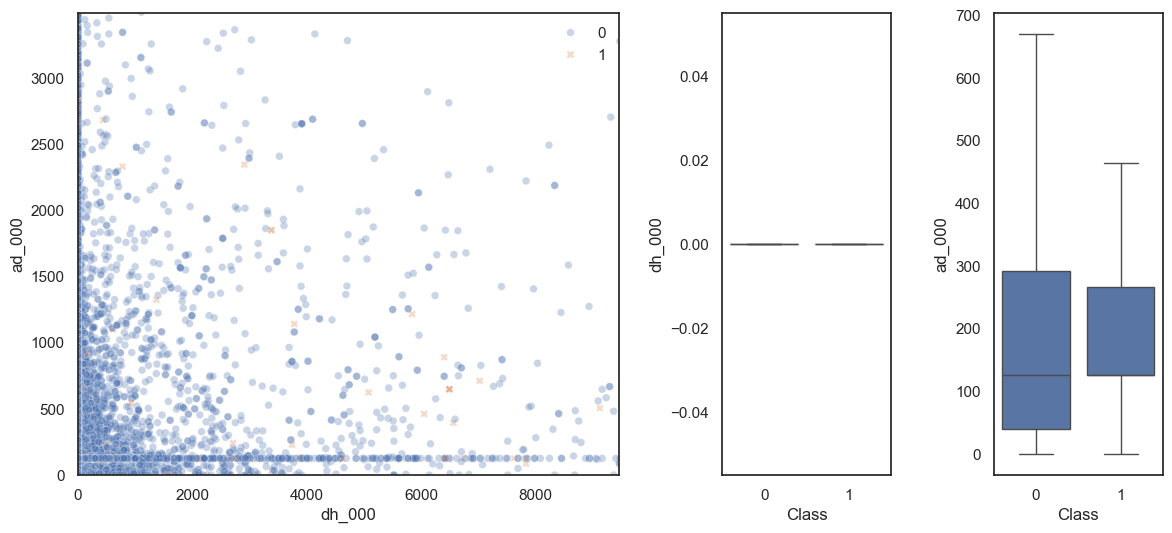

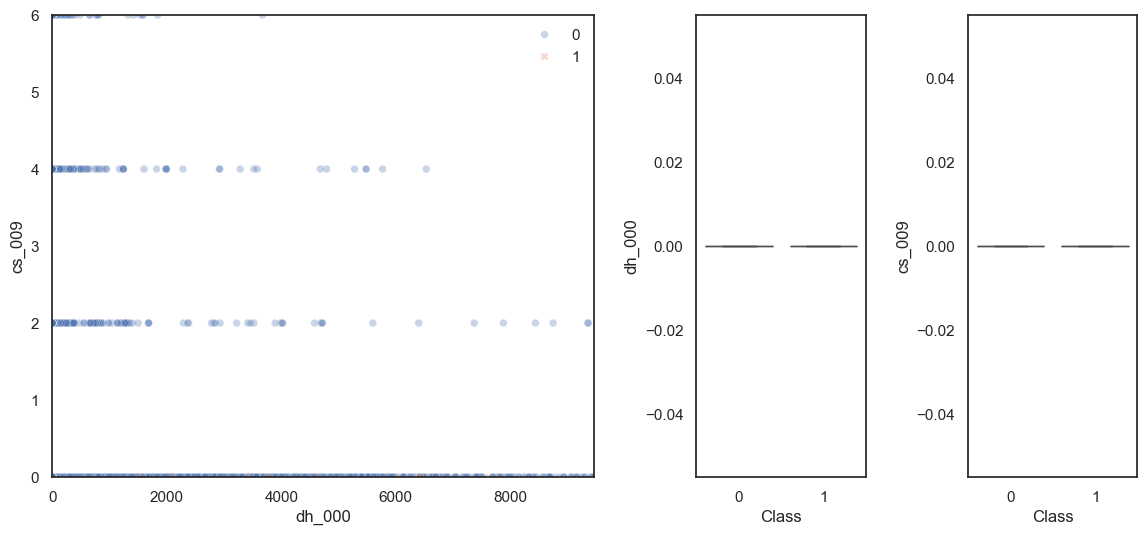

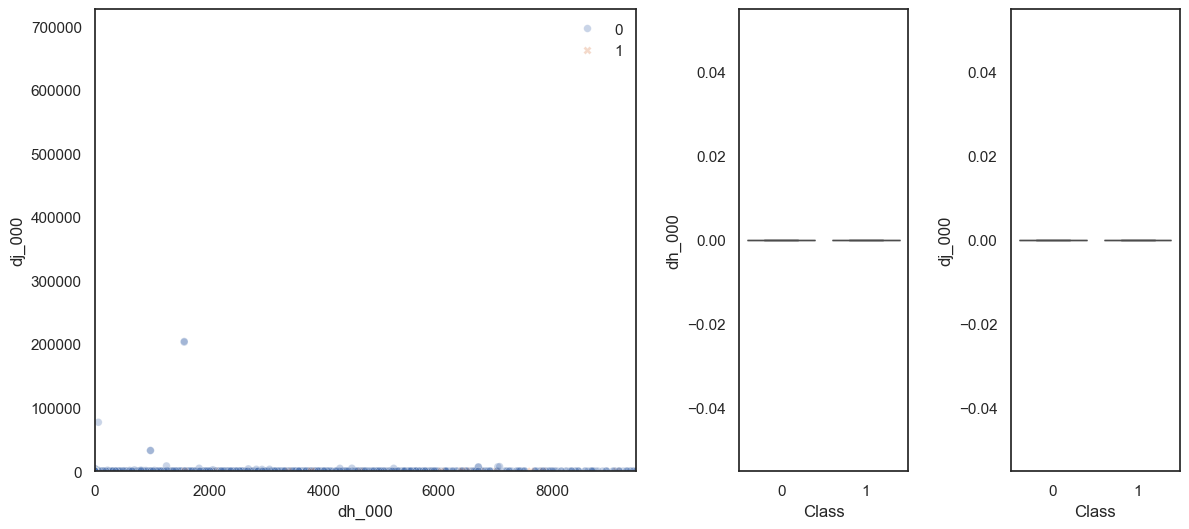

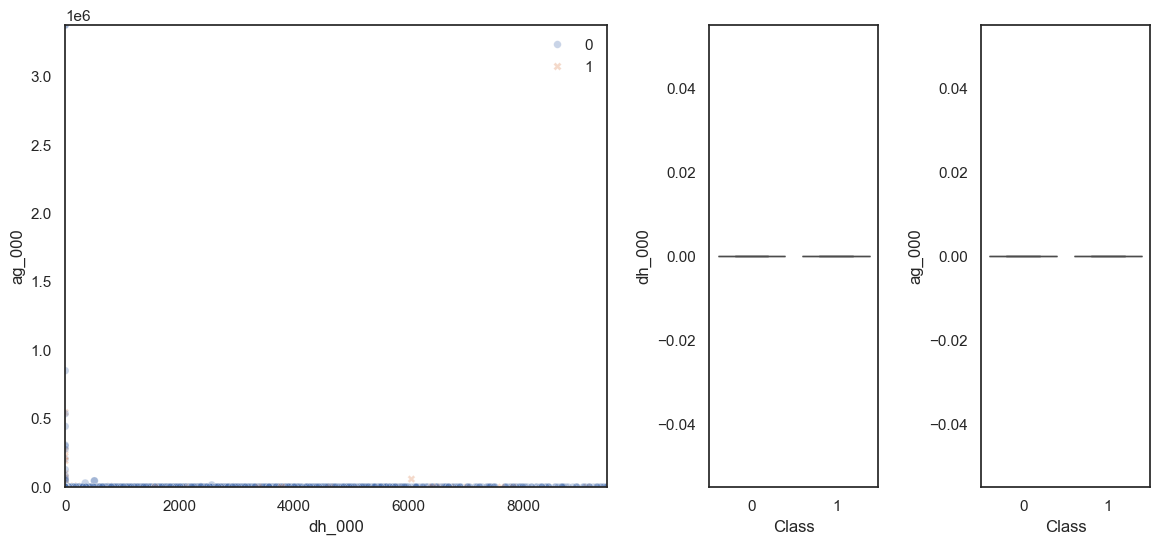

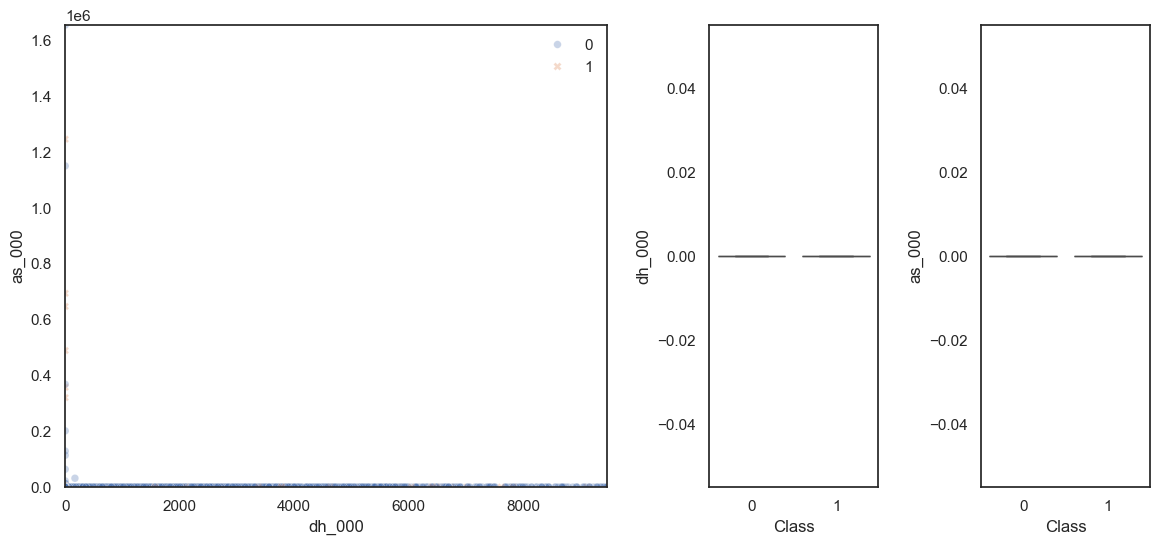

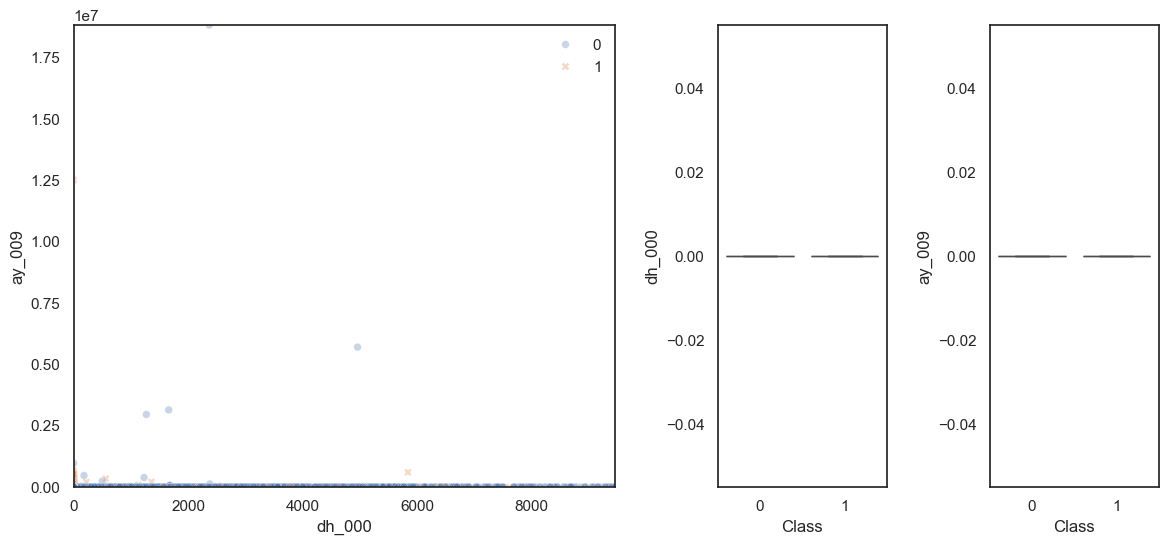

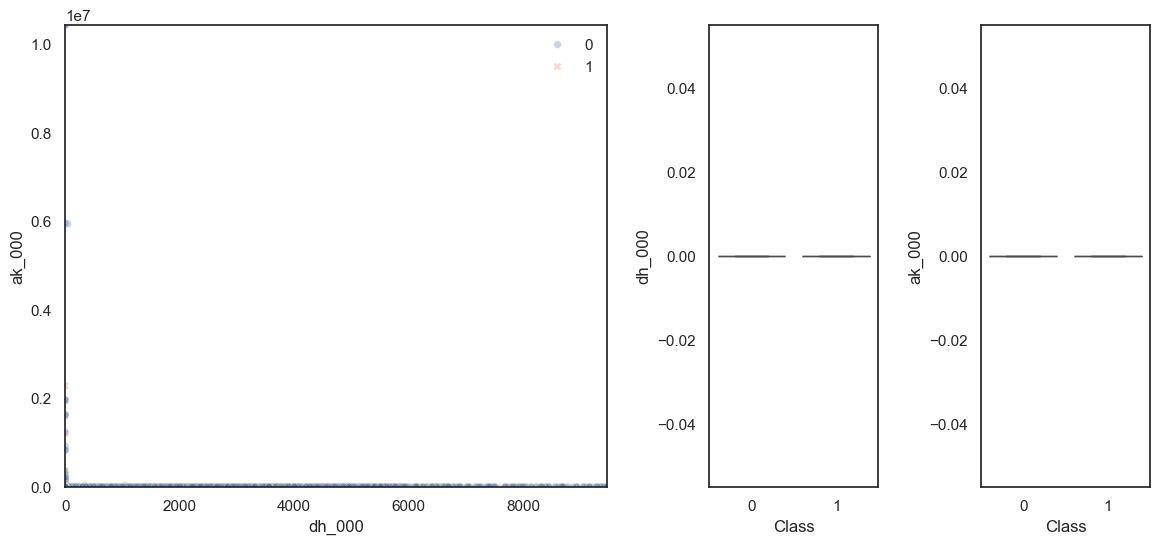

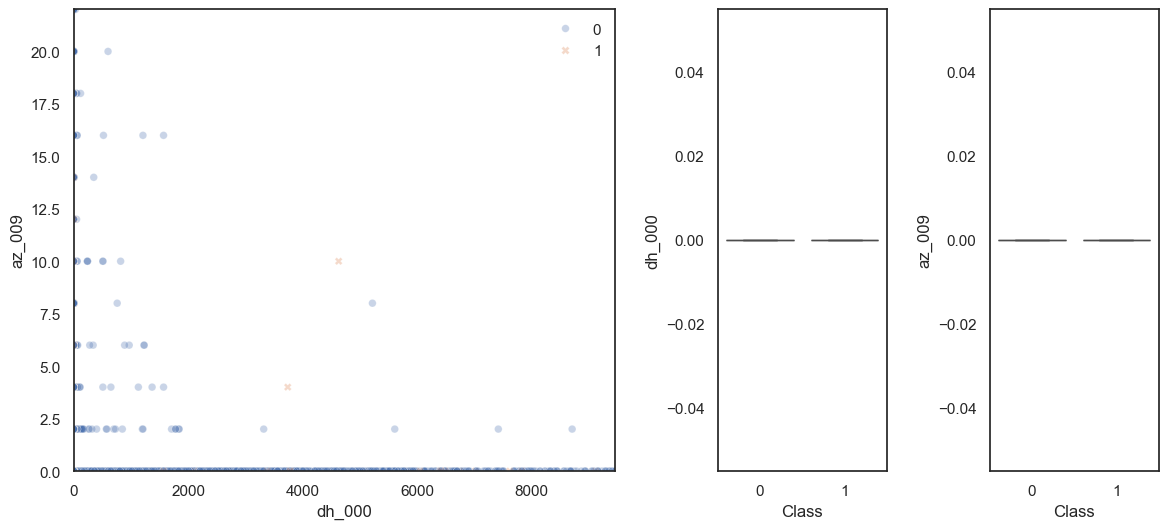

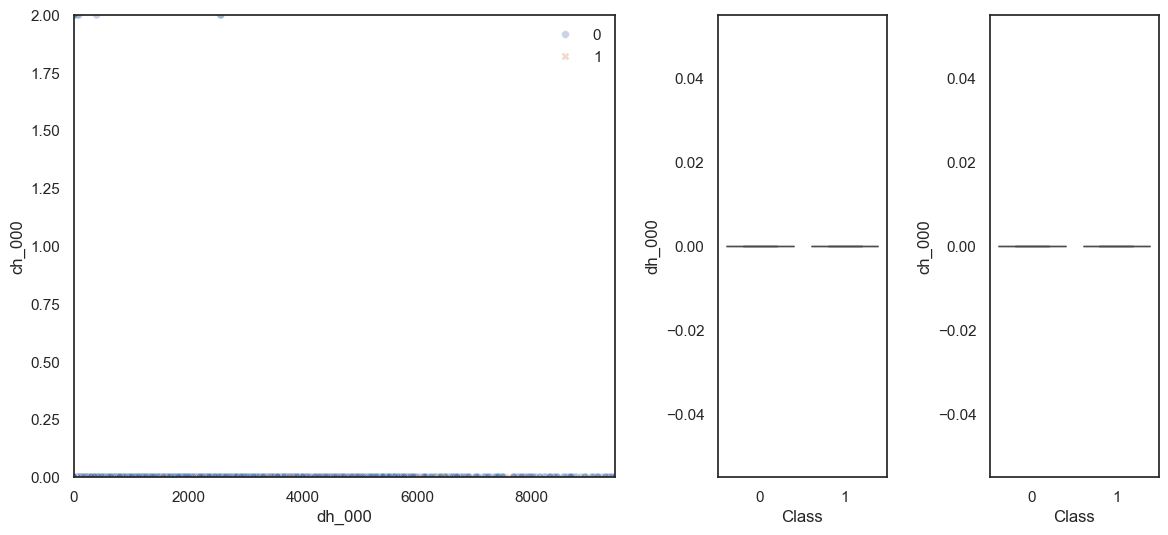

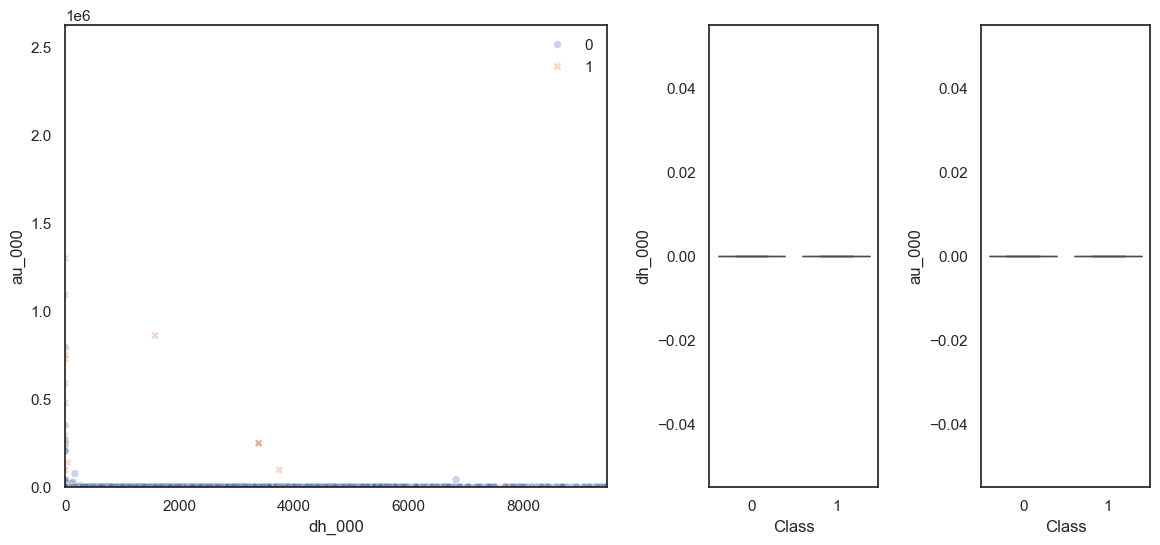

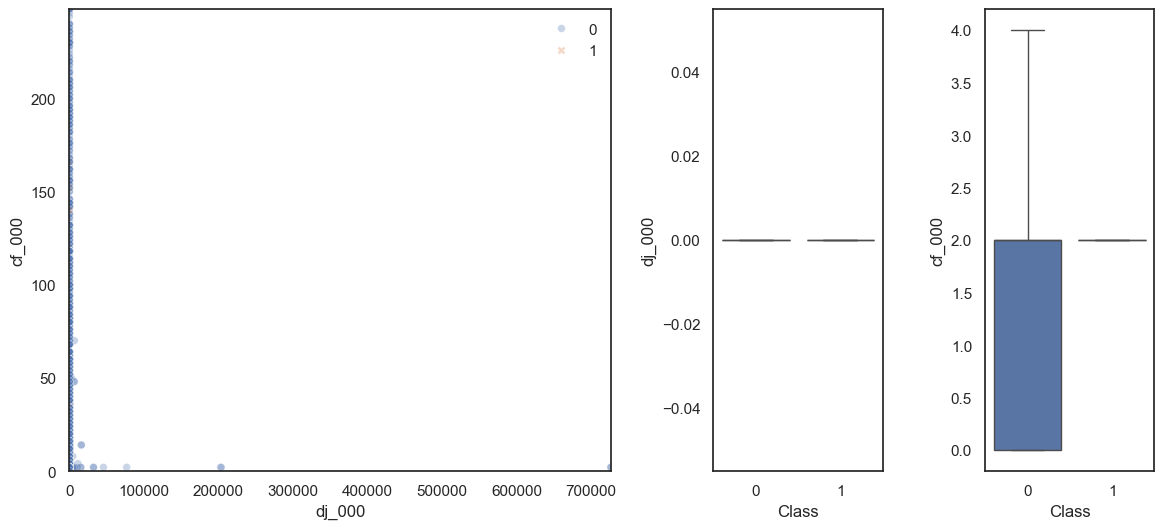

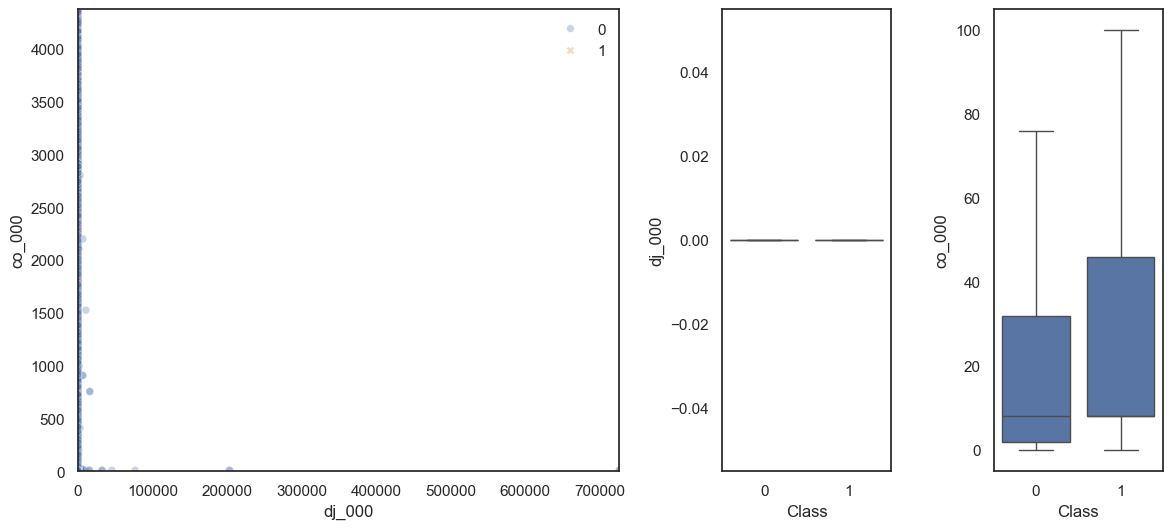

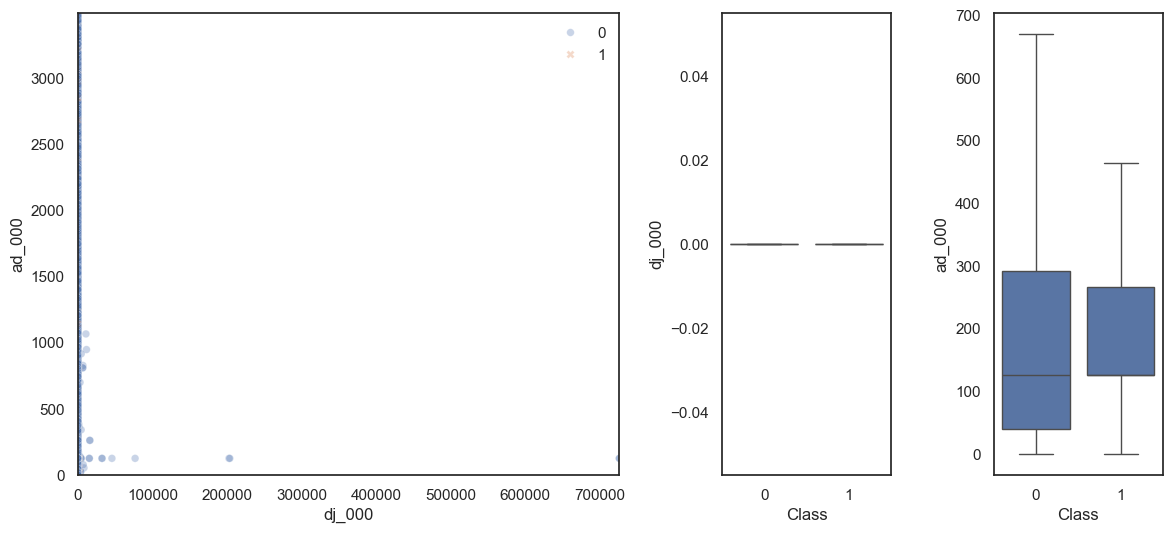

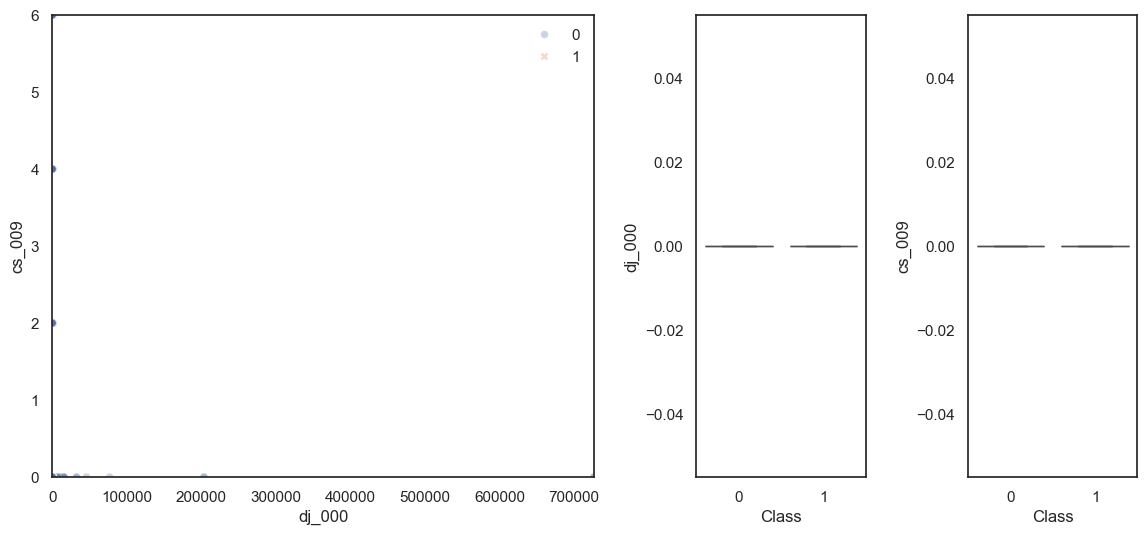

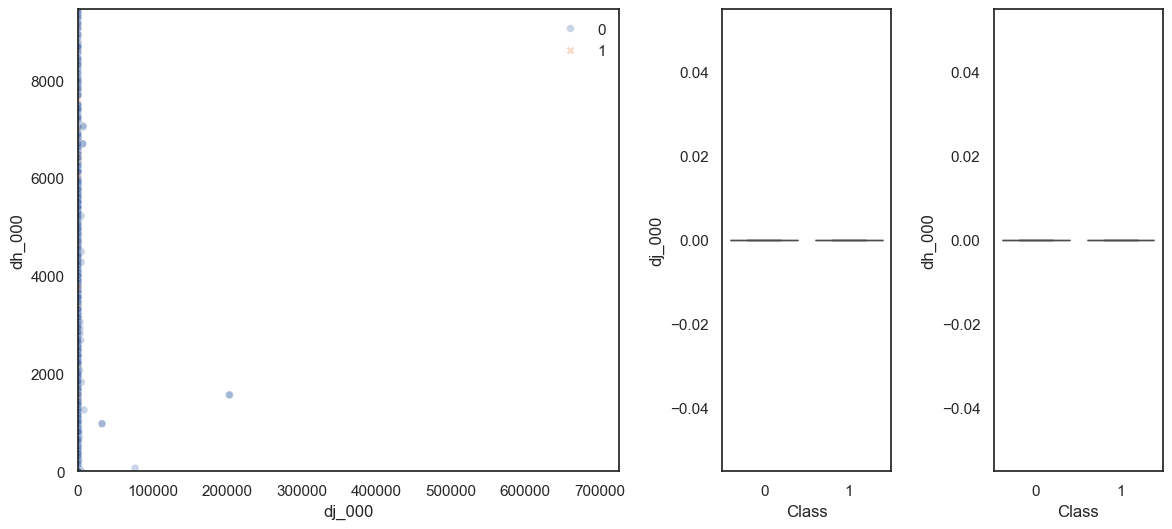

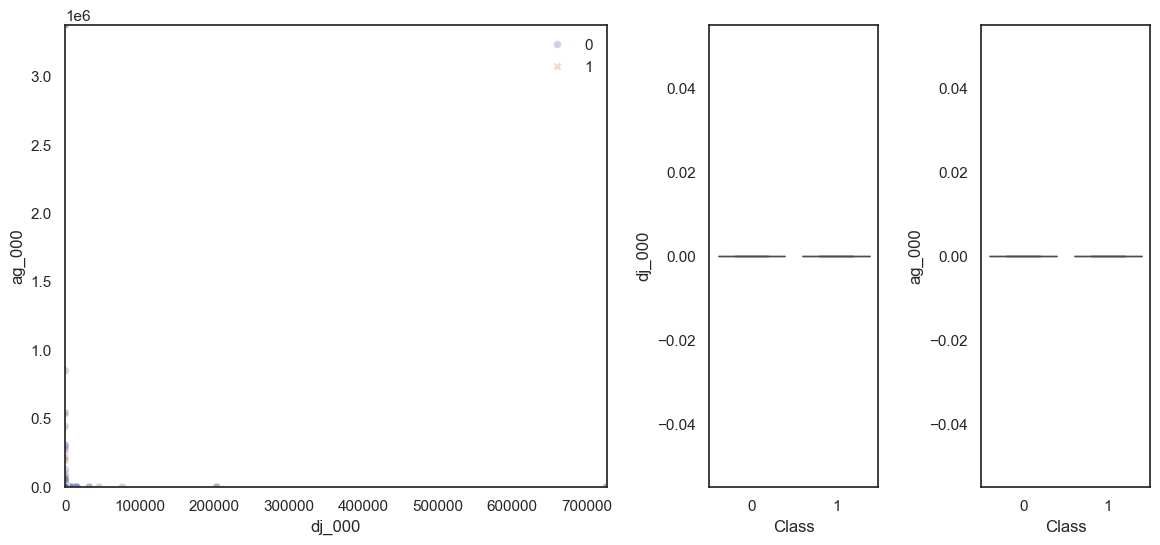

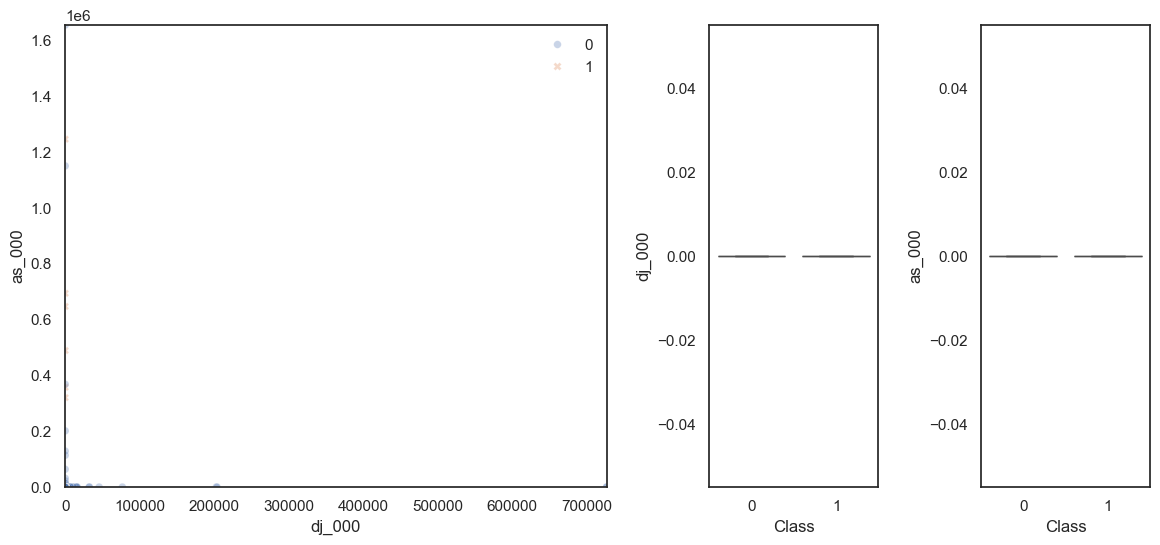

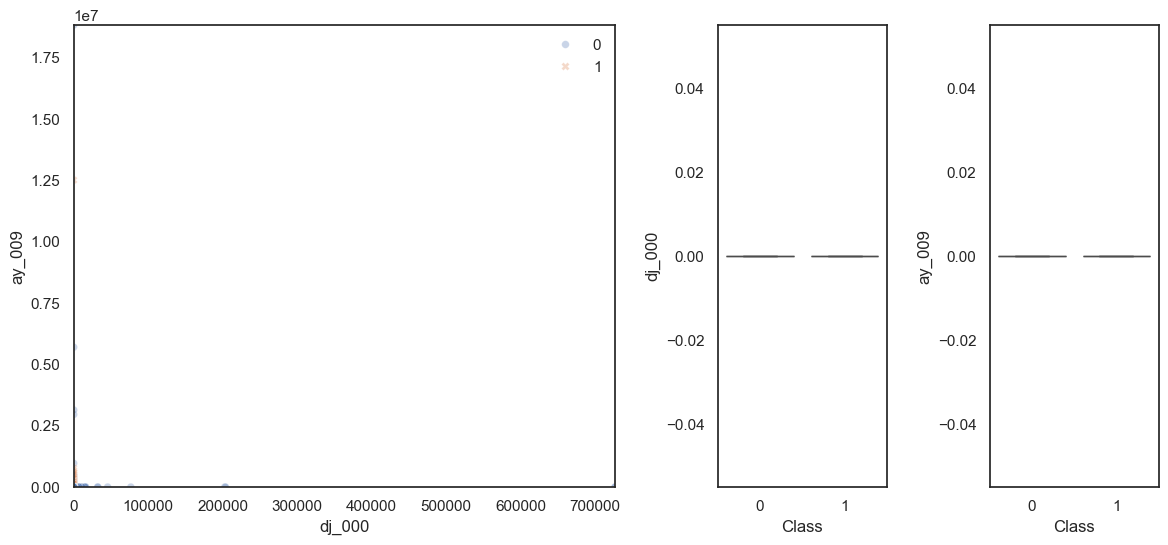

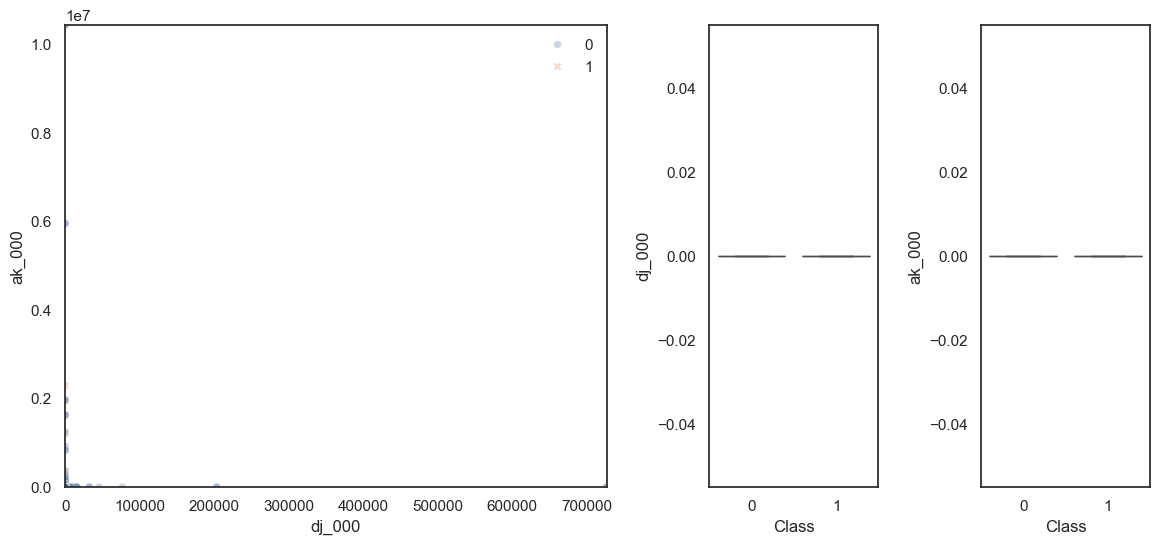

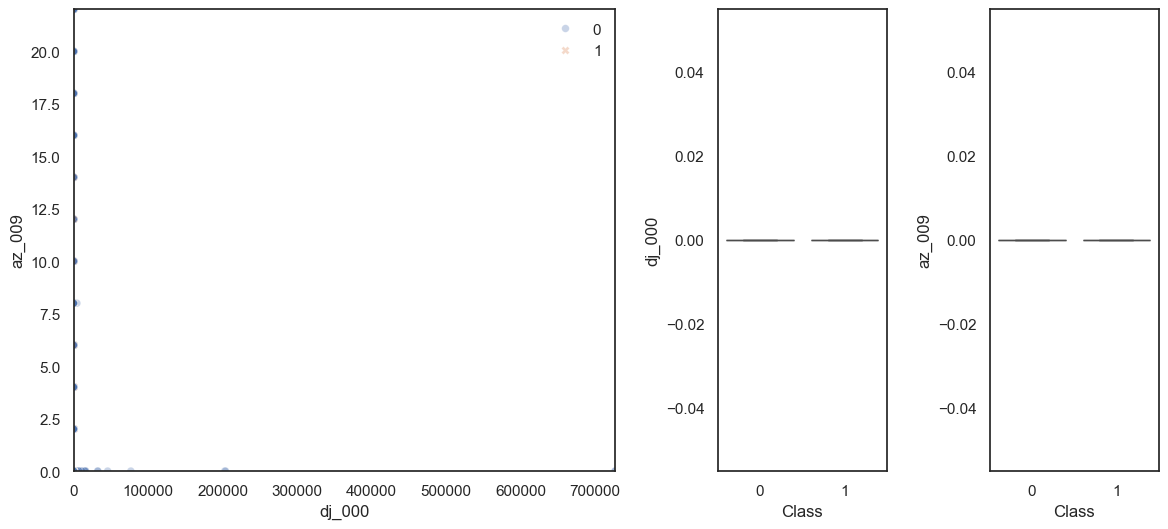

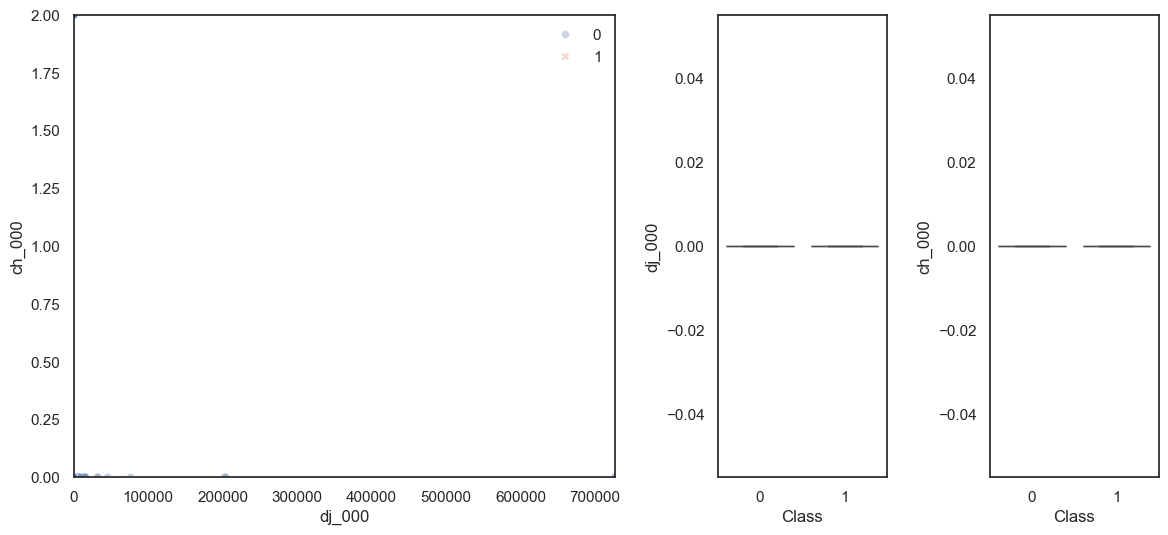

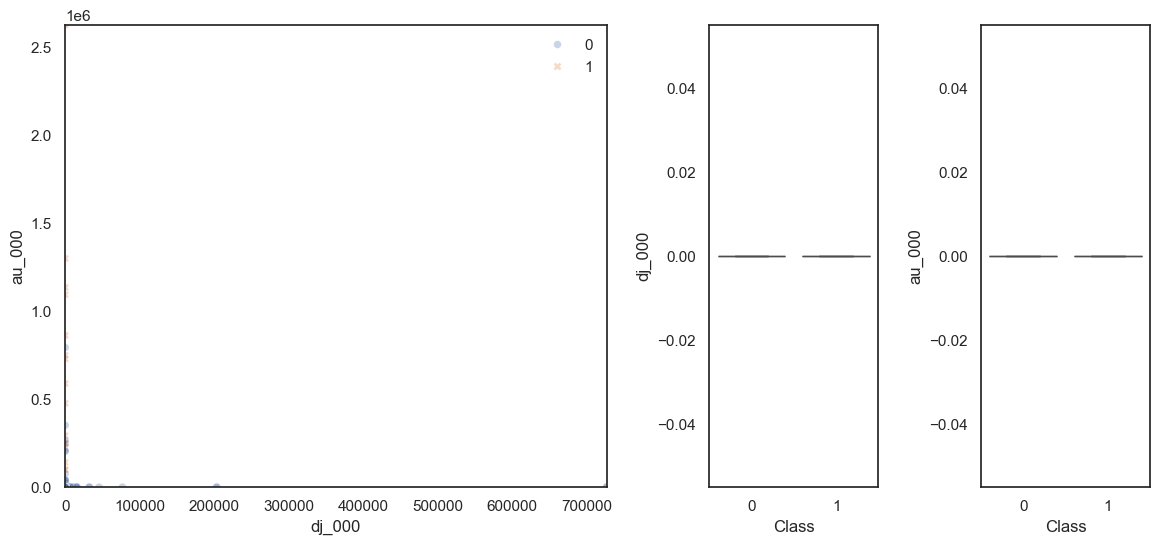

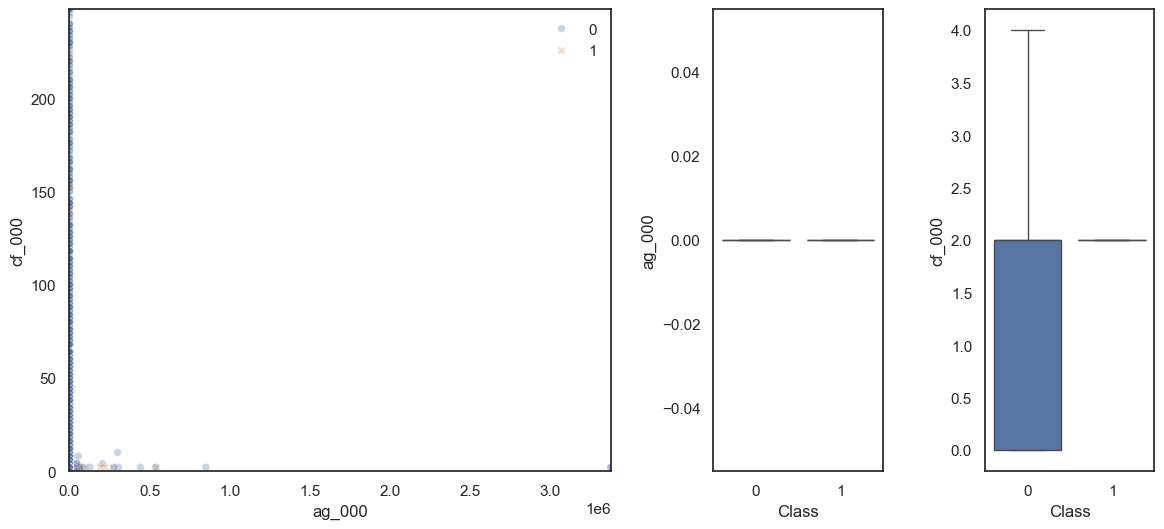

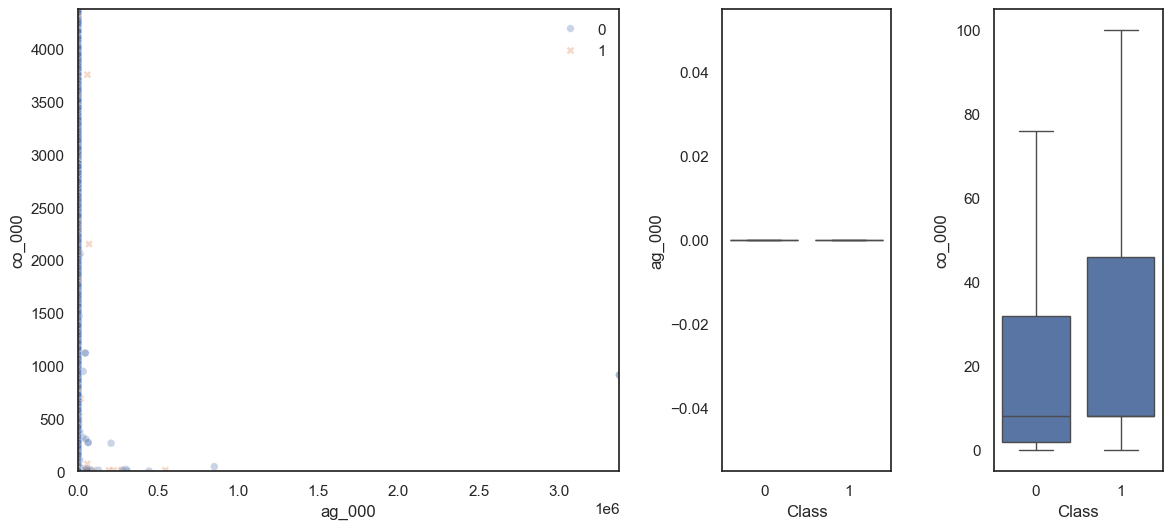

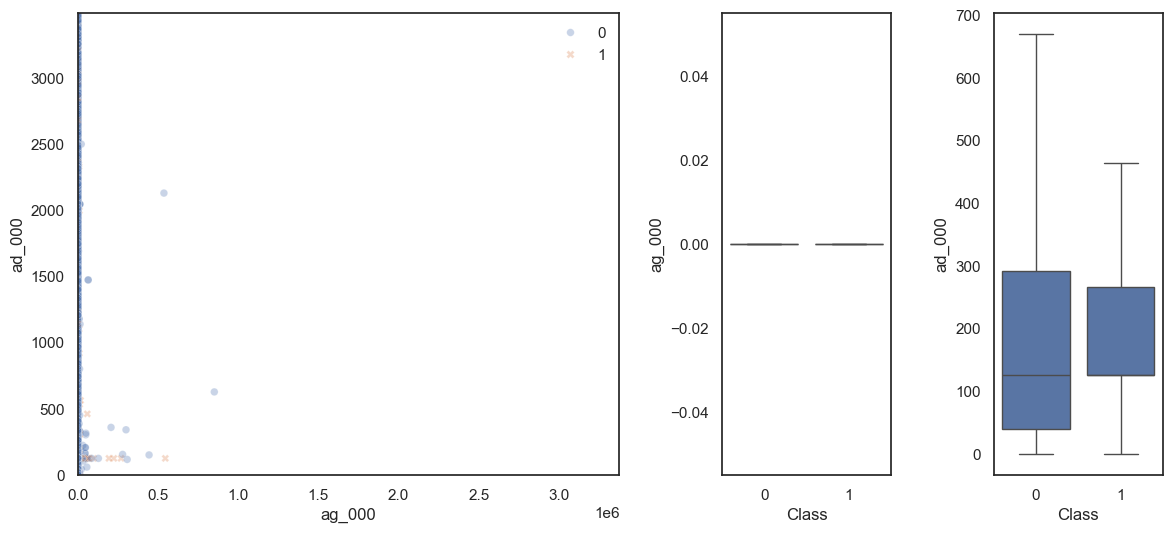

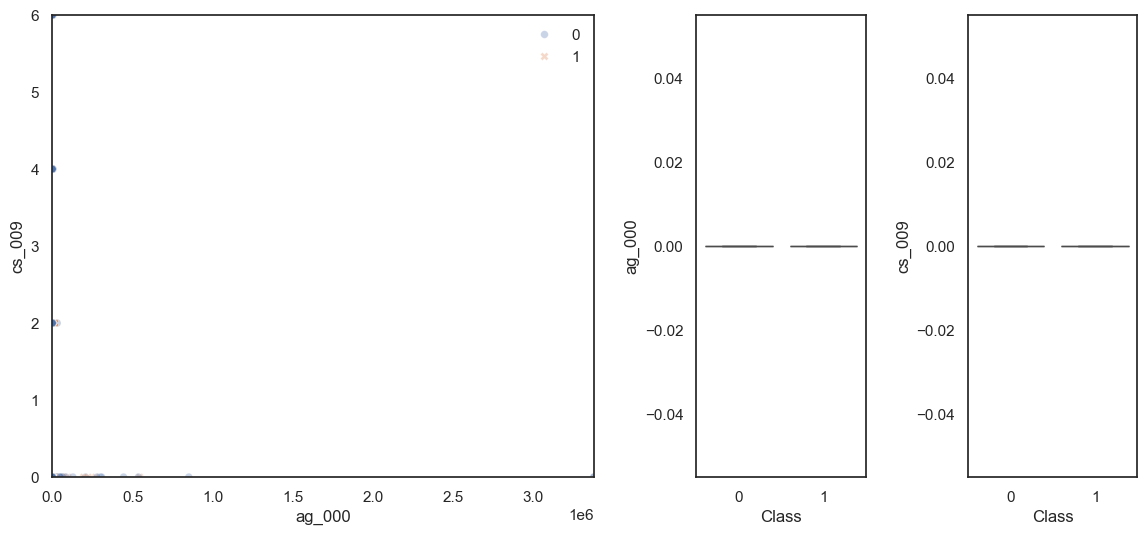

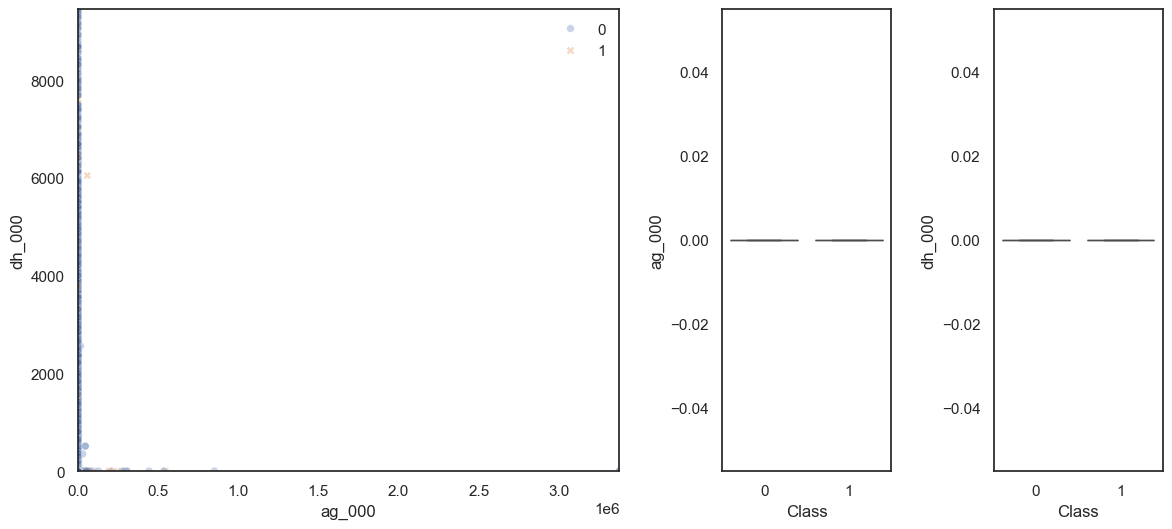

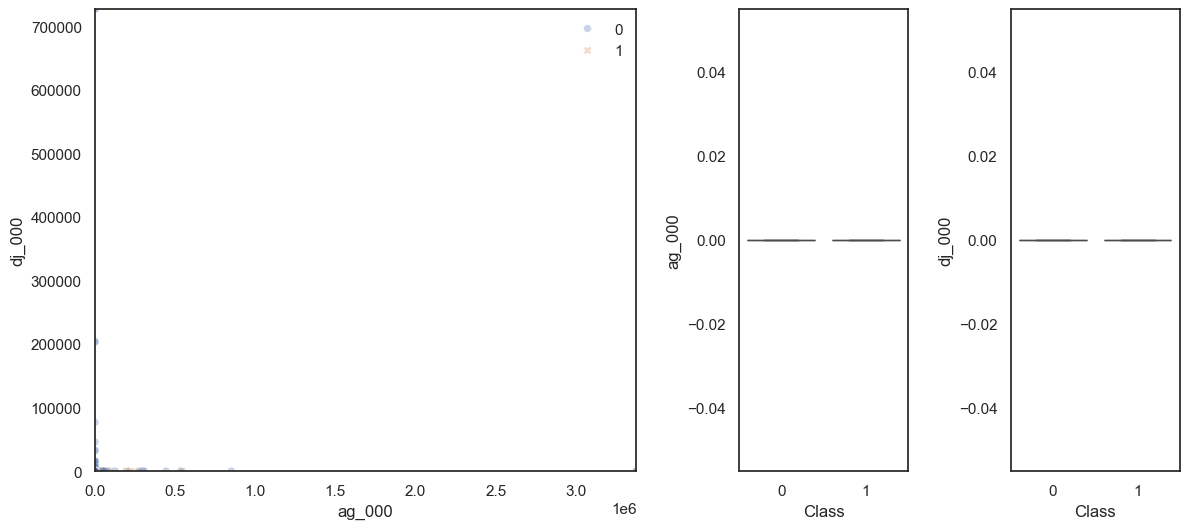

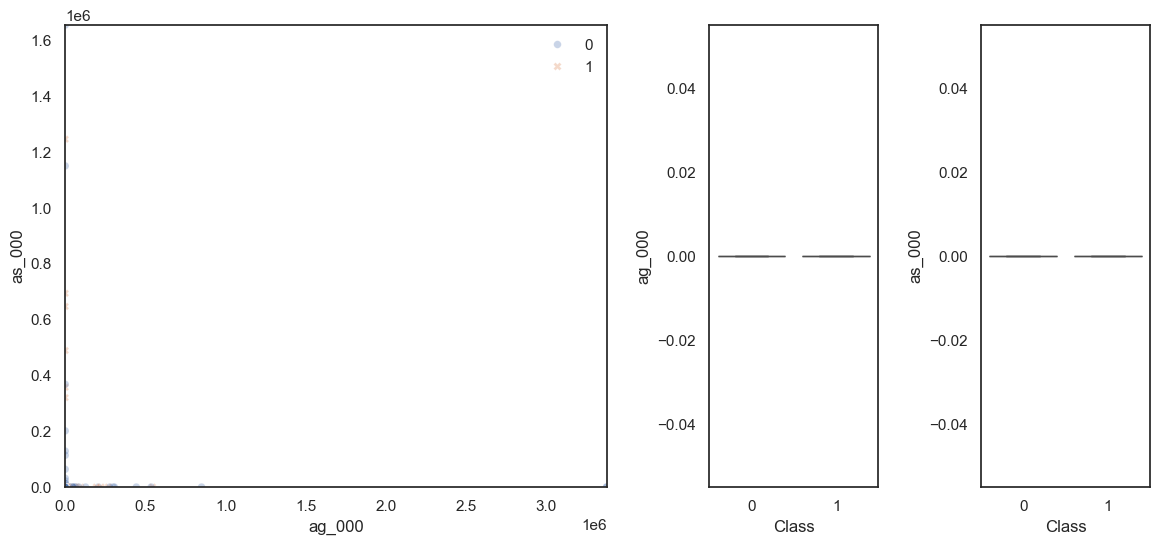

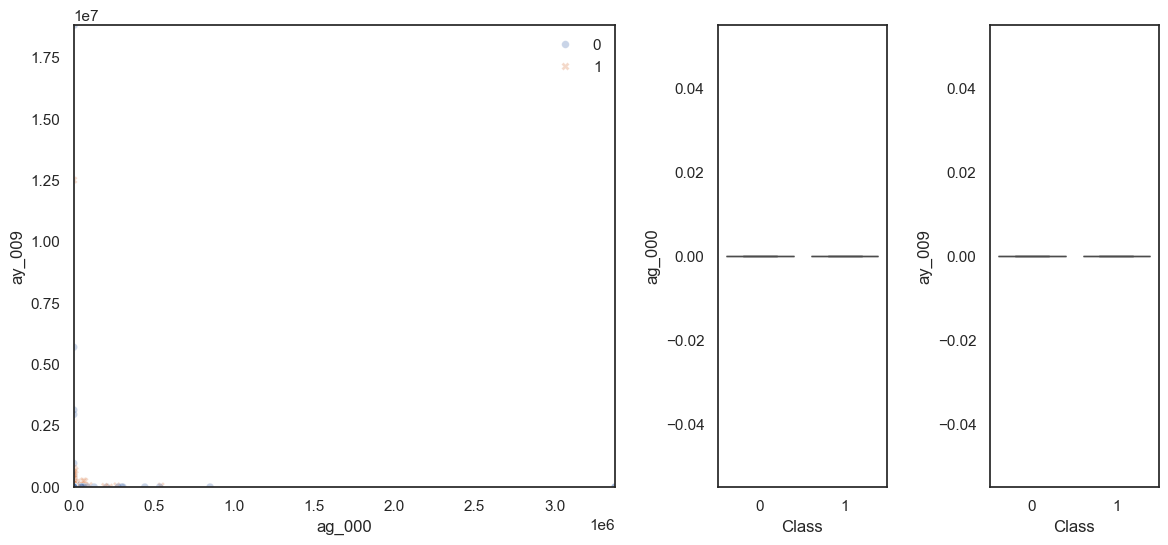

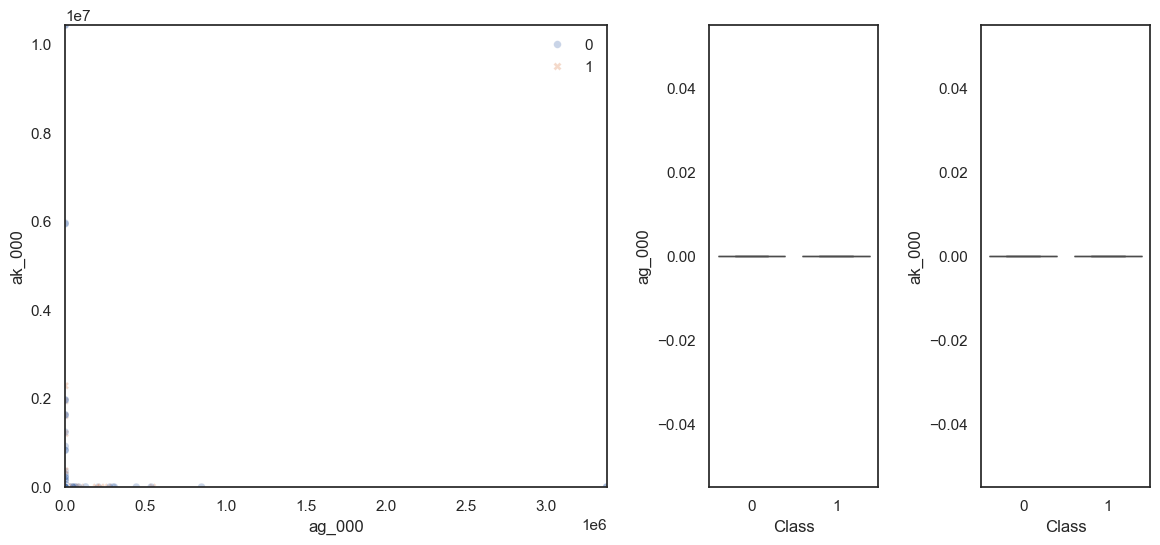

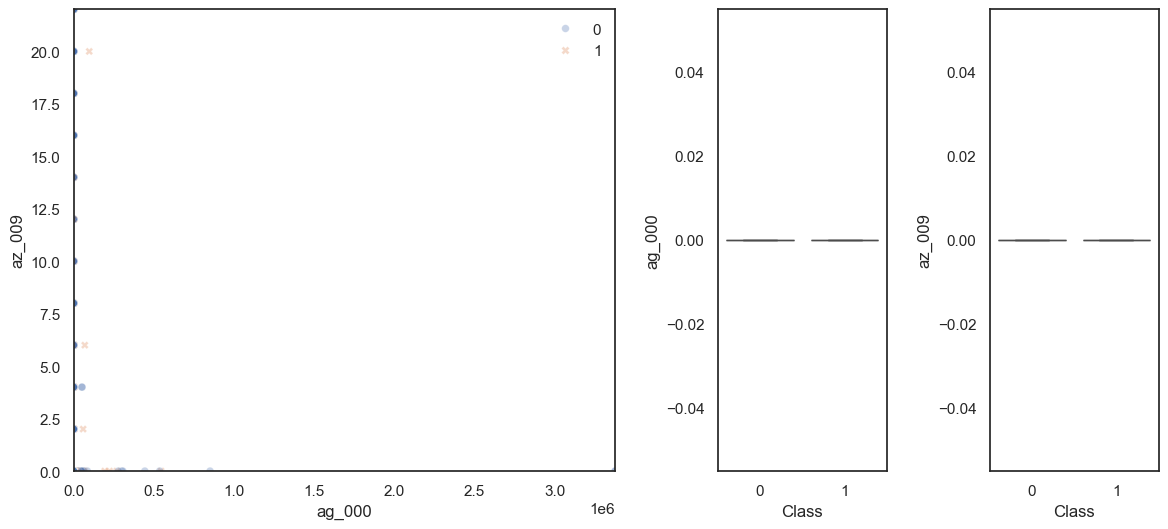

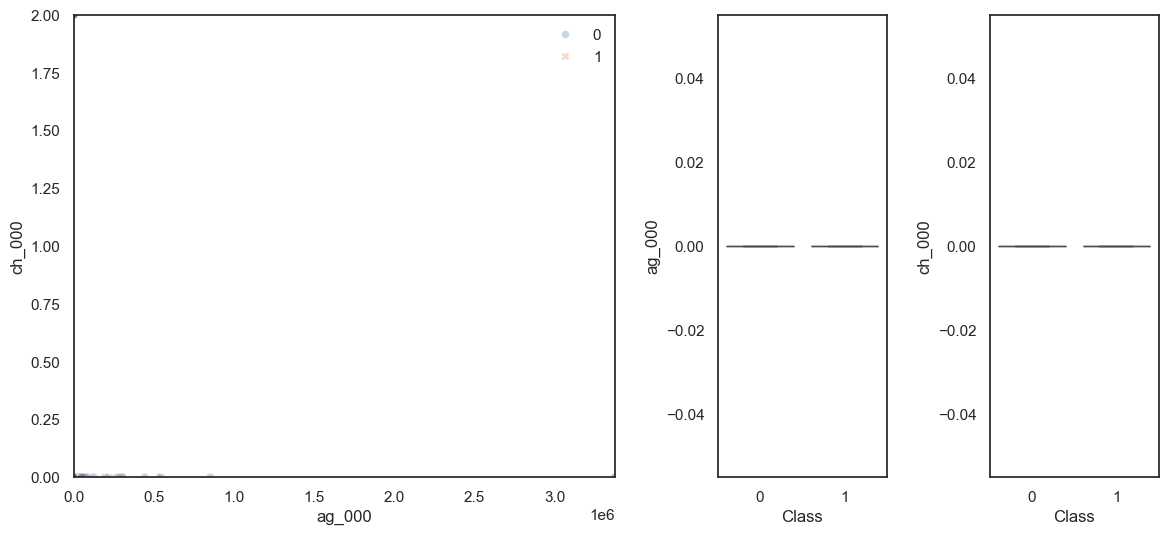

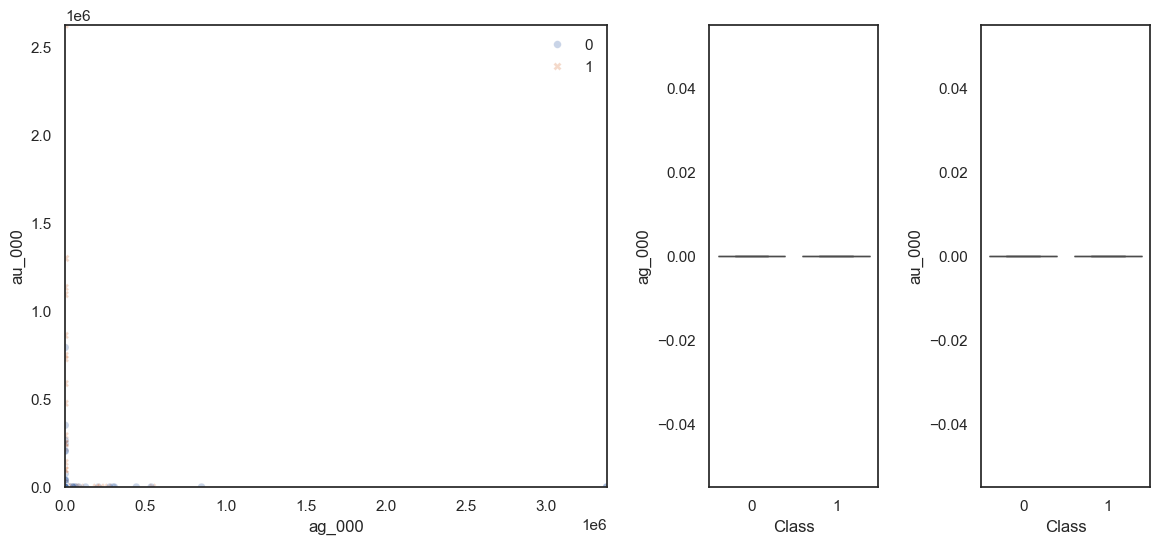

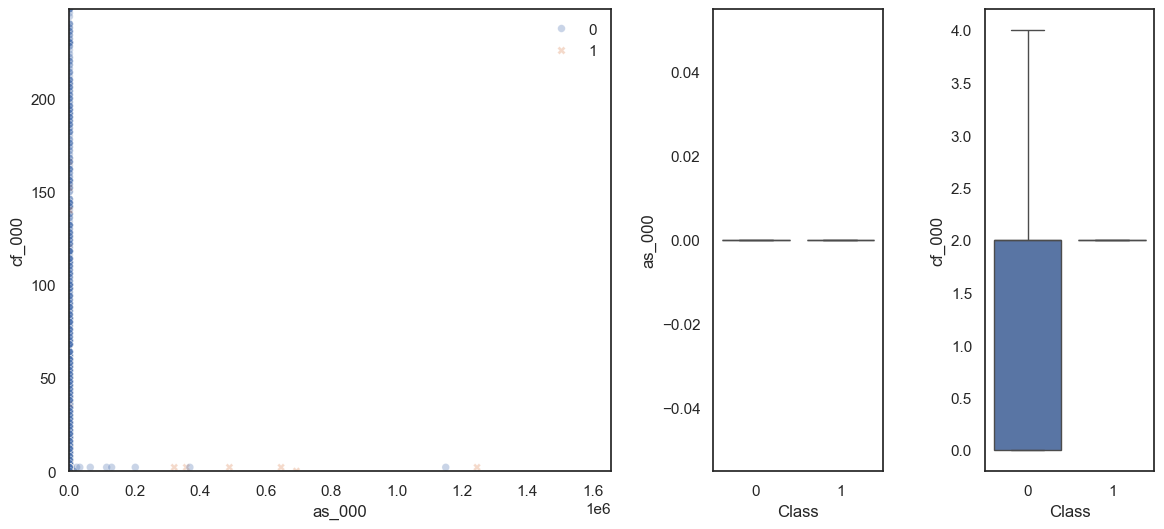

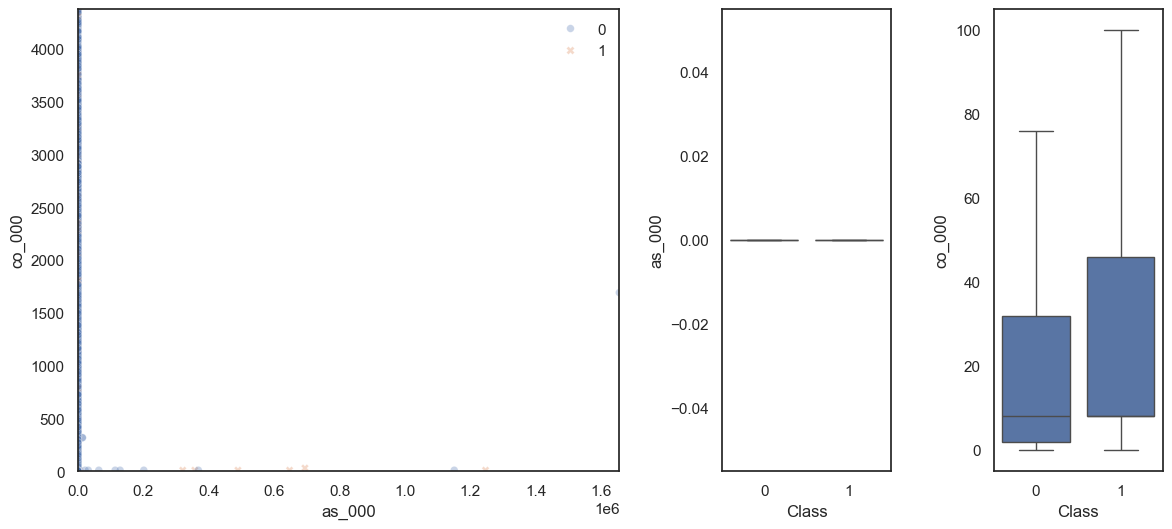

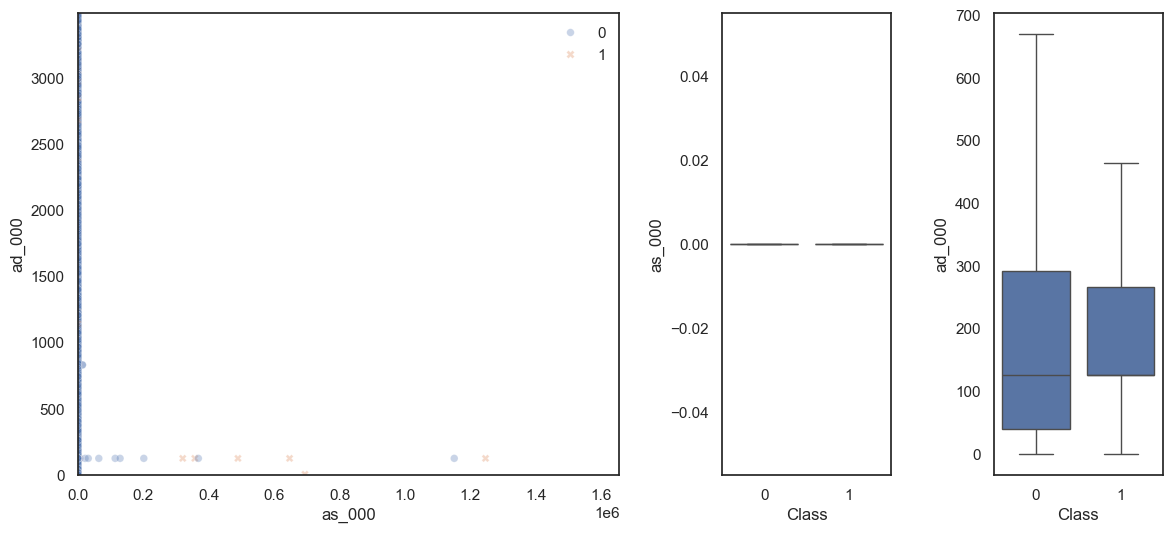

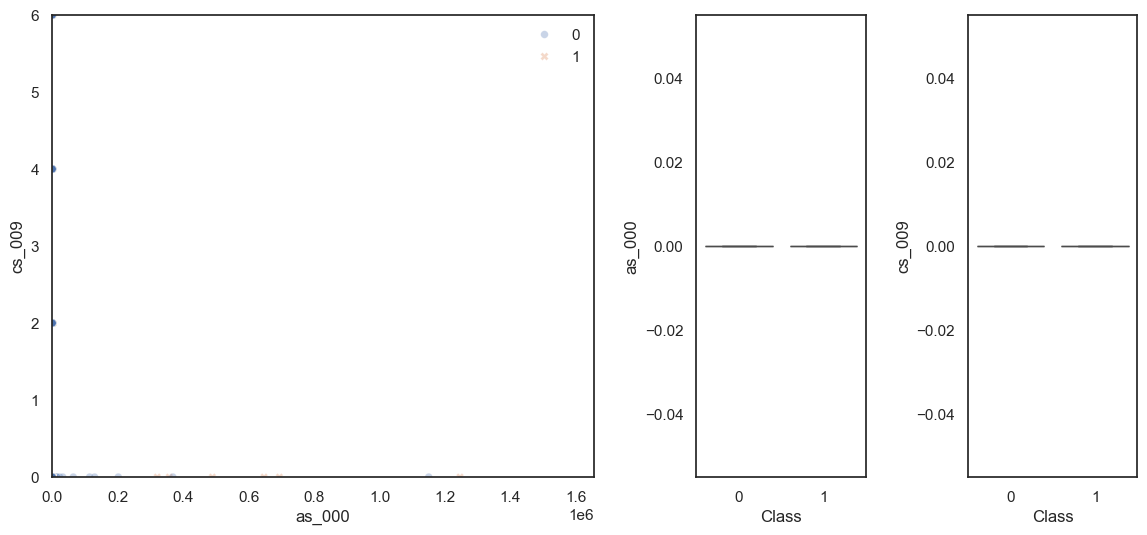

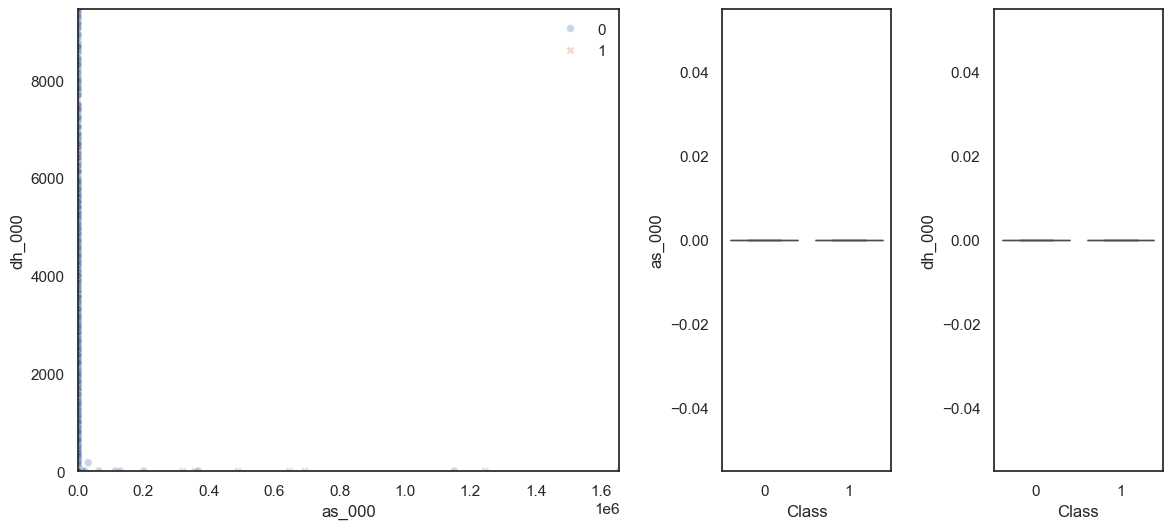

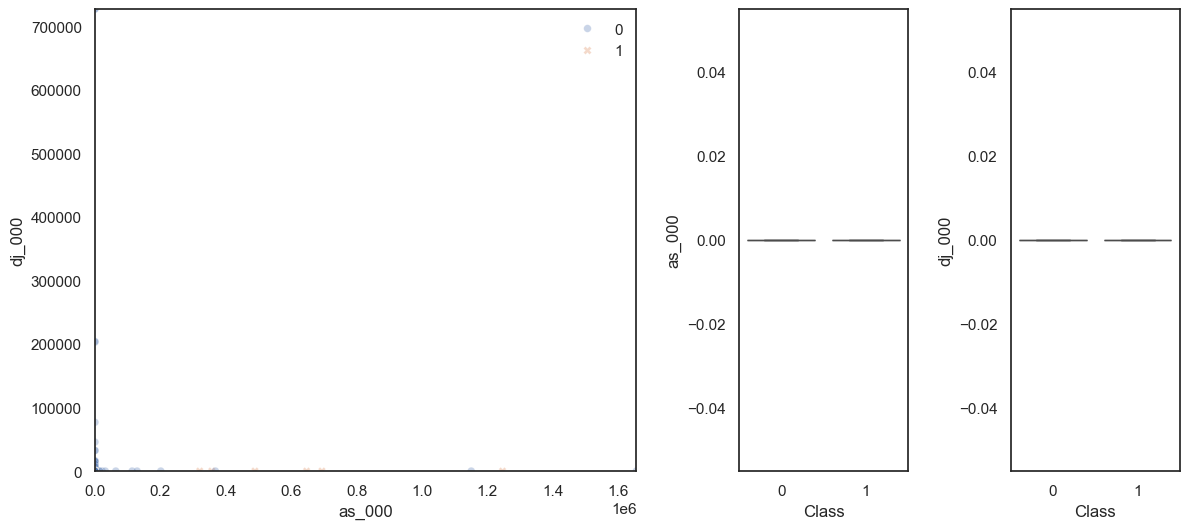

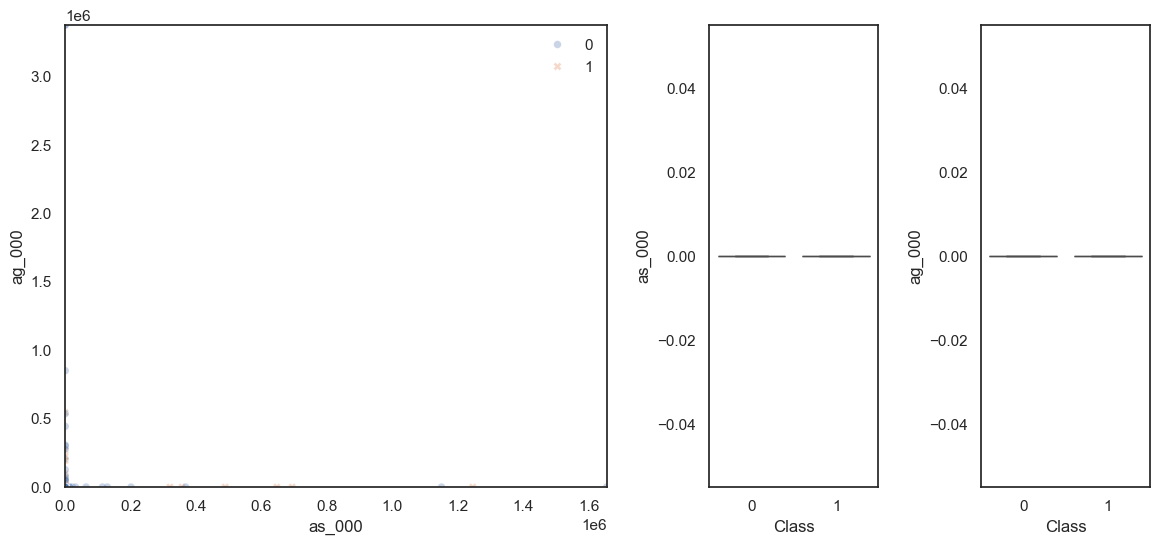

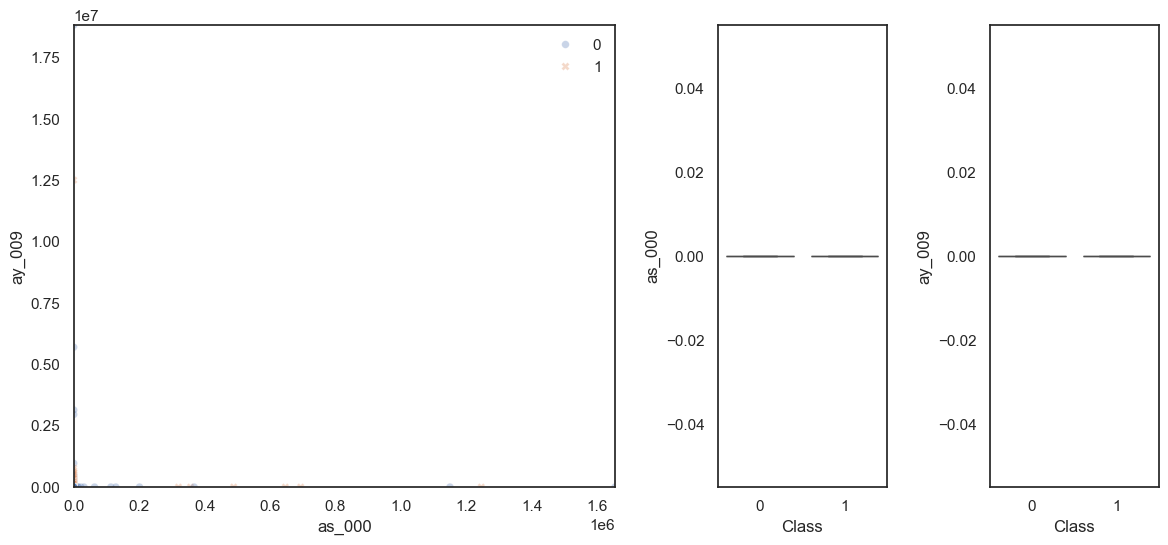

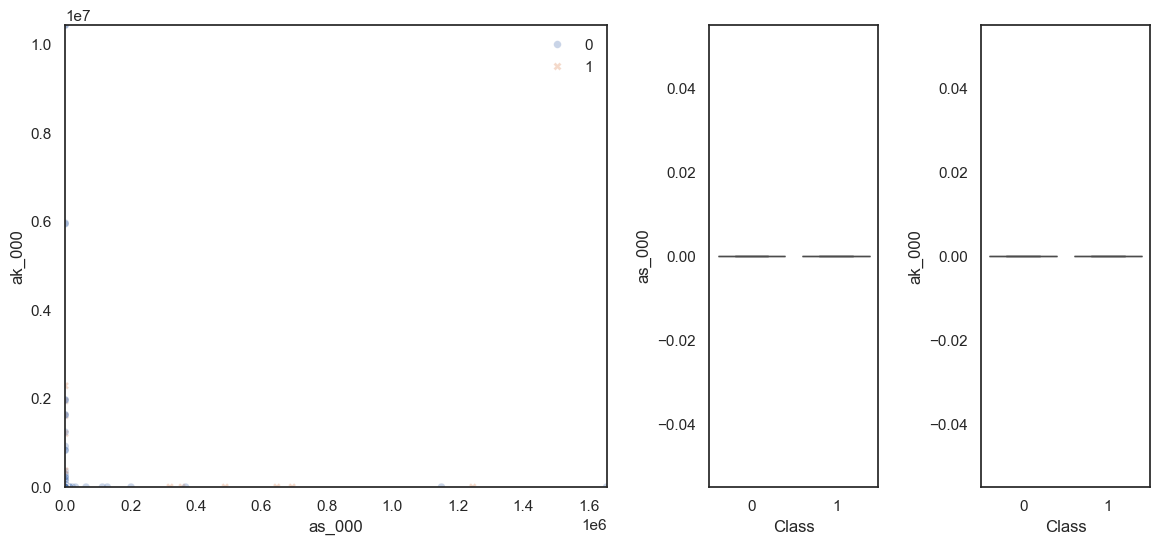

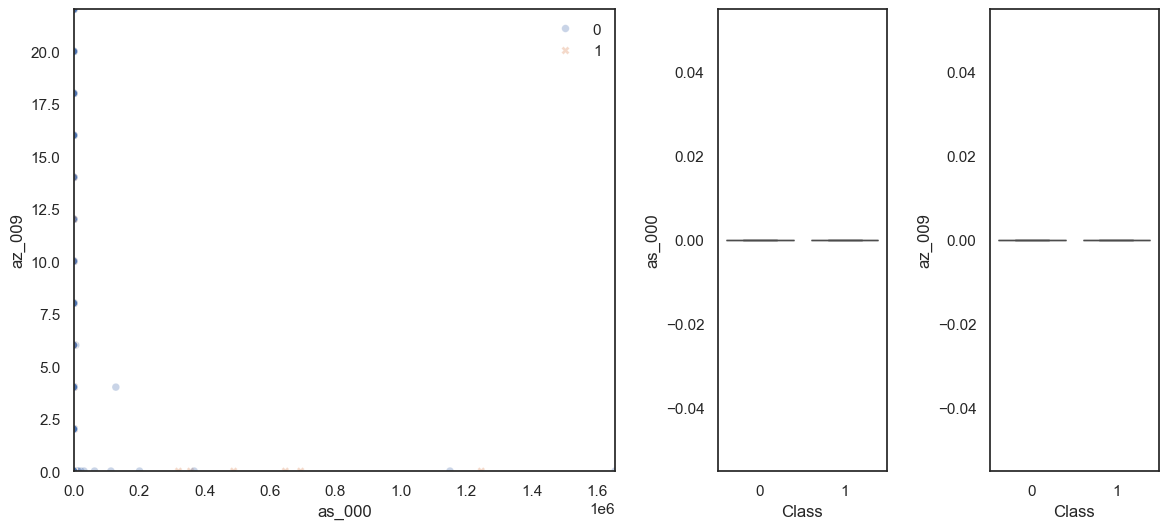

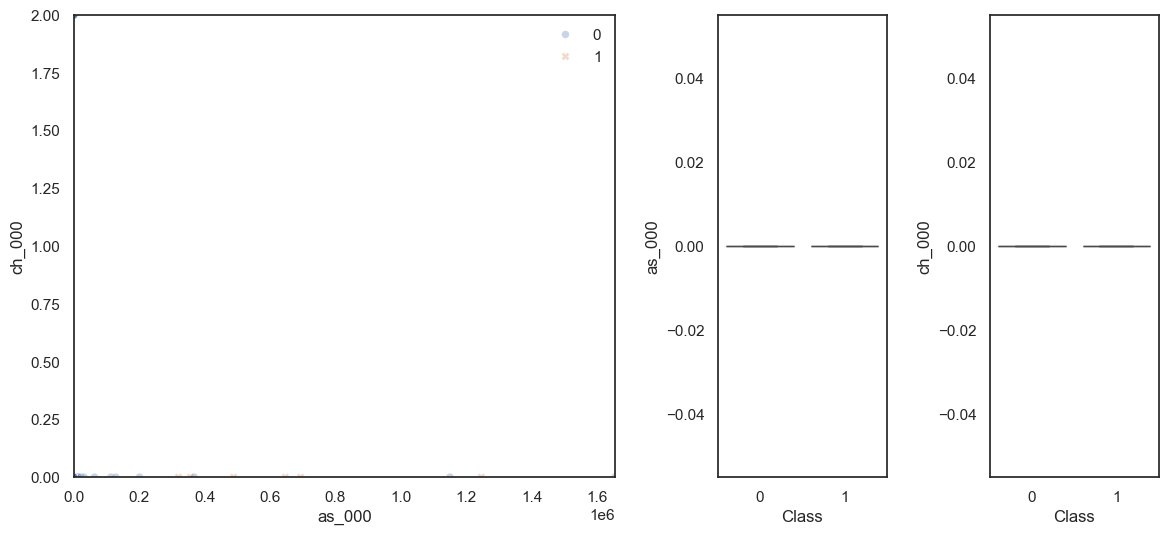

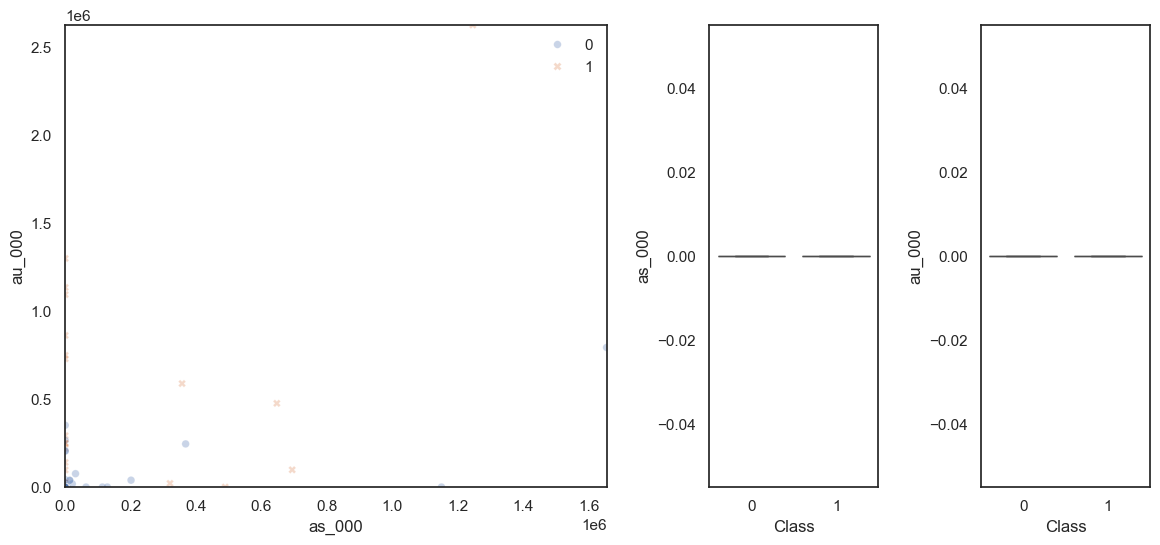

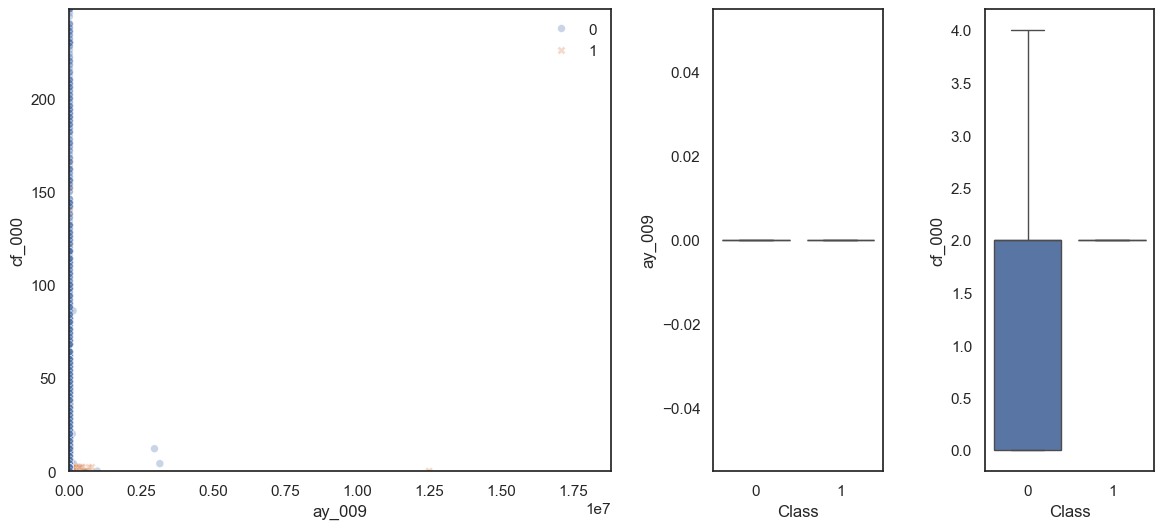

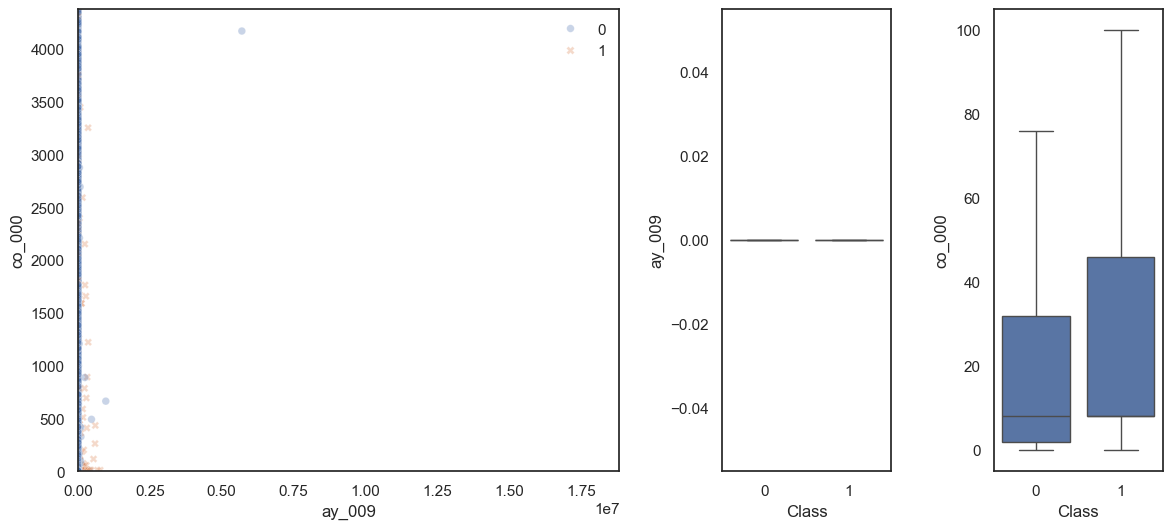

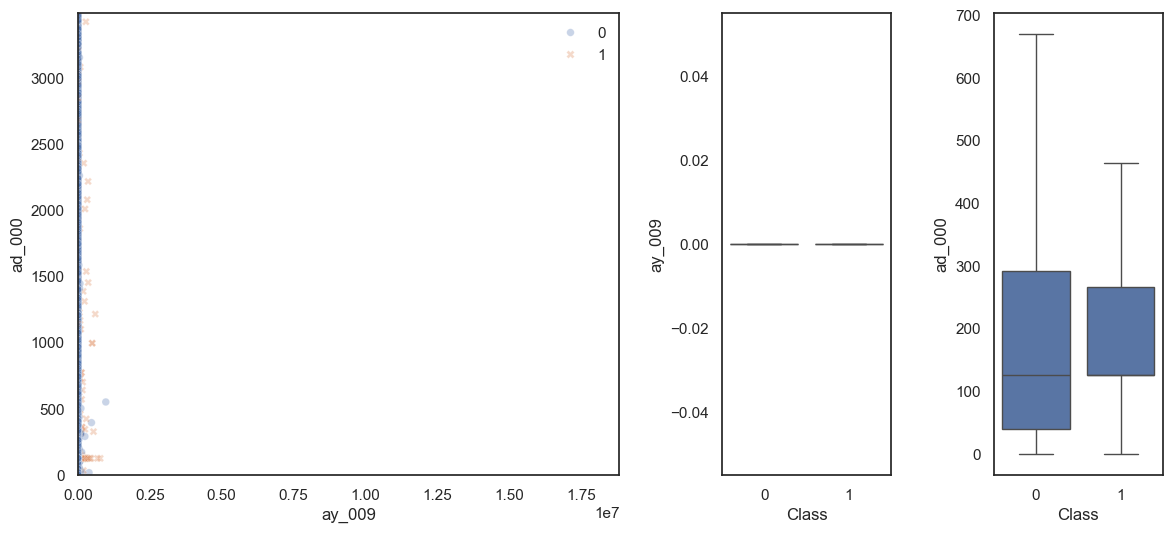

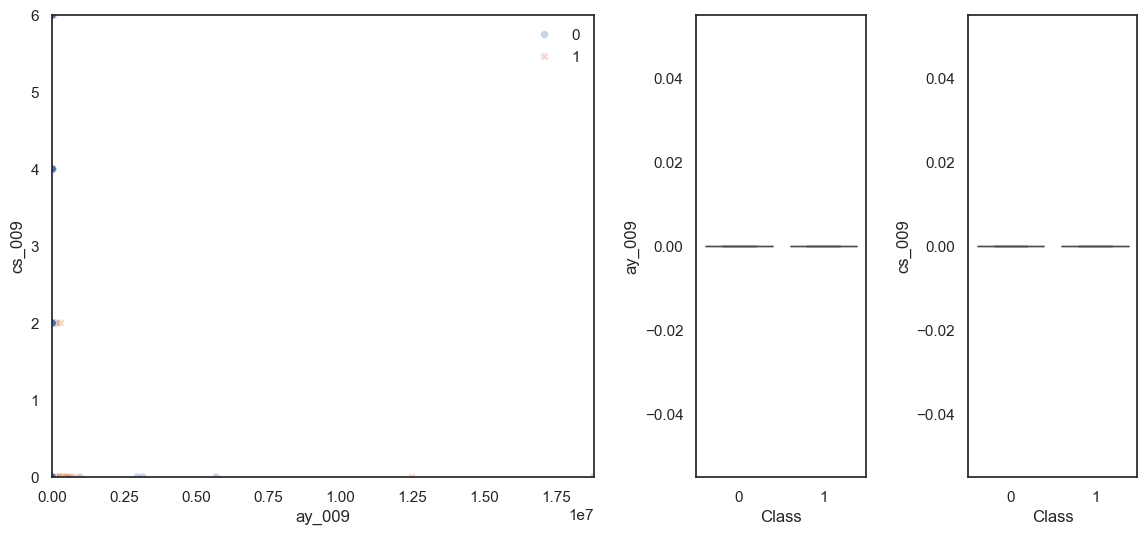

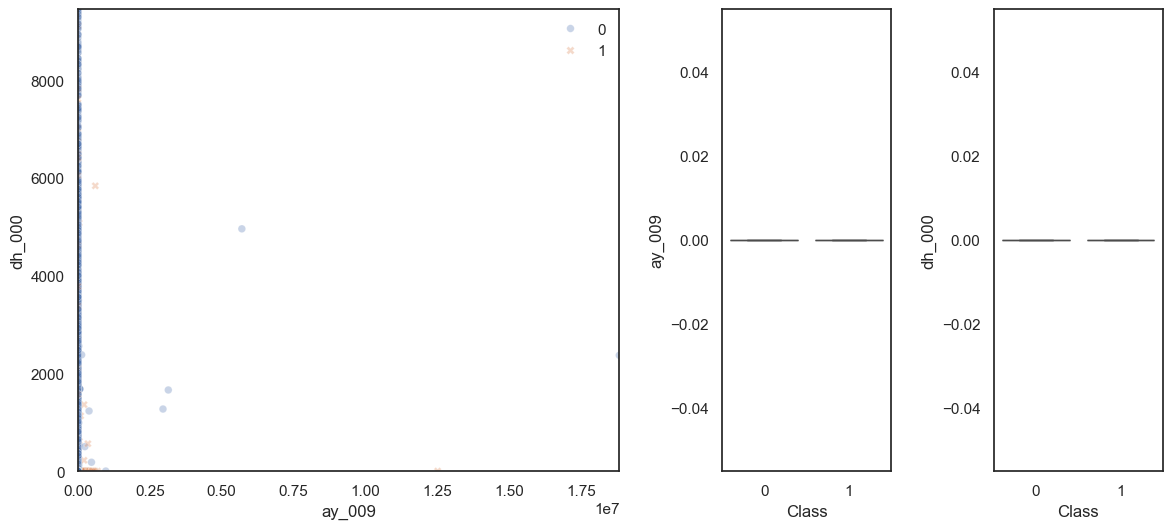

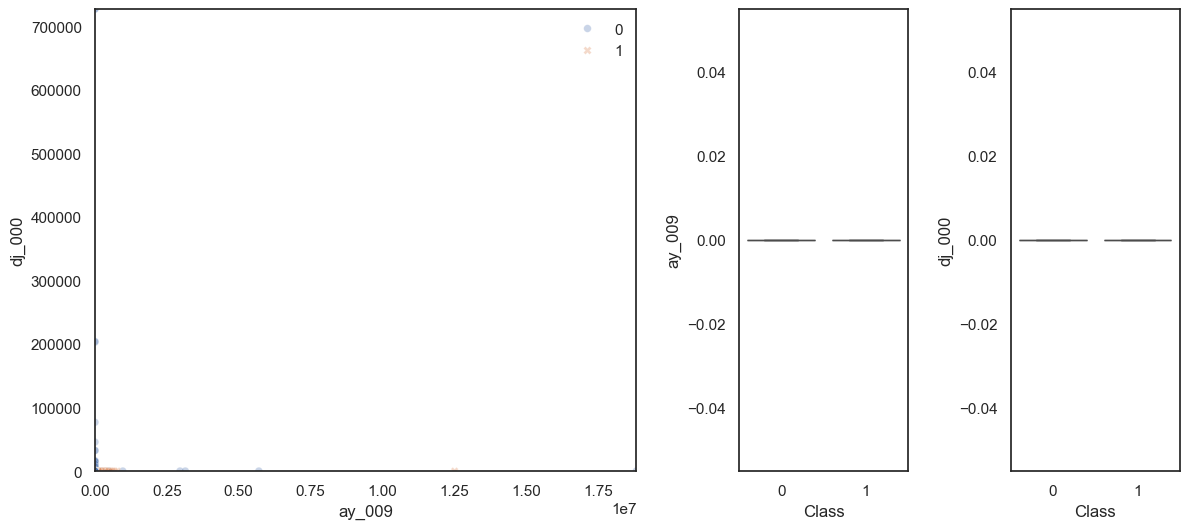

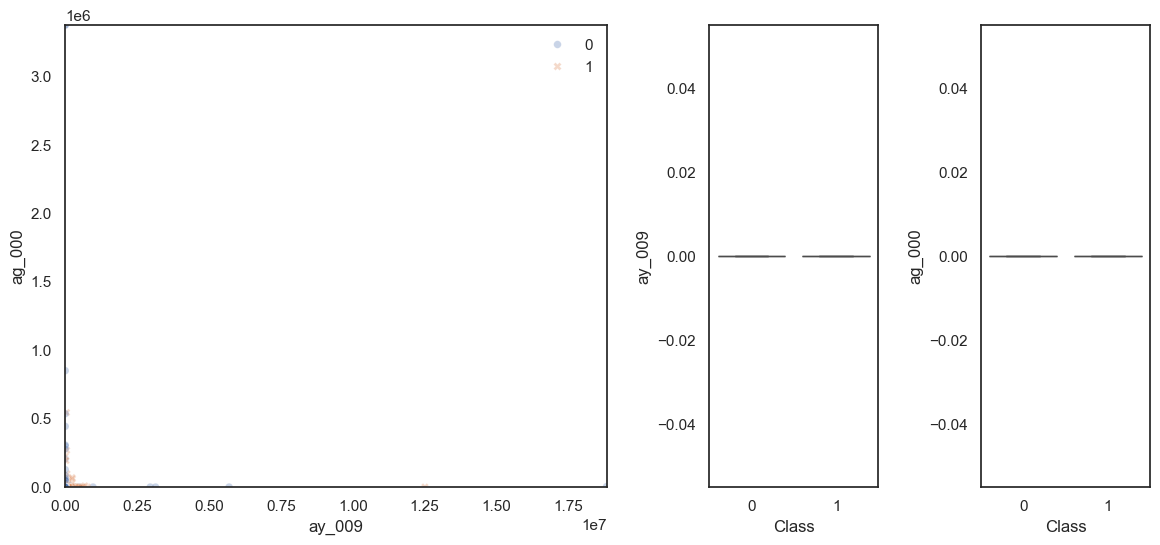

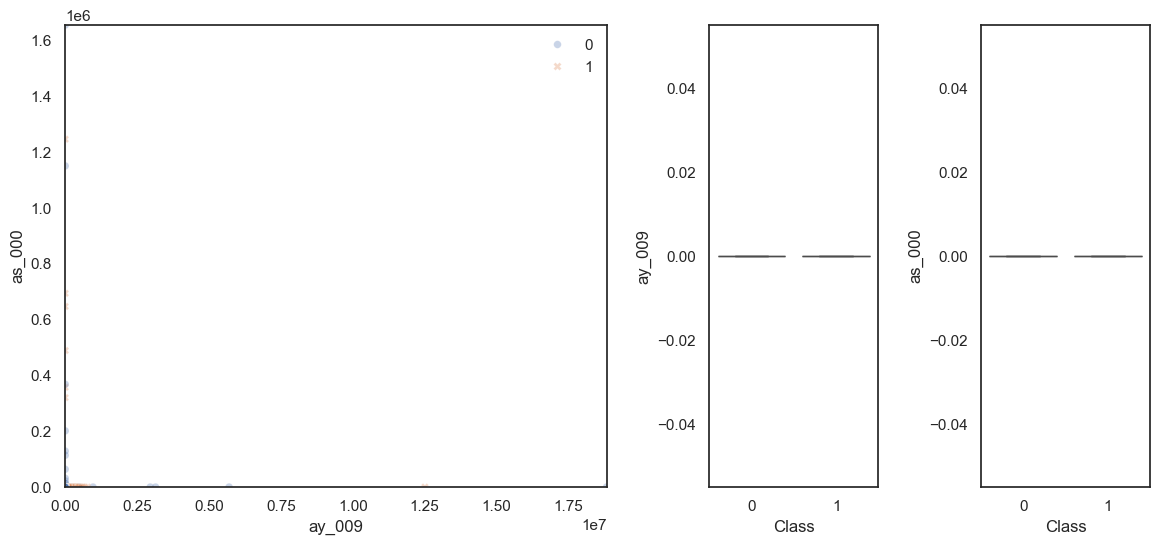

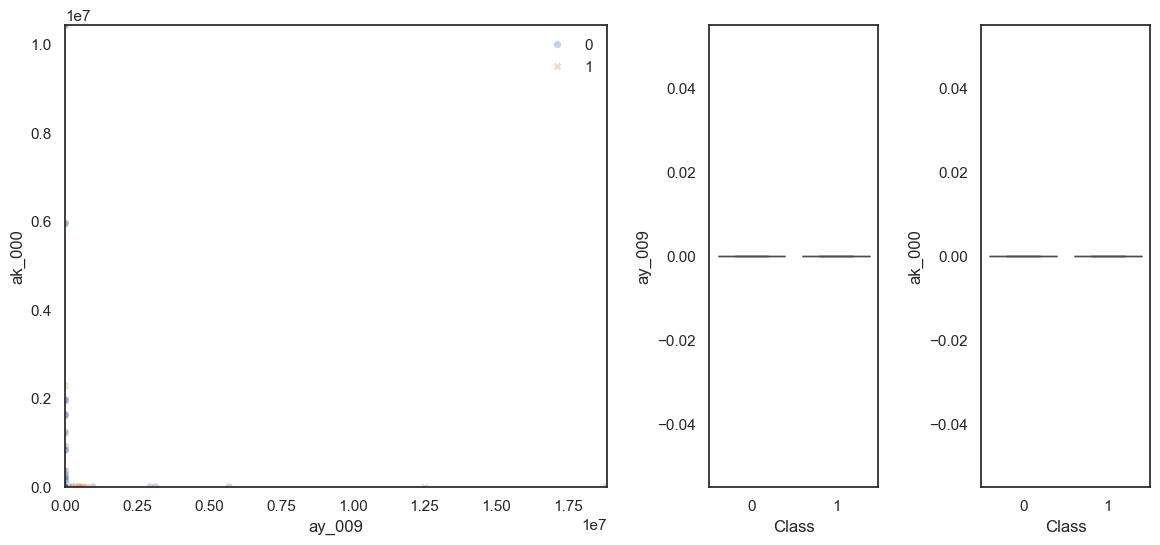

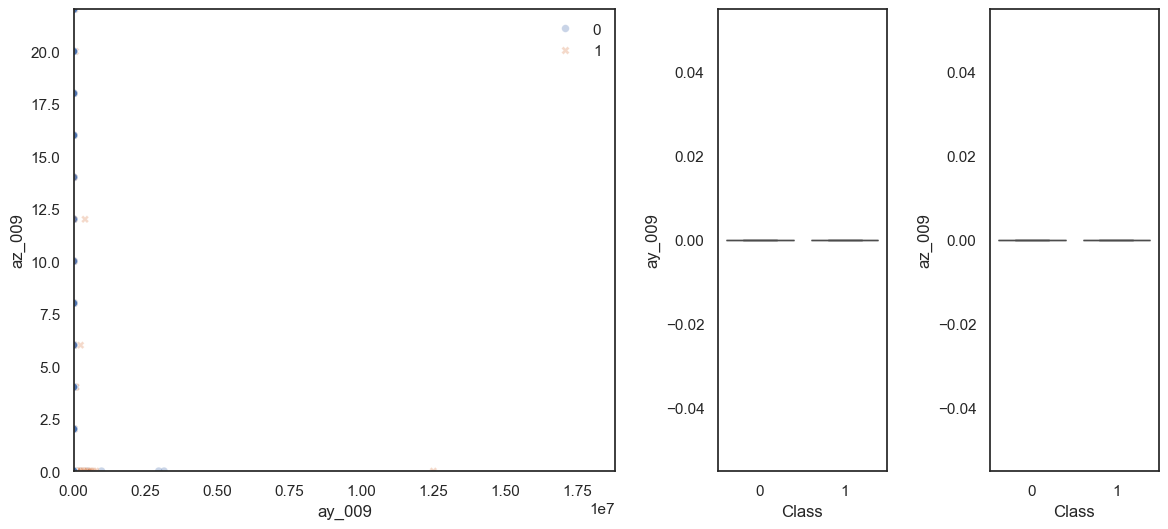

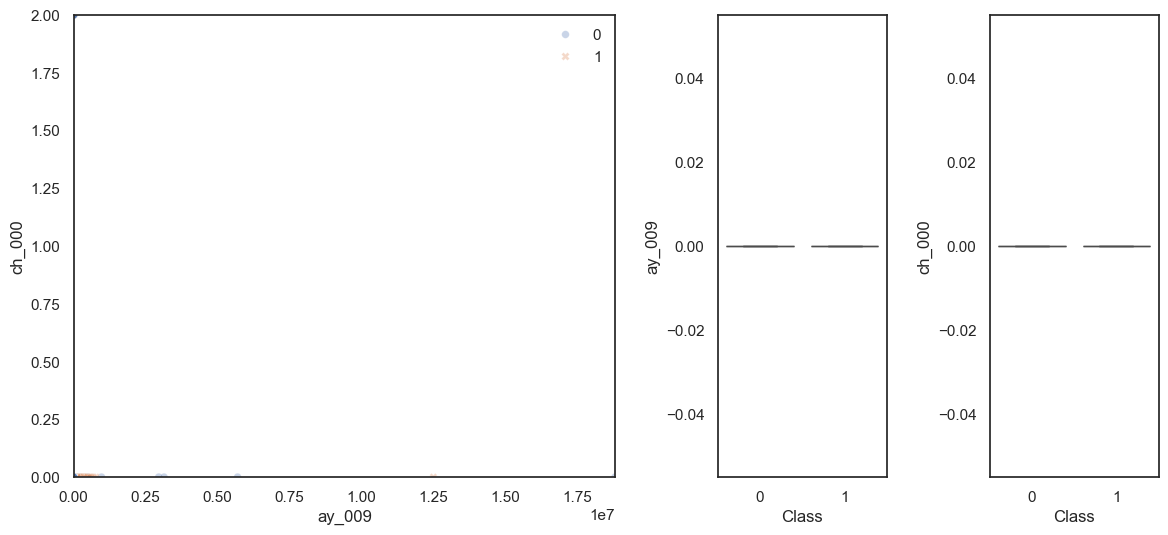

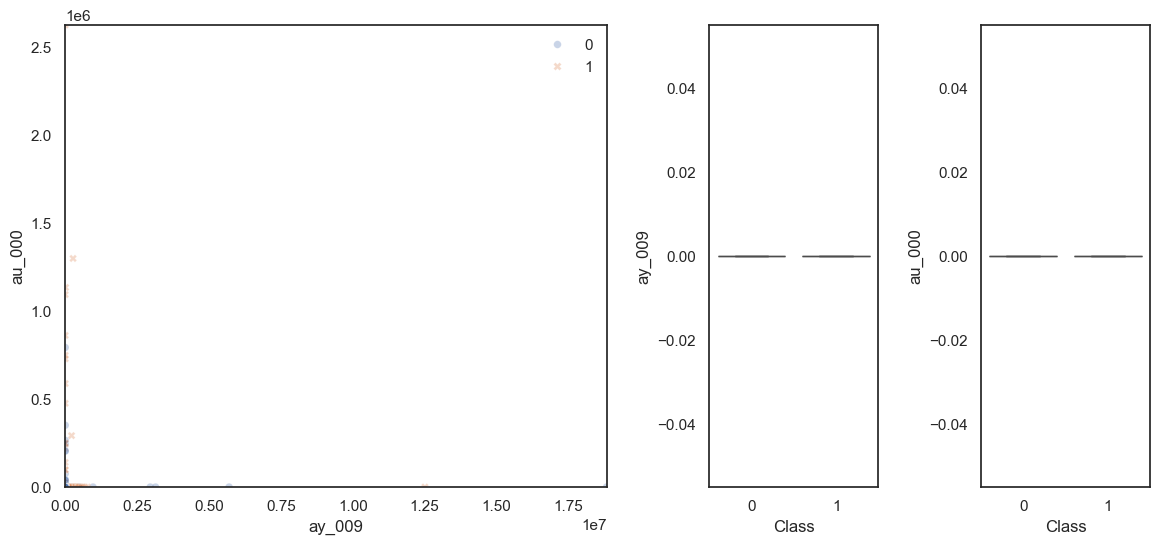

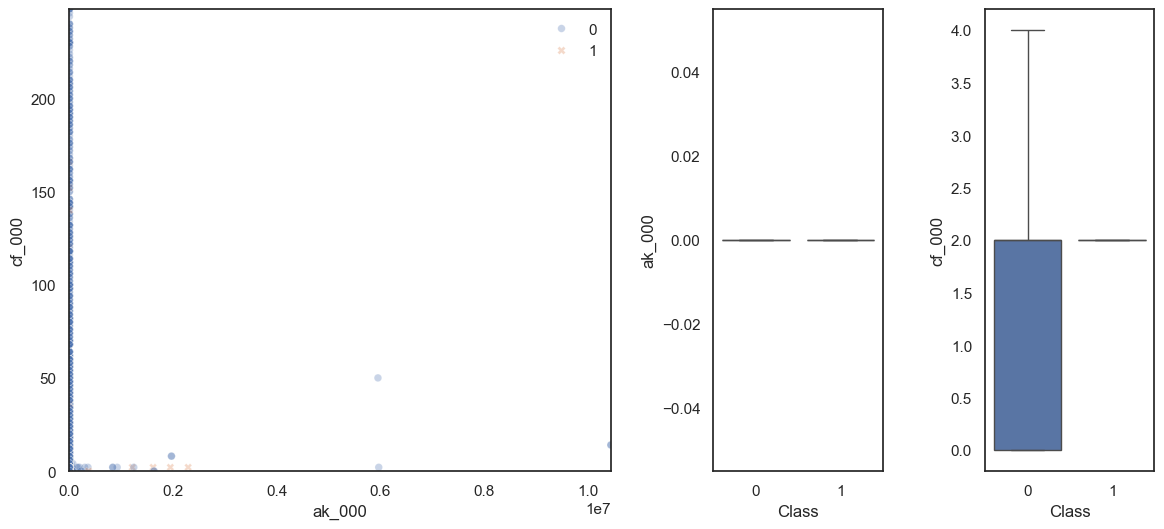

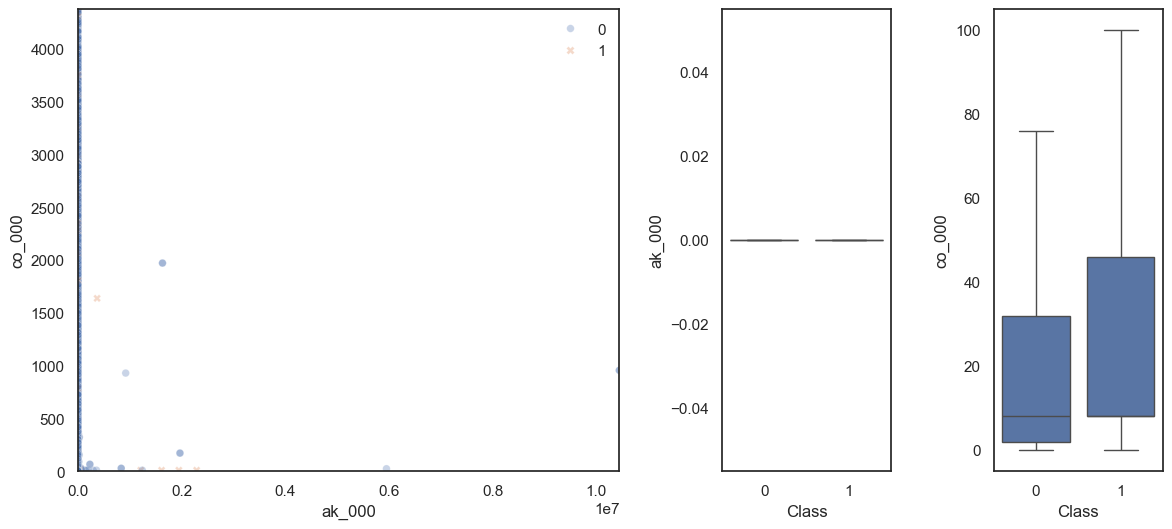

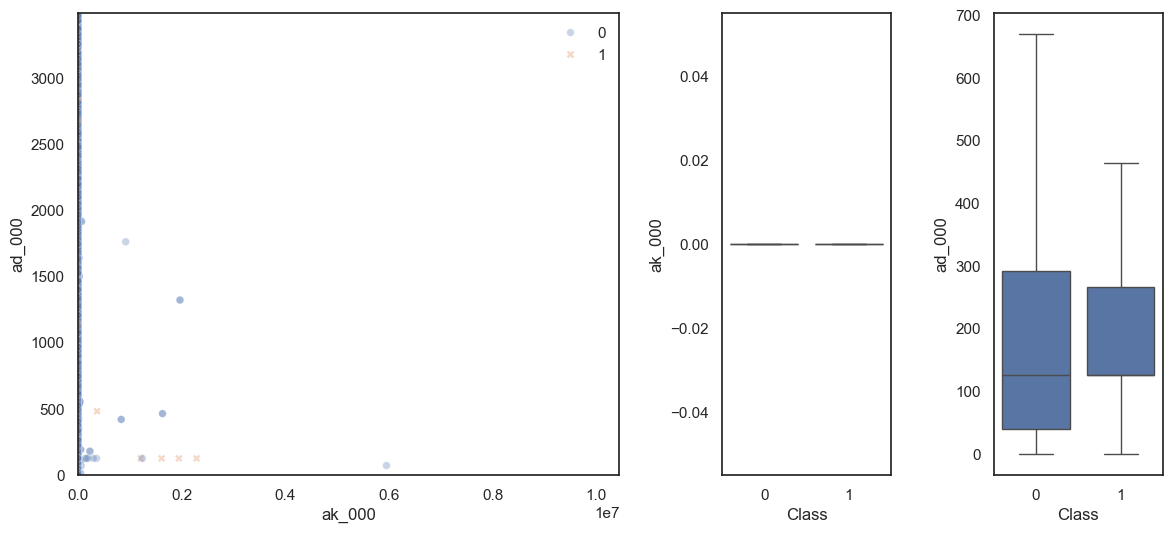

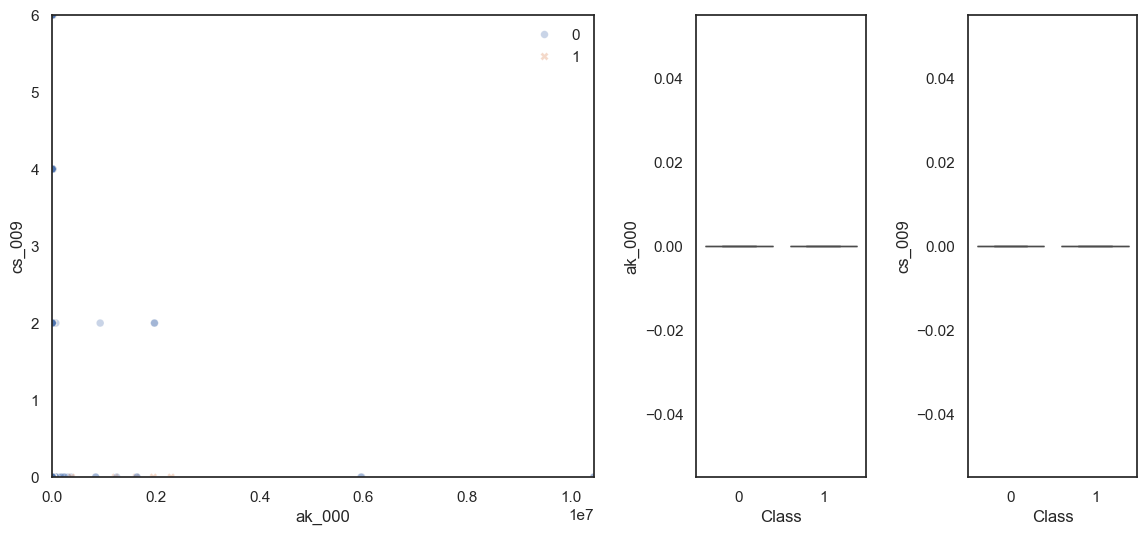

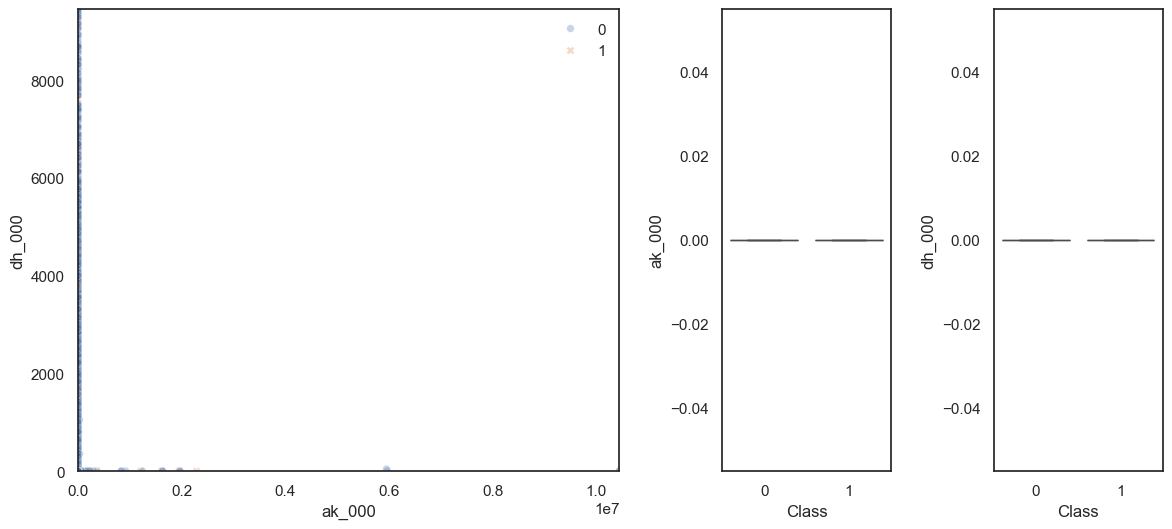

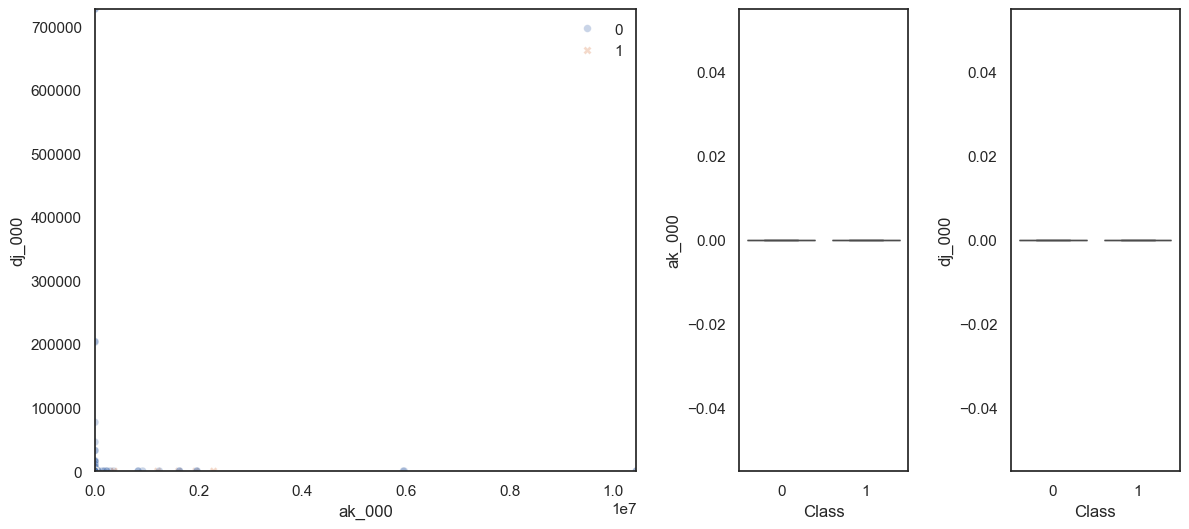

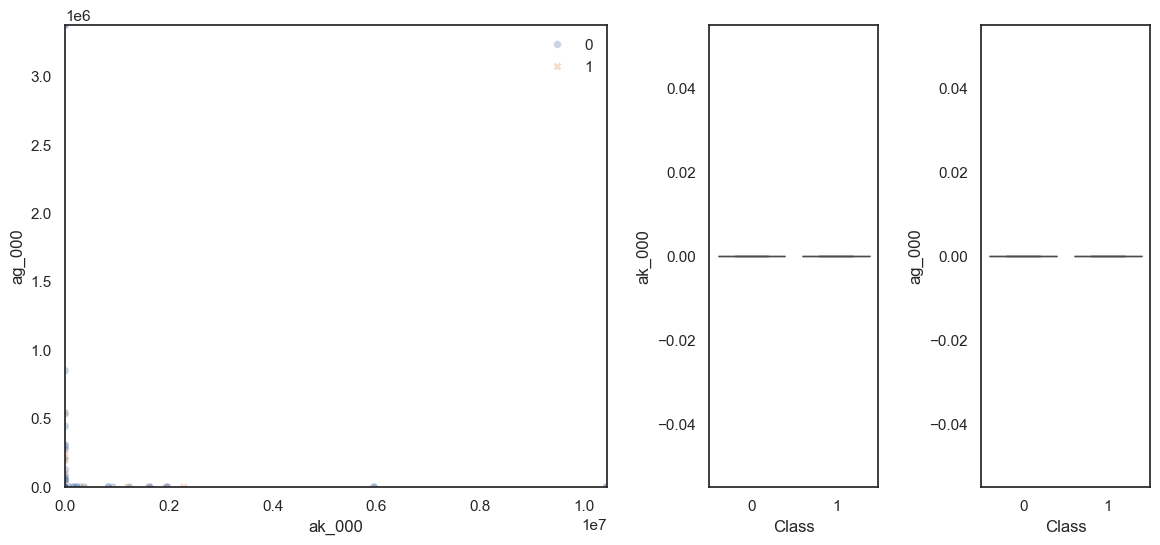

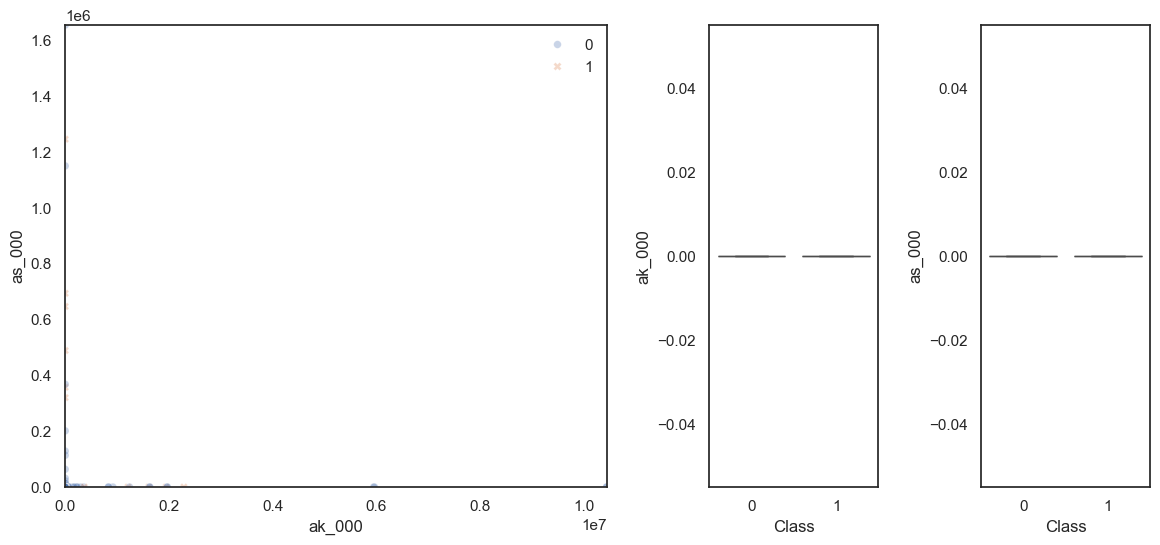

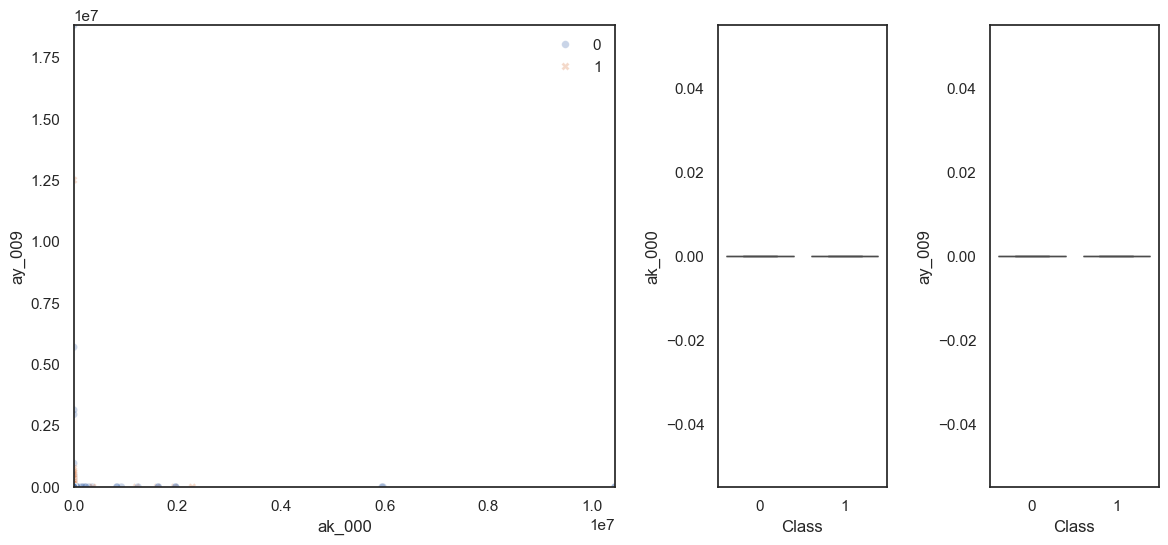

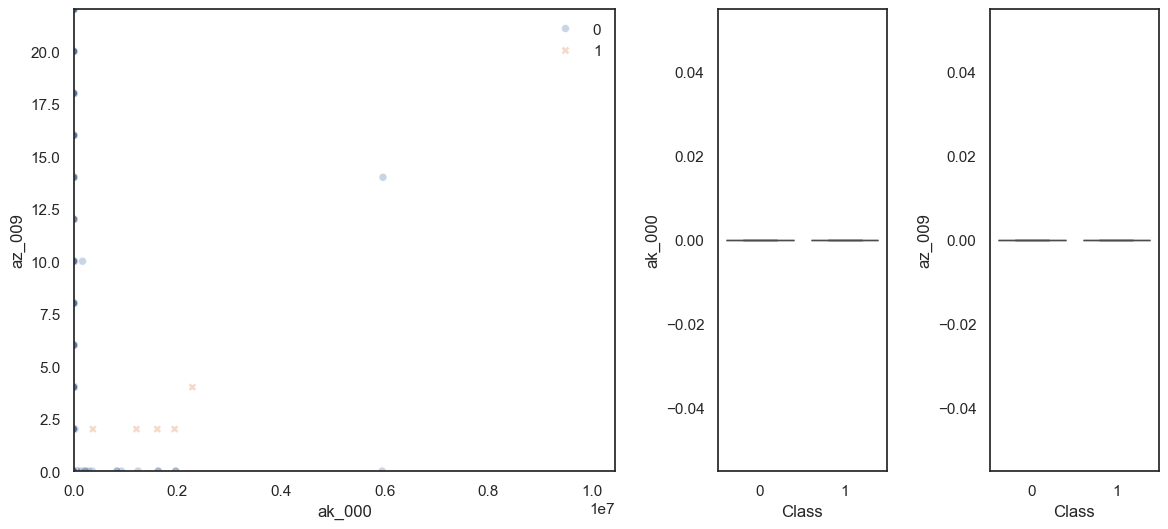

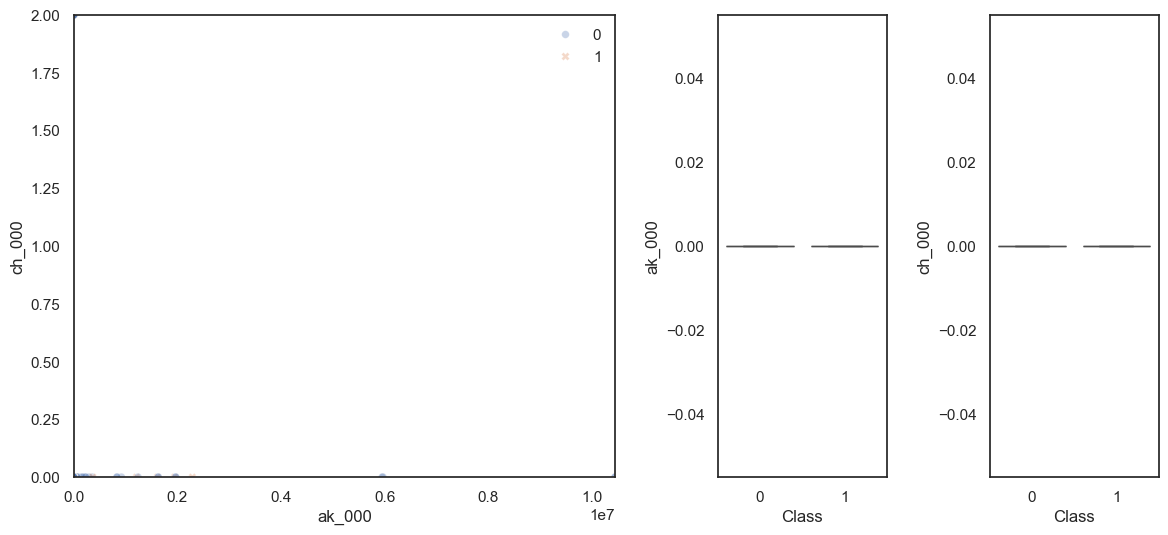

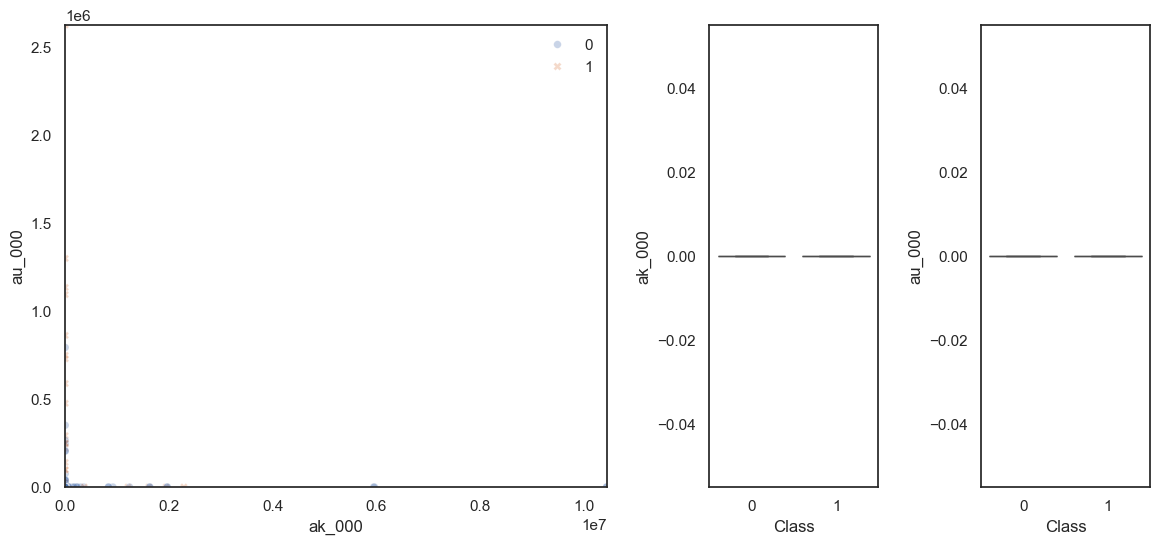

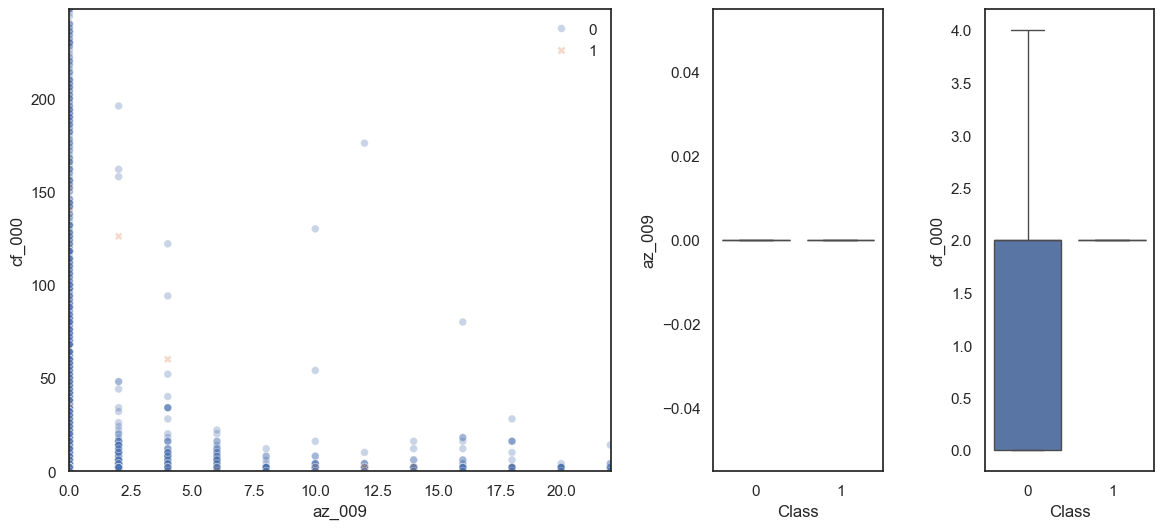

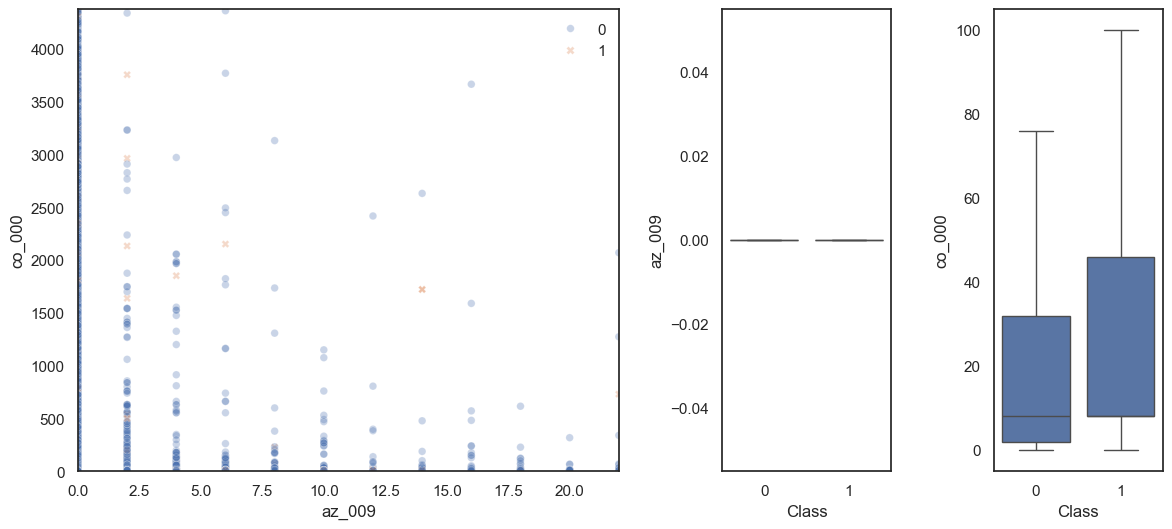

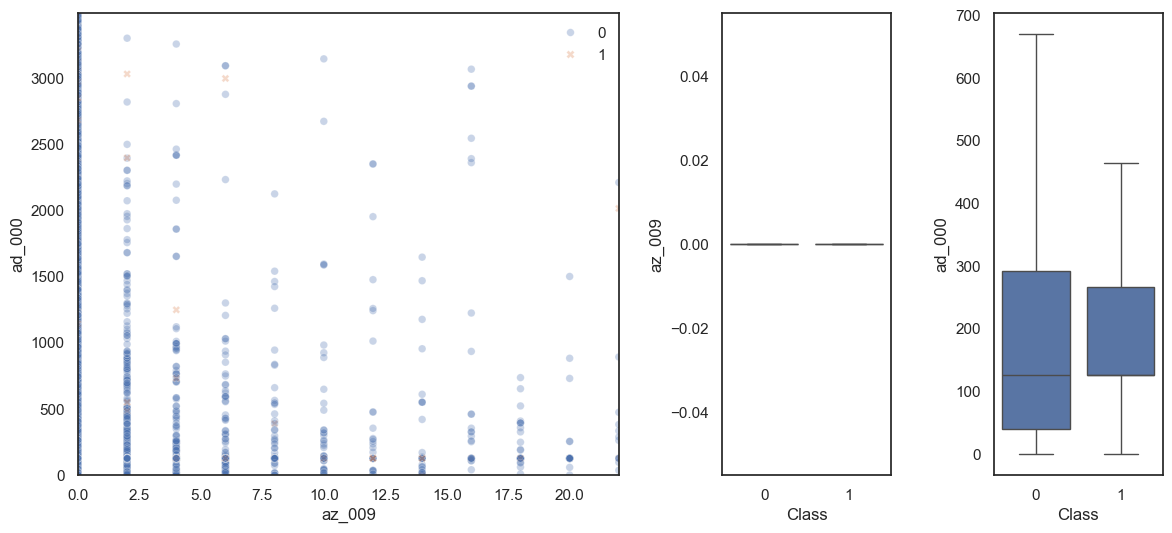

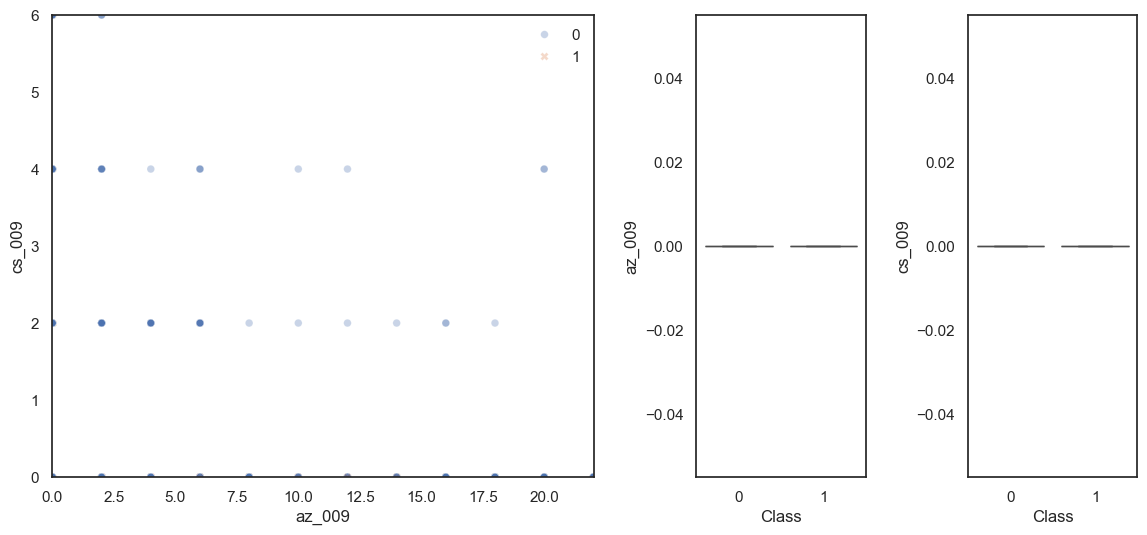

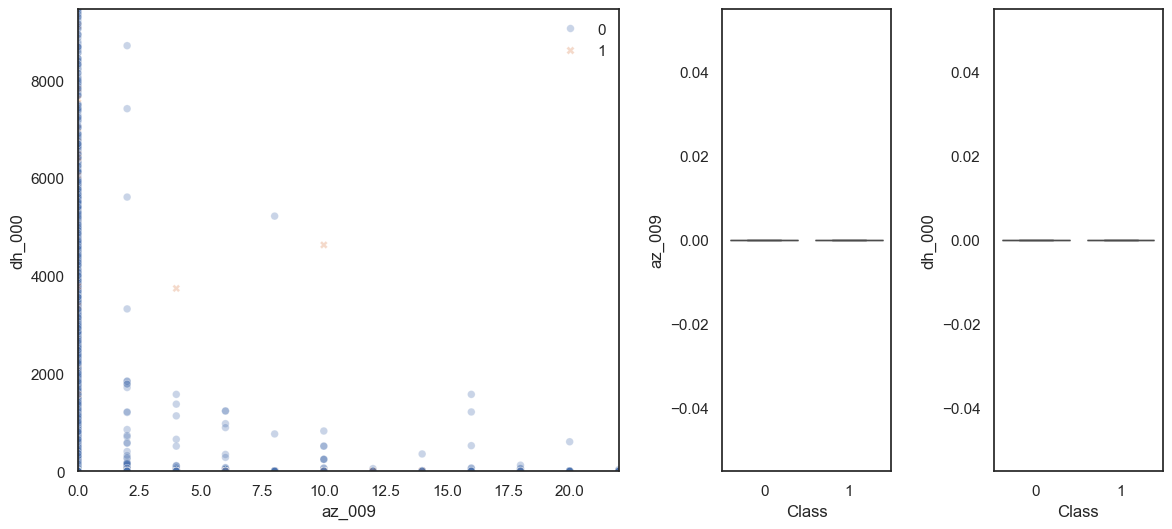

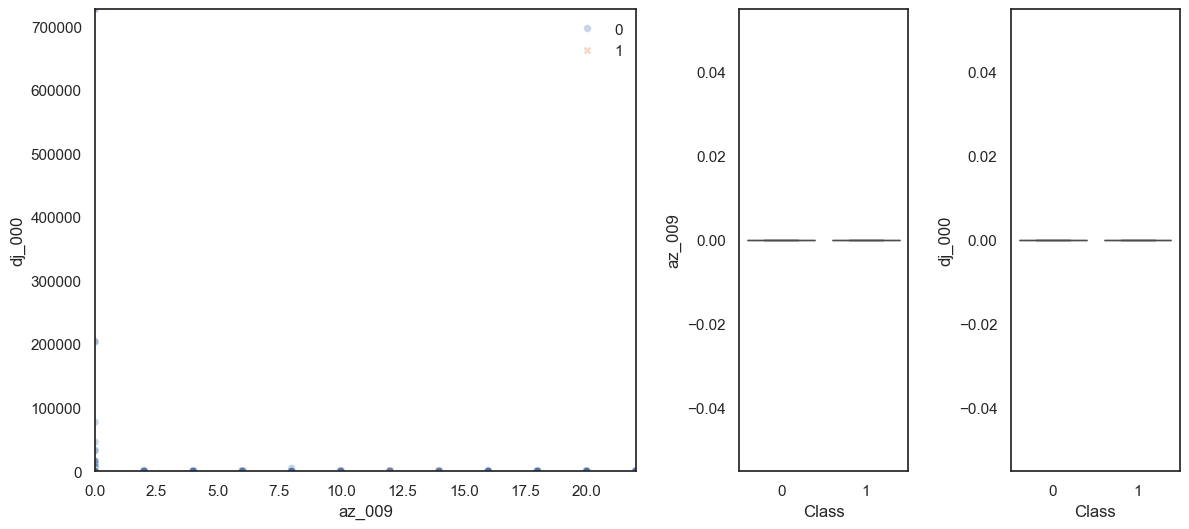

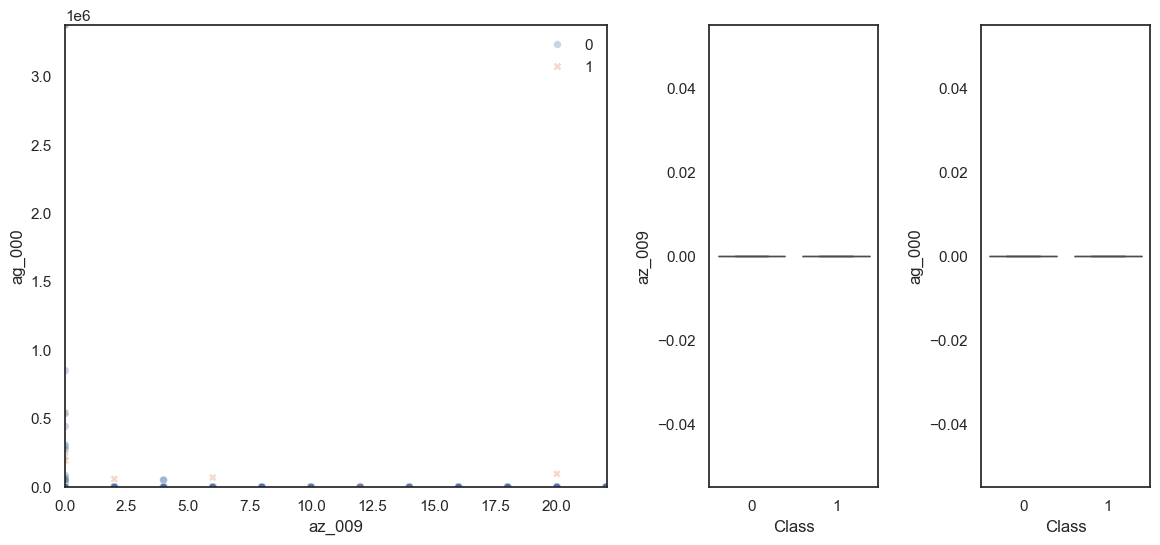

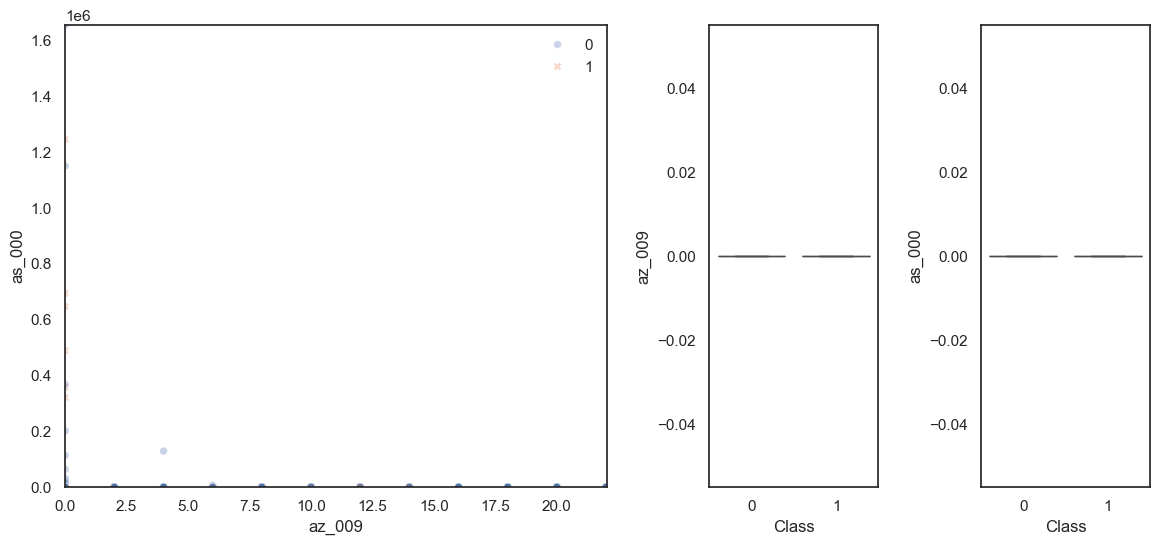

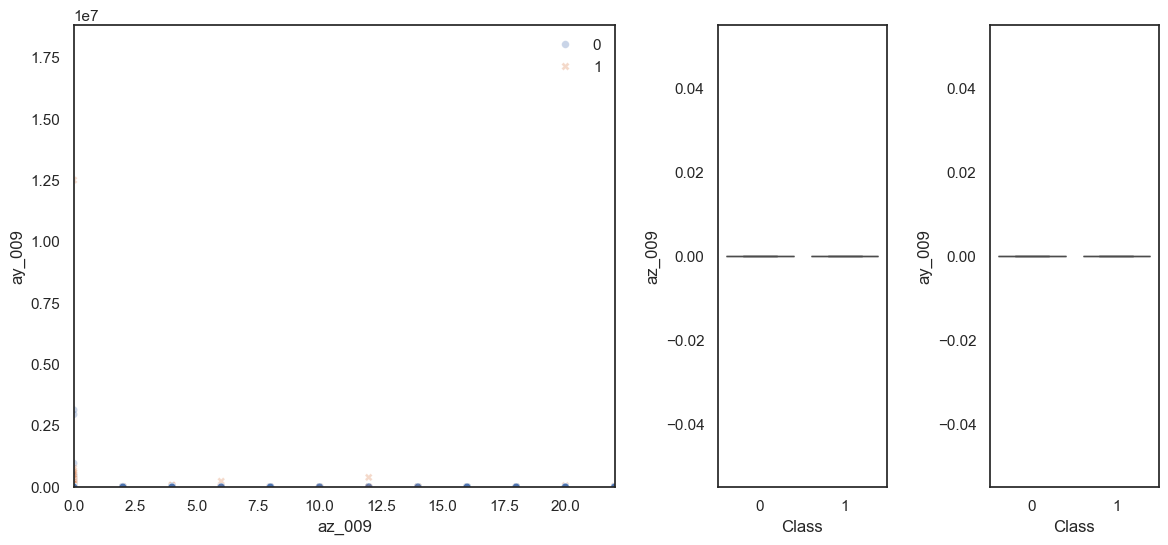

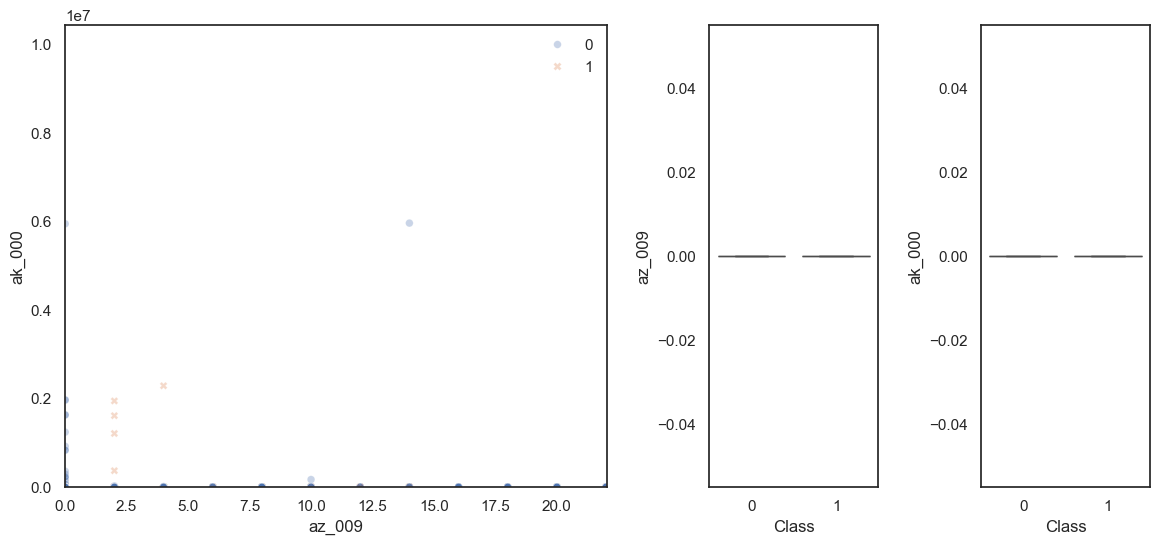

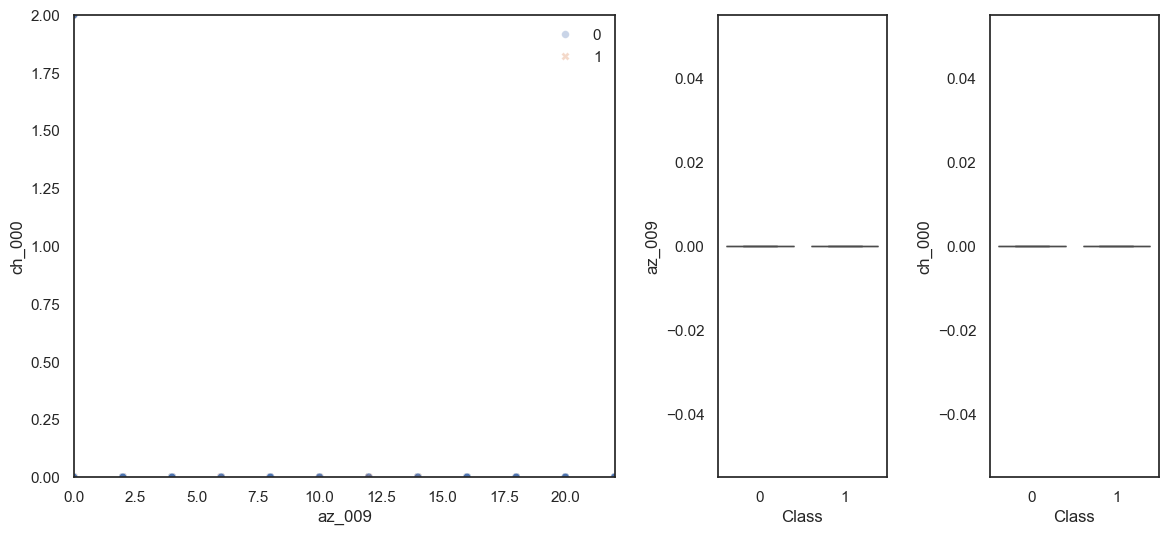

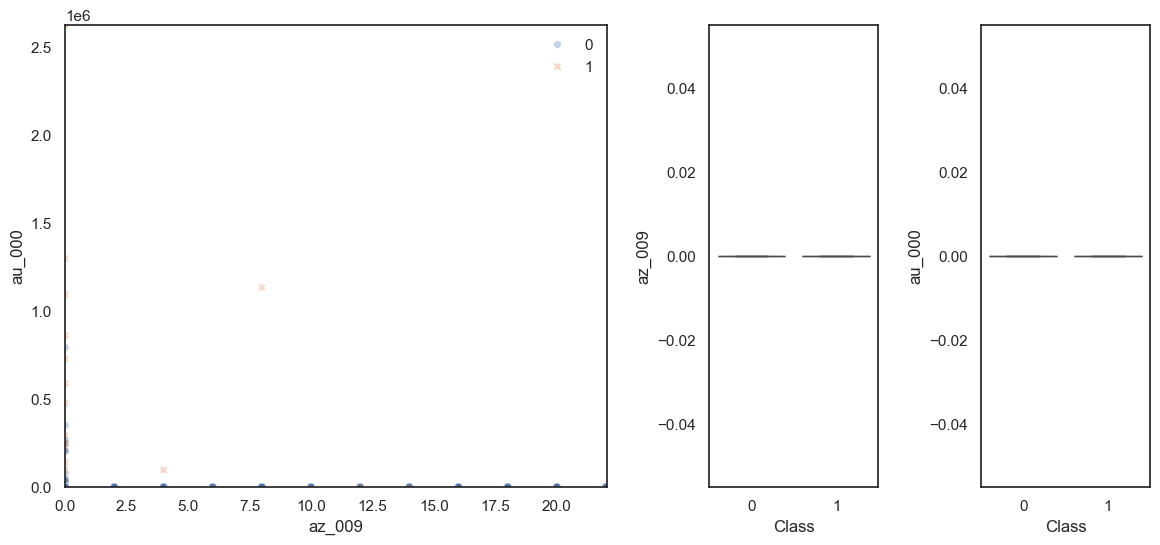

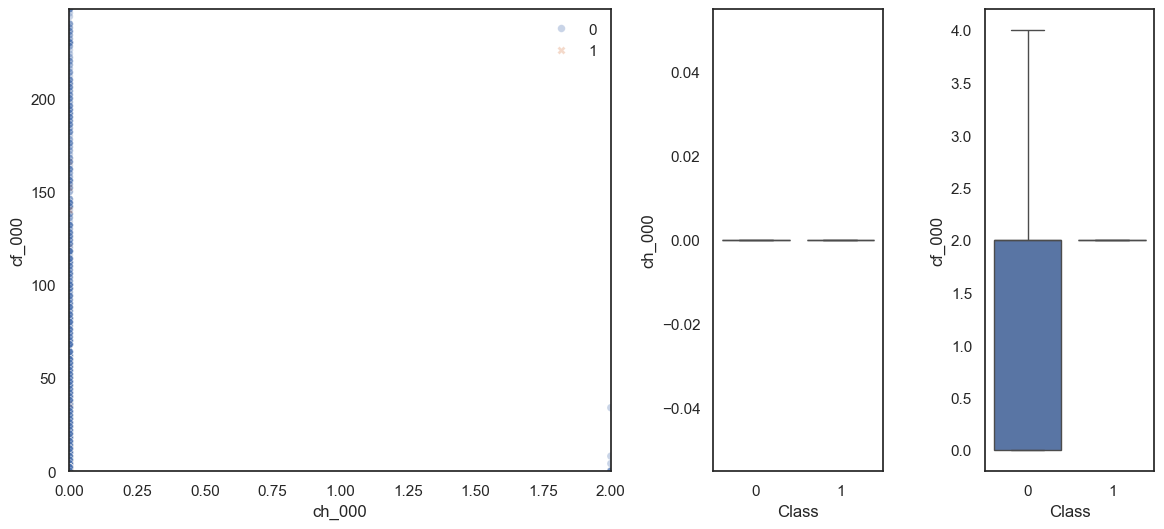

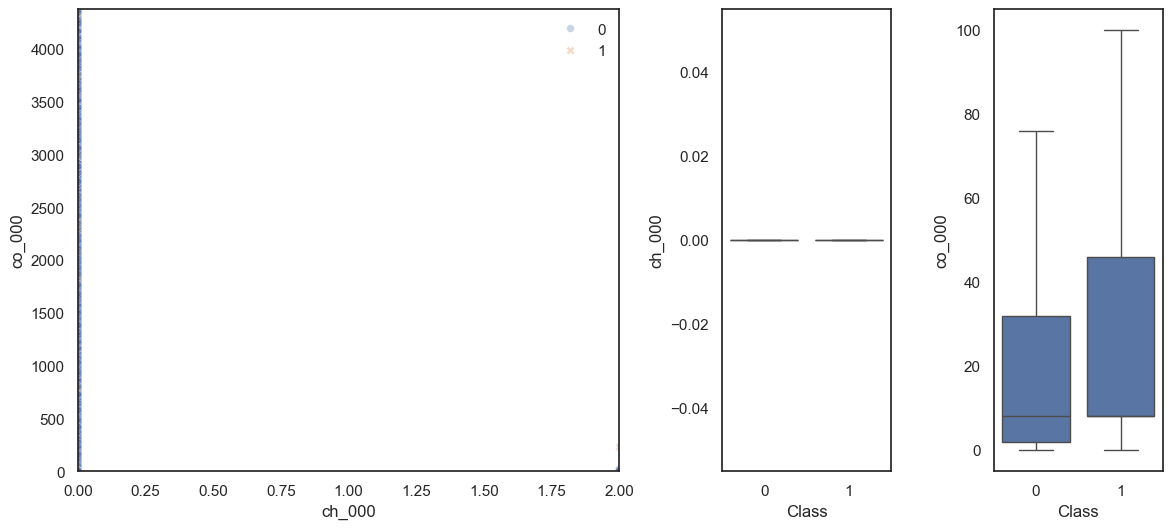

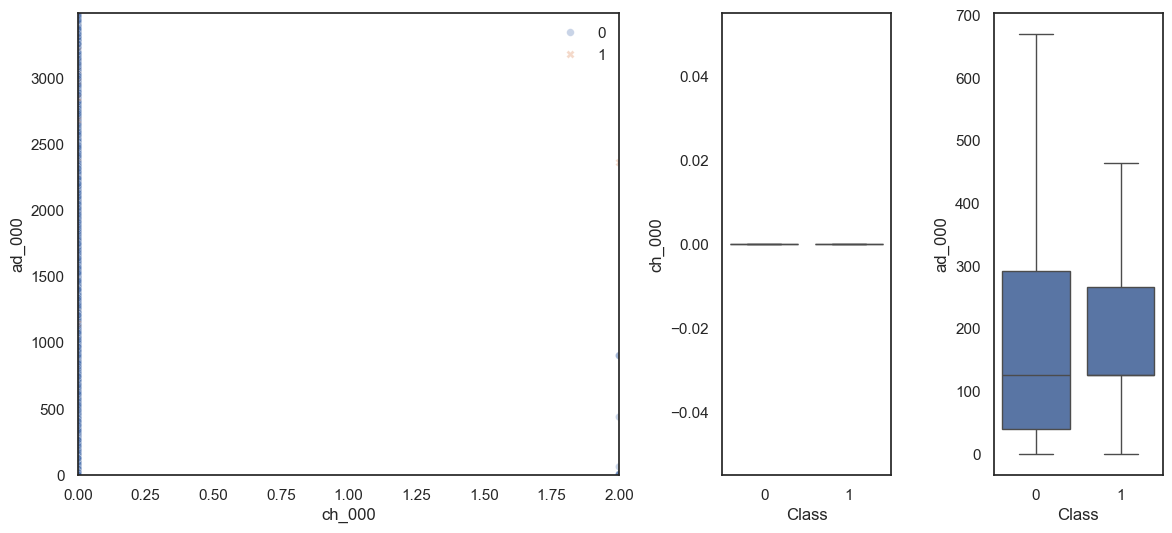

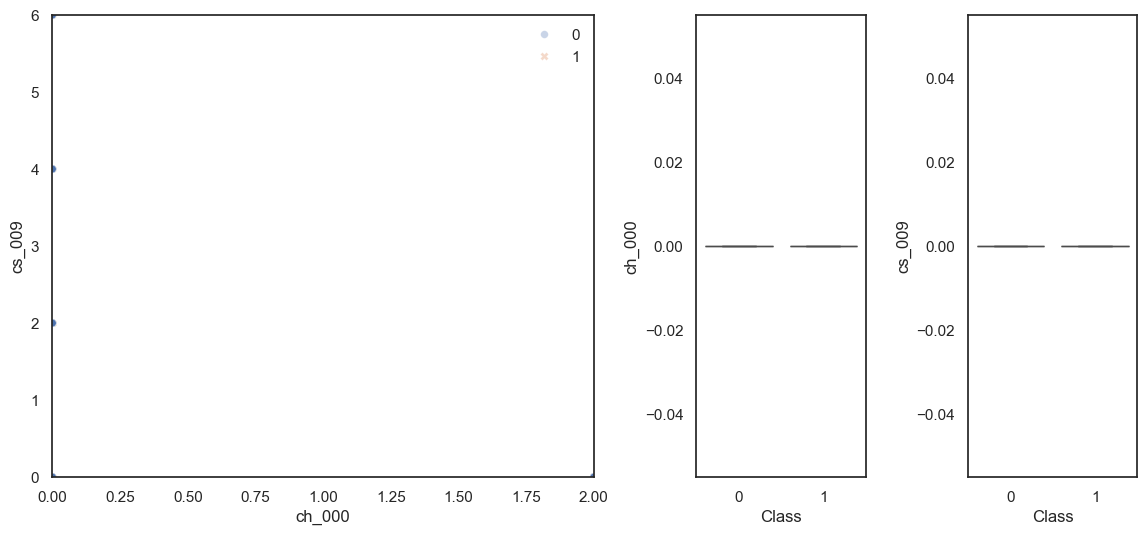

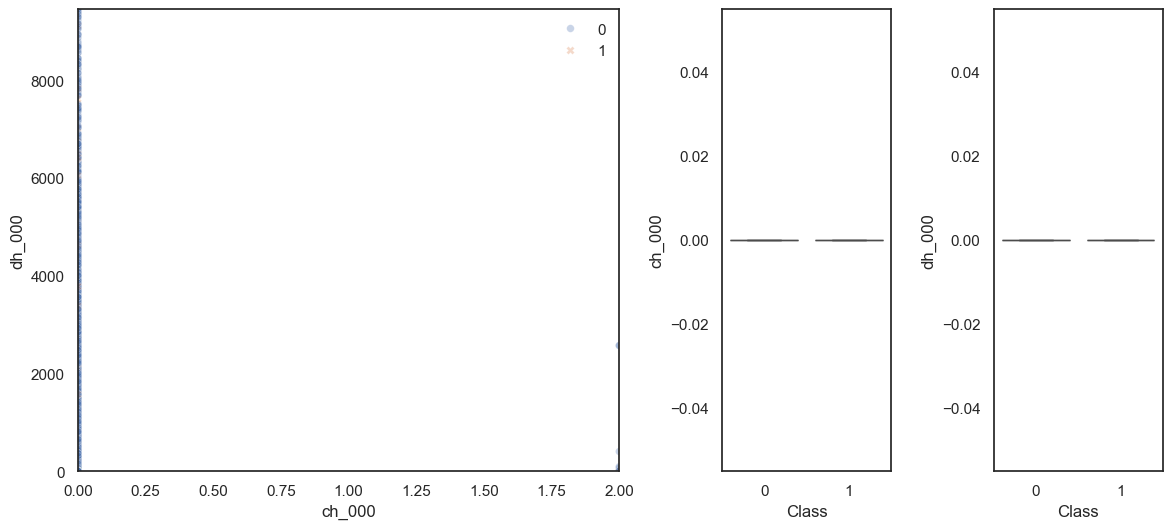

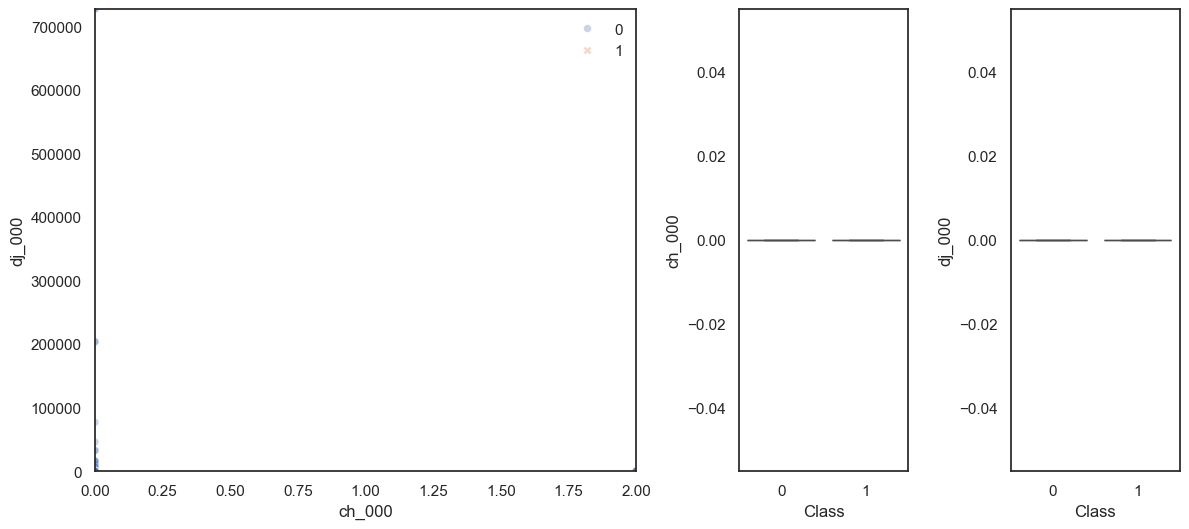

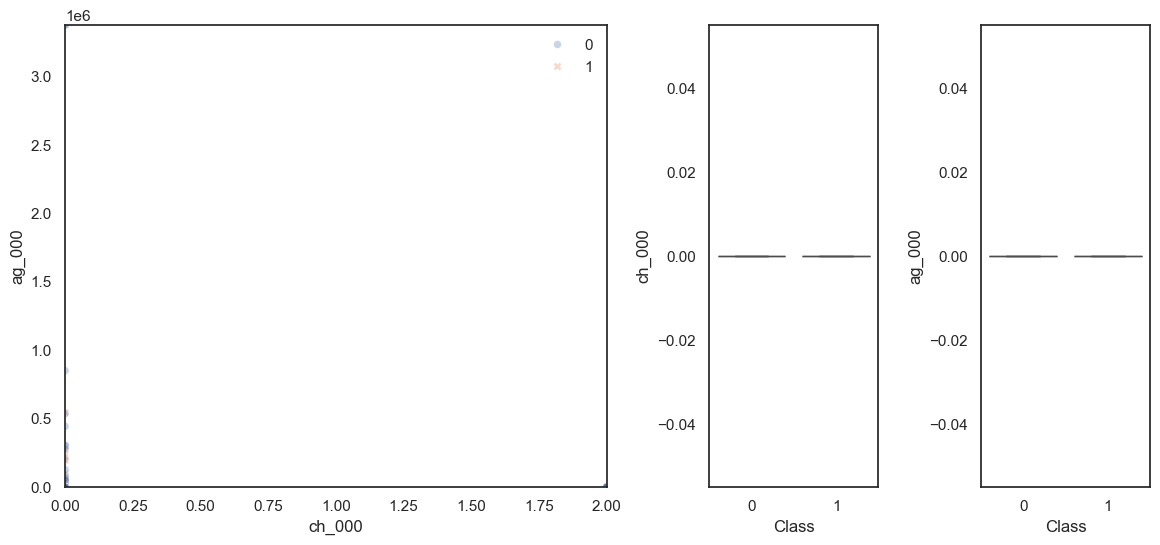

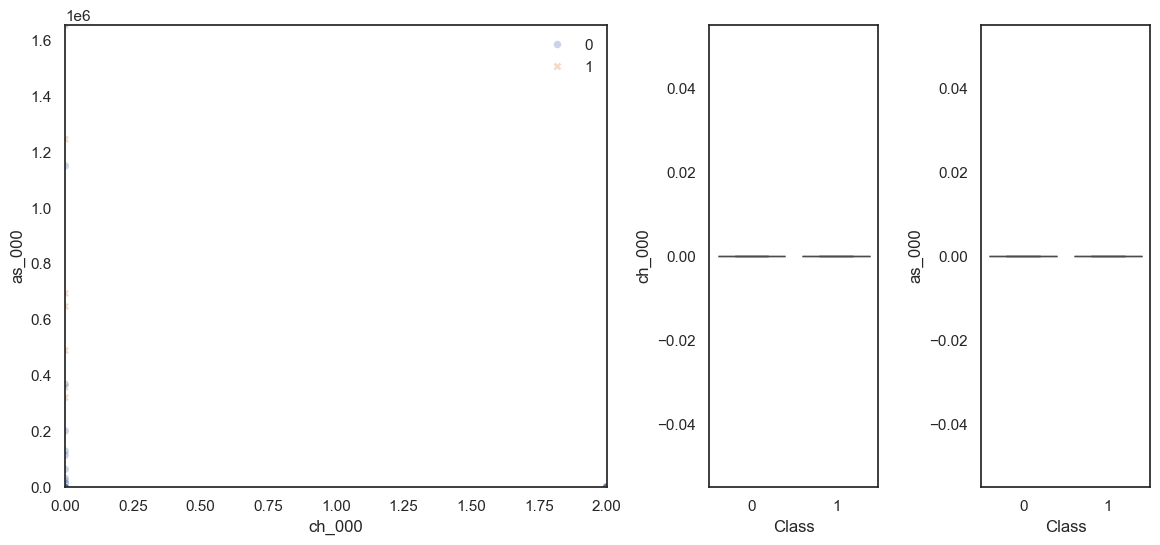

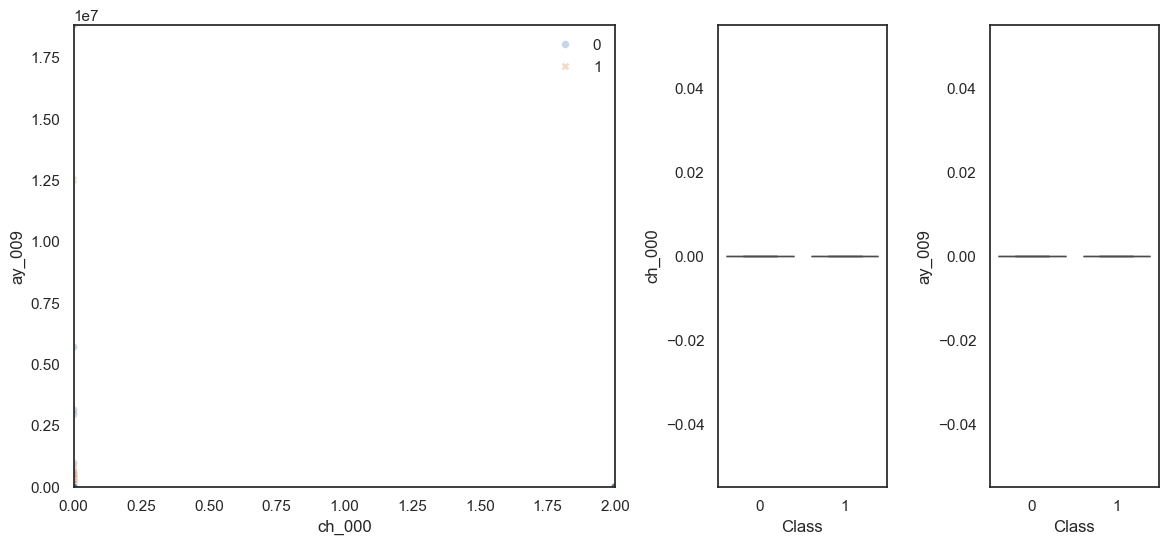

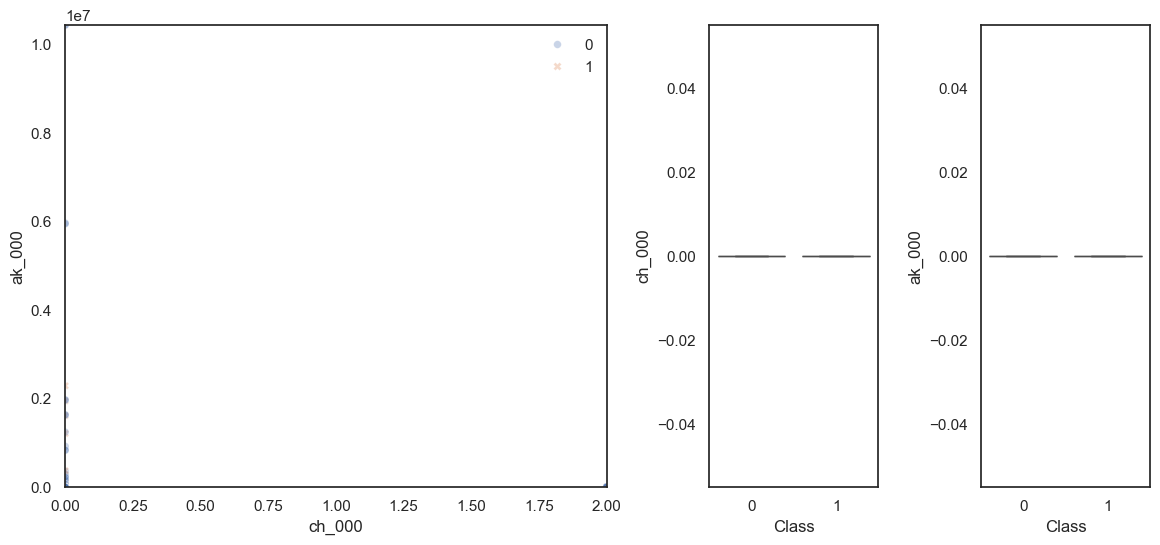

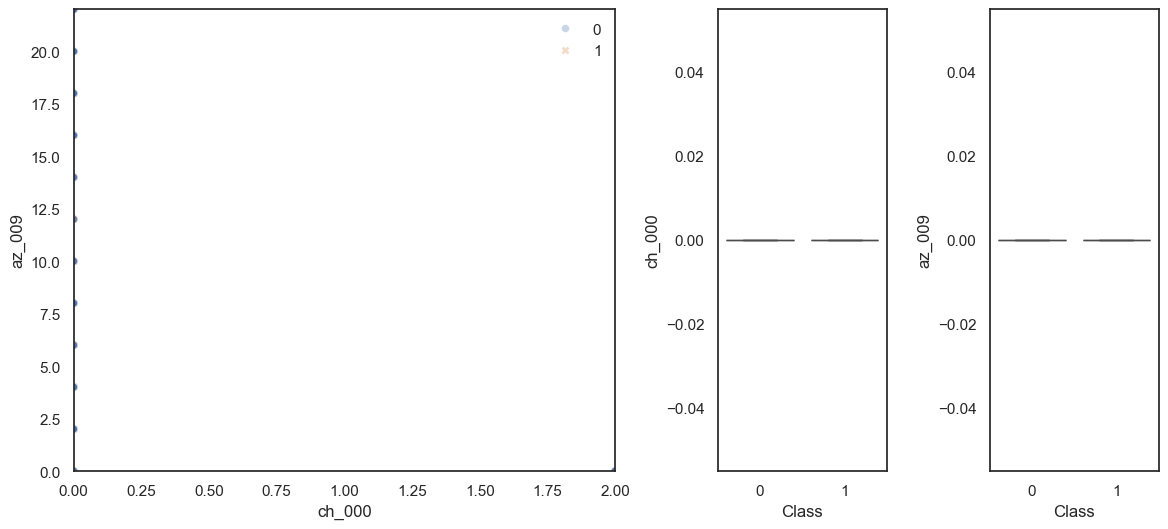

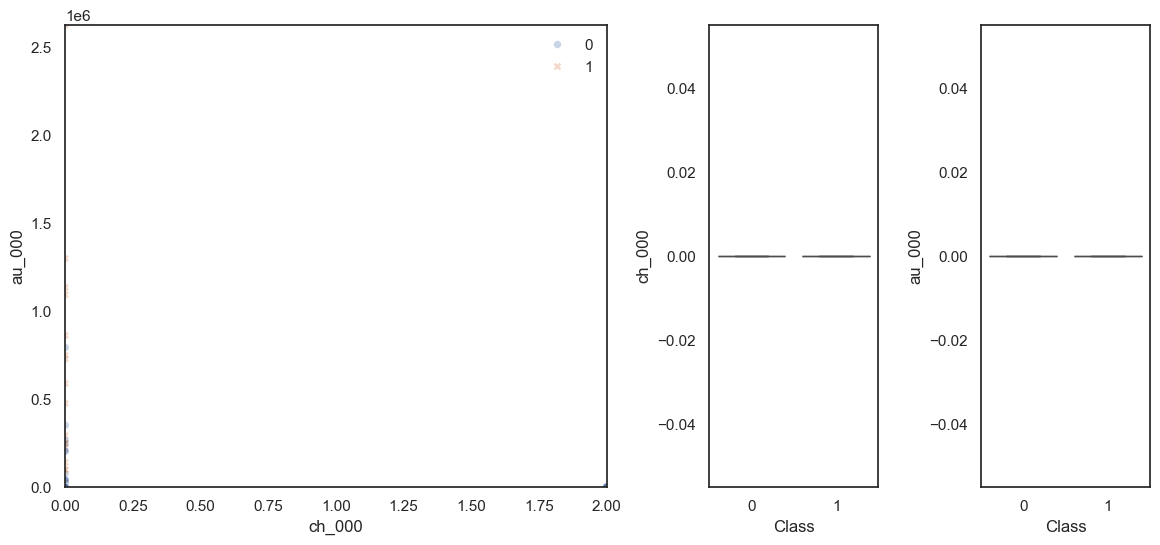

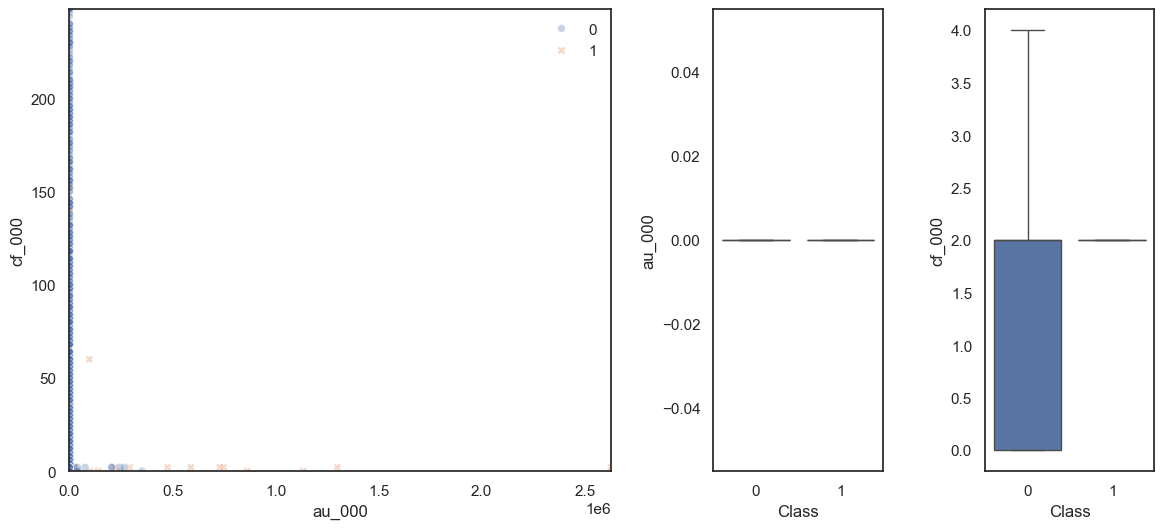

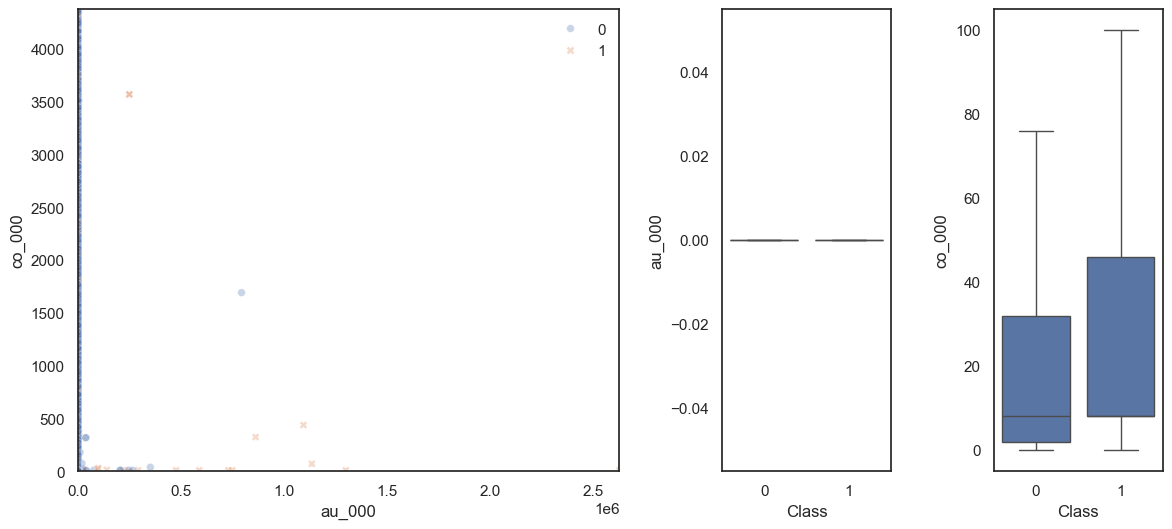

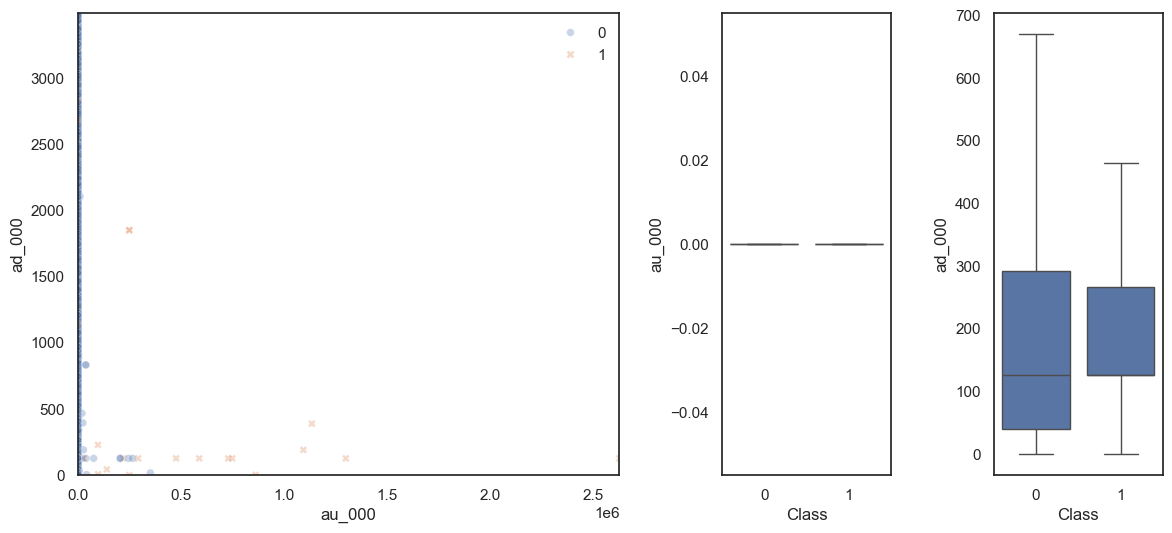

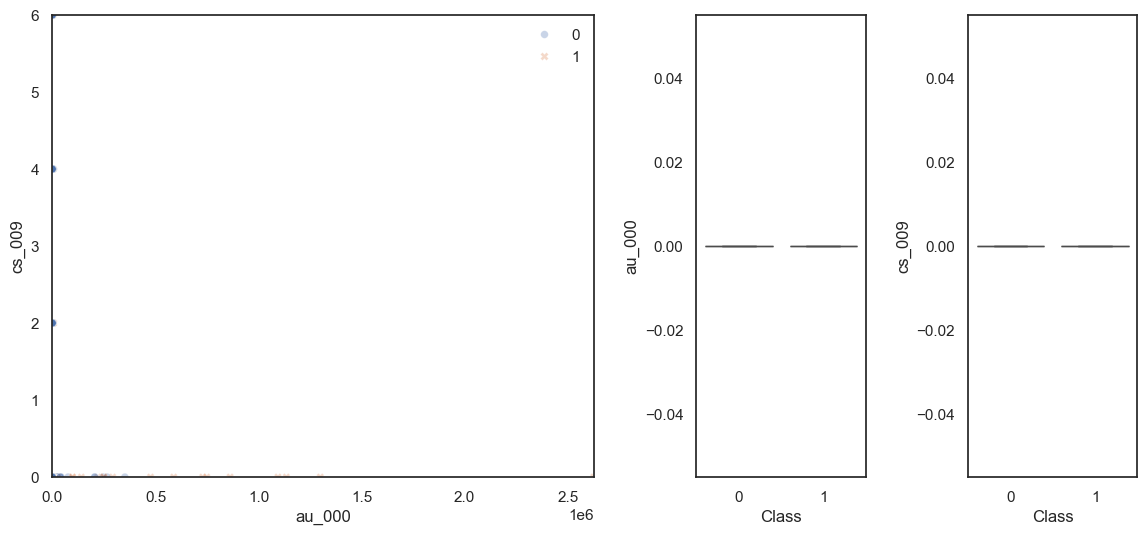

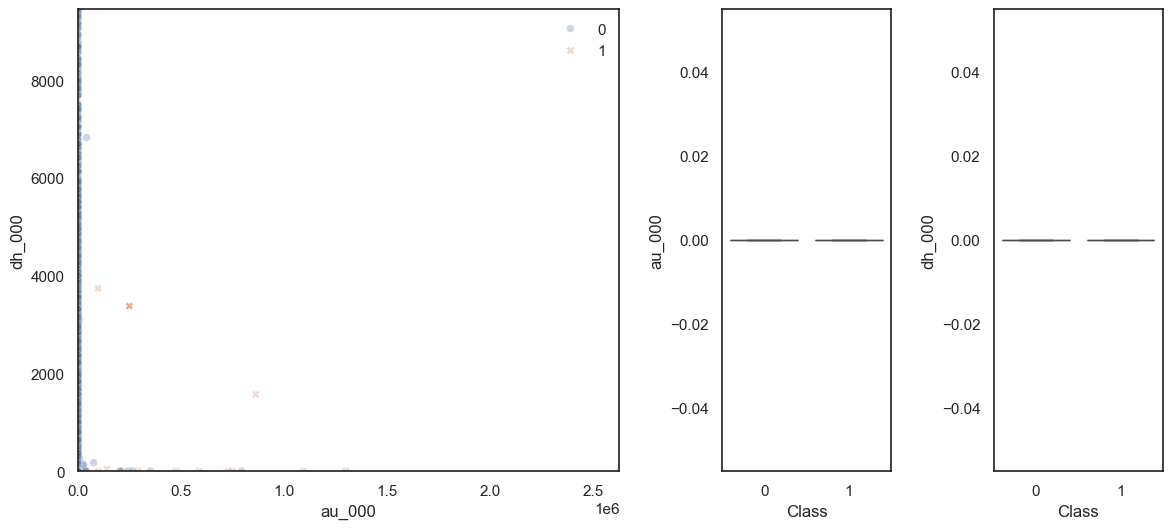

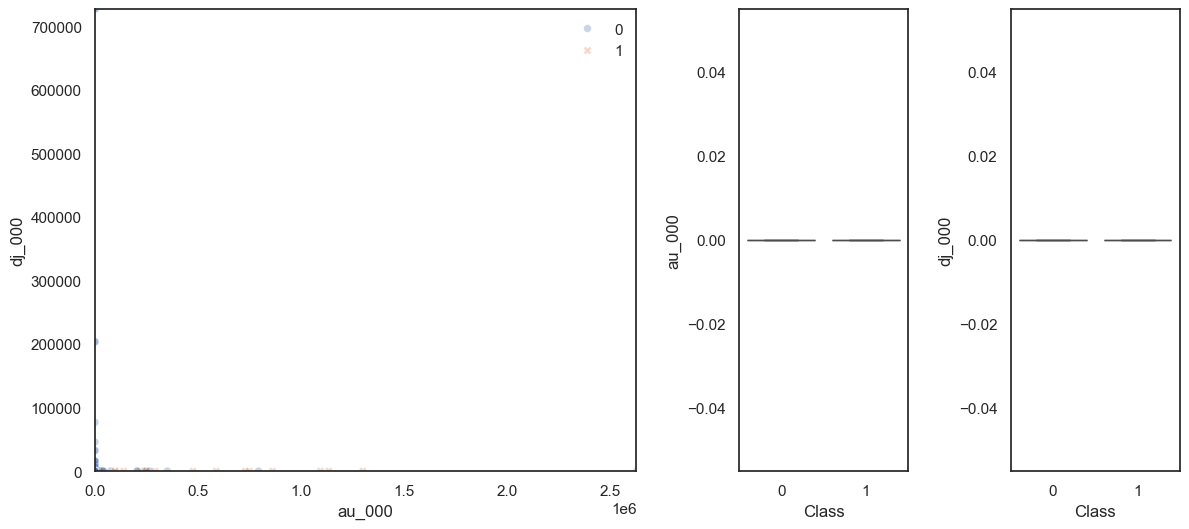

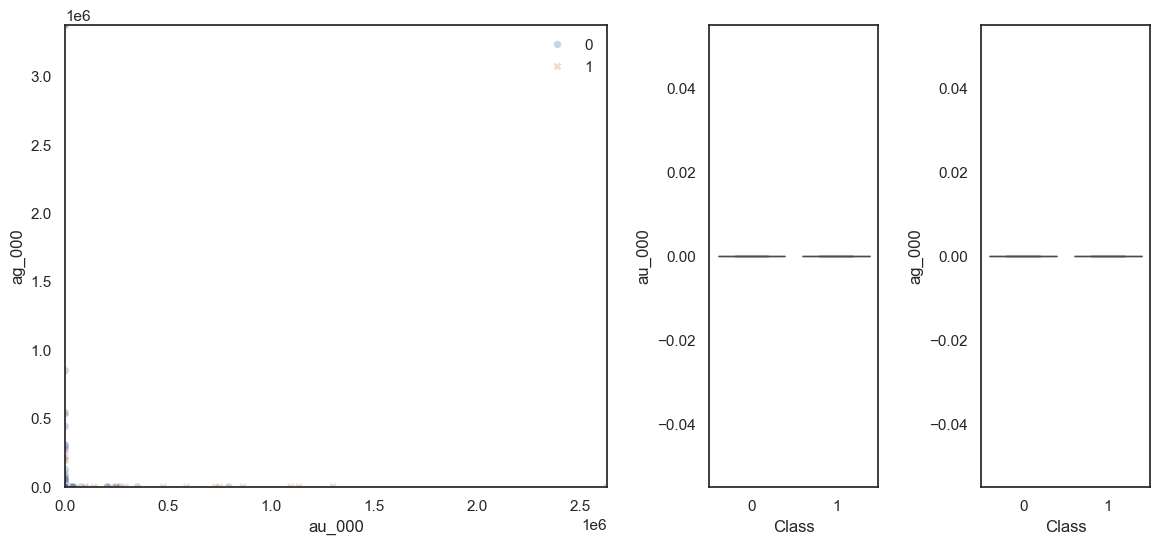

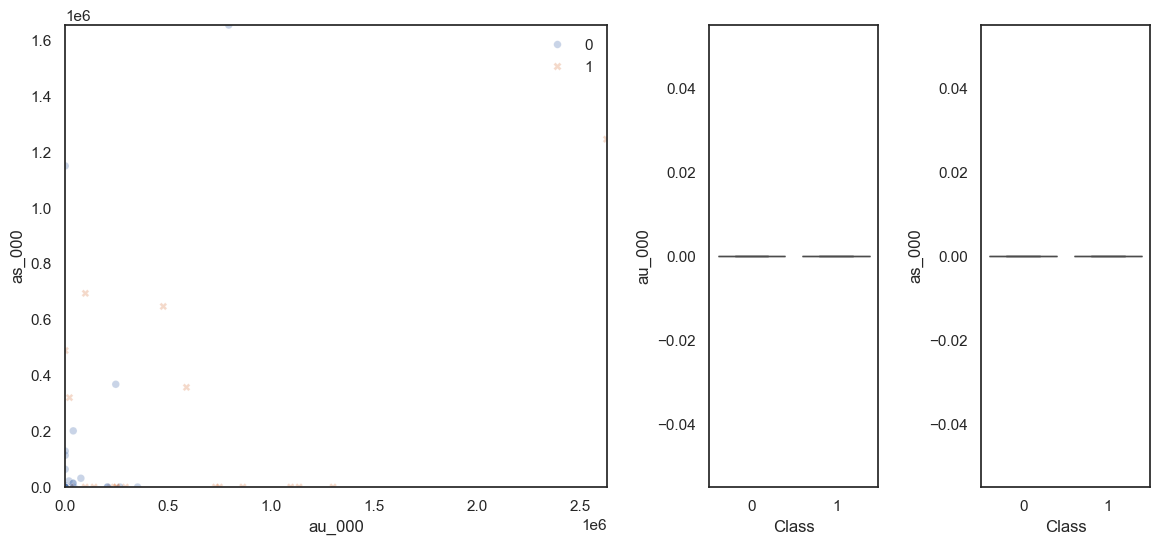

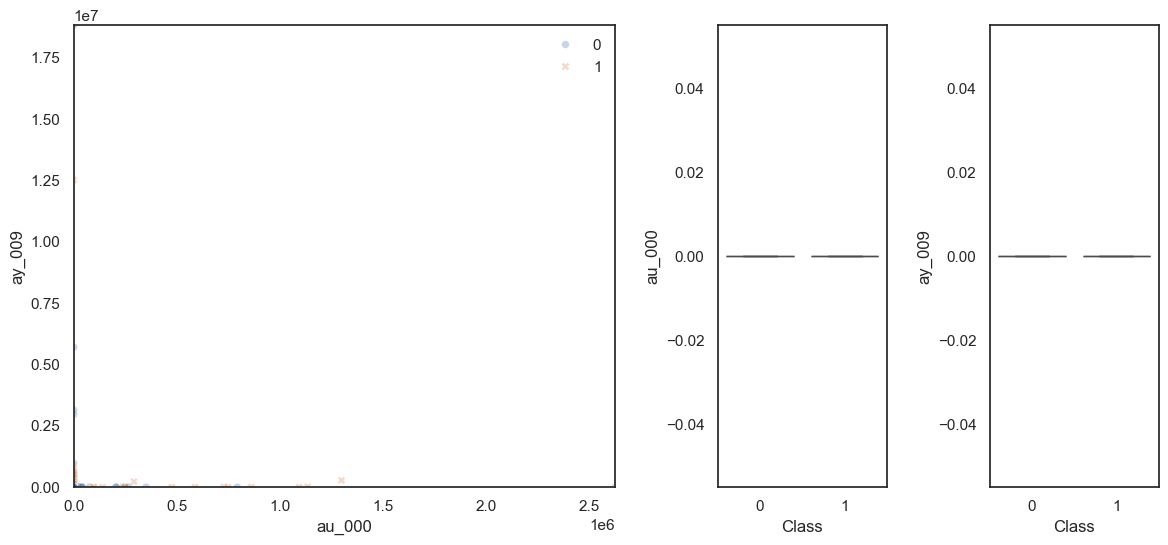

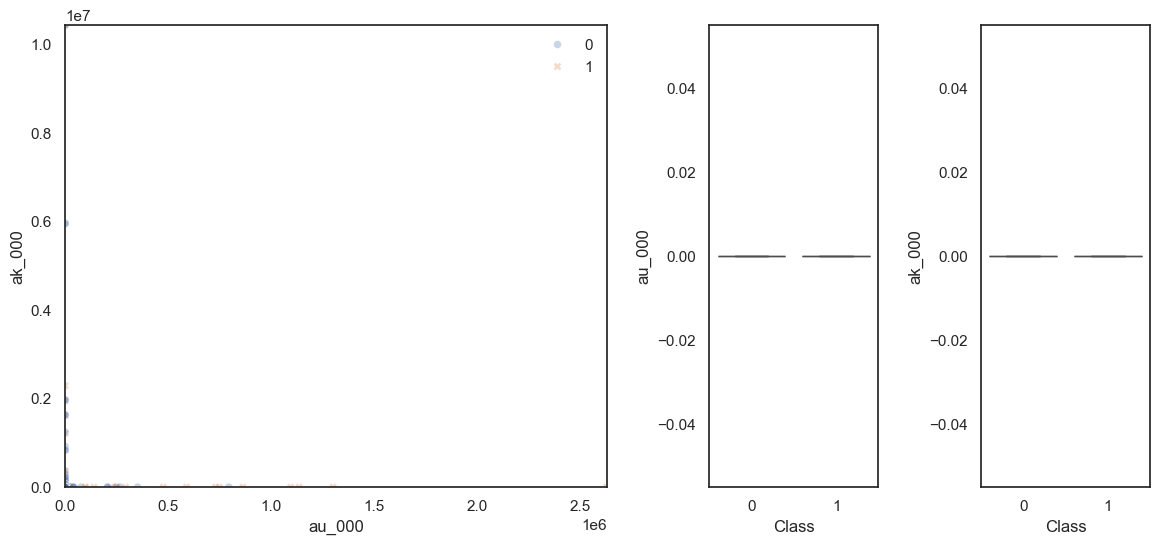

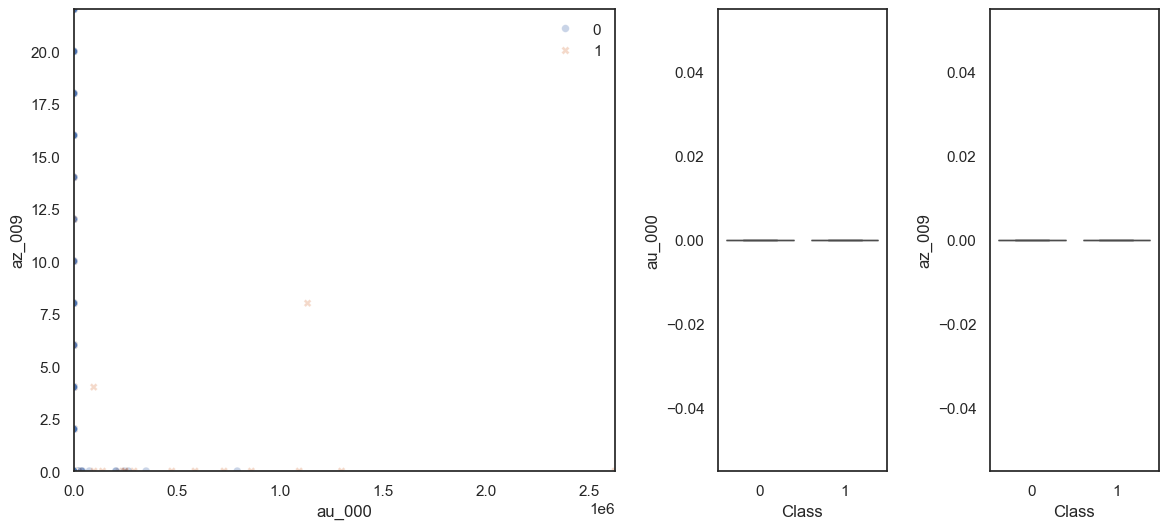

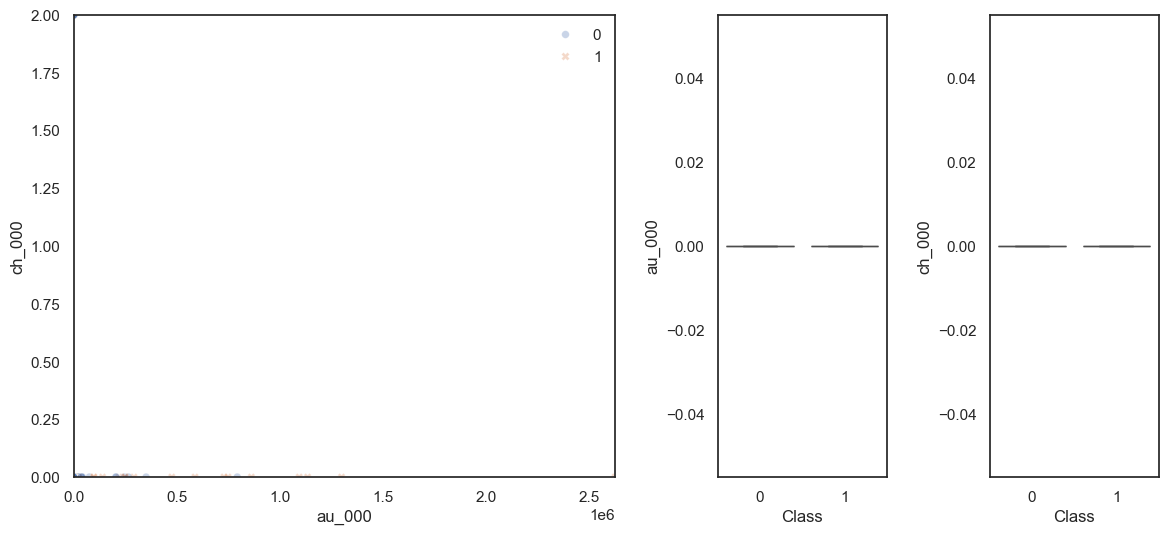

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

top_features = cv_df.head(13)['feature'].values

plot_df = X_train_original.copy()
plot_df['class'] = y_train.values
plot_df['class'] = plot_df['class'].map({'neg': 0, 'pos': 1})

for feat1 in top_features:
    for feat2 in top_features:
        if feat1 == feat2:
            continue

        sns.set_theme(style="white")
        fig = plt.figure(figsize=(14, 6))
        gs = fig.add_gridspec(1, 3, width_ratios=[3.2, 1, 1], wspace=0.35)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])

        # Scatter plot
        sns.scatterplot(
            data=plot_df,
            x=feat1,
            y=feat2,
            hue='class',
            style='class',
            alpha=0.3, # transparent
            s=30,
            ax=ax1
        )

        
        # The scale must be rescale or the plot is hard to observe
        x_low, x_high = np.percentile(plot_df[feat1], [1, 99])
        y_low, y_high = np.percentile(plot_df[feat2], [1, 99])

        if x_low == x_high:
            x_low, x_high = plot_df[feat1].min(), plot_df[feat1].max()
        if y_low == y_high:
            y_low, y_high = plot_df[feat2].min(), plot_df[feat2].max()

        ax1.set_xlim(x_low, x_high)
        ax1.set_ylim(y_low, y_high)

        ax1.set_xlabel(feat1)
        ax1.set_ylabel(feat2)
        ax1.legend(title="", frameon=False, loc="best")

        # Boxplot feat1
        sns.boxplot(
            data=plot_df,
            x='class',
            y=feat1,
            showfliers=False,
            ax=ax2
        )
        ax2.set_xlabel("Class")
        ax2.set_ylabel(feat1)

        # Boxplot feat2
        sns.boxplot(
            data=plot_df,
            x='class',
            y=feat2,
            showfliers=False,
            ax=ax3
        )
        ax3.set_xlabel("Class")
        ax3.set_ylabel(feat2)

        plt.show()

We can not see the conclusion because the outliers are required to be processed

#### (v) Is this data set imbalanced?

In [43]:
y_train.value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

In [44]:
# Yes, the negative data is way more than positive data

### (c) Train a random forest

Train Confusion Matrix:
 [[59000     0]
 [    0  1000]]
Test Confusion Matrix:
 [[15610    15]
 [   99   276]]
Train Error: 0.0
Test Error: 0.007125000000000048
OOB Error: 0.0060833333333333295
Train AUC: 1.0
Test AUC: 0.9930082133333334


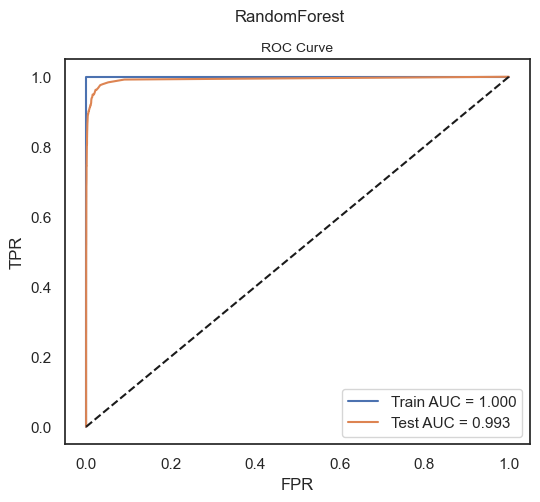

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc

# The dataset will use the dataset without missing indicator
X_train_final = X_train_original
X_test_final = X_test_imputed.iloc[:, :170]

y_train_final = y_train.map({'neg': 0, 'pos': 1})
y_test_final = y_test.map({'neg': 0, 'pos': 1})

model = "RandomForest"

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=404,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_final)

y_train_pred = rf.predict(X_train_final)
y_test_pred = rf.predict(X_test_final)
y_train_prob = rf.predict_proba(X_train_final)[:, 1]
y_test_prob = rf.predict_proba(X_test_final)[:, 1]

#confusion matrix

cm_train = confusion_matrix(y_train_final, y_train_pred)
cm_test = confusion_matrix(y_test_final, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)


train_error = 1 - accuracy_score(y_train_final, y_train_pred)
test_error = 1 - accuracy_score(y_test_final, y_test_pred)

print("Train Error:", train_error)
print("Test Error:", test_error)

oob_error = 1 - rf.oob_score_
print("OOB Error:", oob_error)

fpr_train, tpr_train, _ = roc_curve(y_train_final, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test_final, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.suptitle(model, fontsize=12)   
plt.title("ROC Curve", fontsize=10) 
plt.legend()
plt.savefig(f"../images/{model}_ROC_Curve.png")
plt.show()

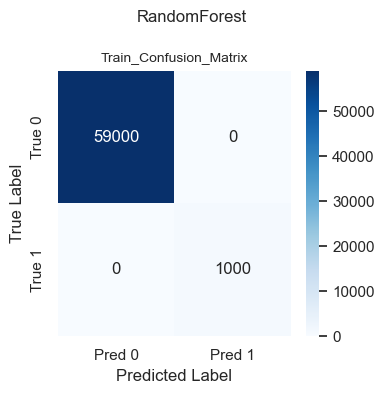

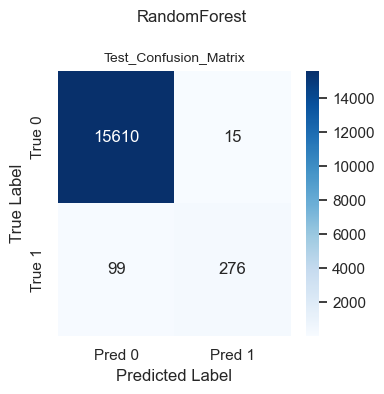

In [69]:
# plot_confusion_matrix
def plot_confusion_matrix(model , cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    plt.suptitle(model, fontsize=12)   
    plt.title(title, fontsize=10)        
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f"../images/{model}_{title}.png")
    plt.show()

plot_confusion_matrix(model,cm_train, "Train_Confusion_Matrix")
plot_confusion_matrix(model,cm_test, "Test_Confusion_Matrix")

The OOB error is very close to the test error, which indicates that the model has good generalization ability.

Although the training error is zero, this does not necessarily imply severe overfitting. Random forests are capable of fitting the training data very well due to their ensemble of deep decision trees.

In addition, the class imbalance may make the classification task easier, as the majority class dominates the dataset. However, the low test error and high AUC suggest that the model is not simply exploiting the imbalance, but is able to generalize well to unseen data.

### (d) Research class imbalance in random forest

Train Confusion Matrix:
 [[59000     0]
 [    1   999]]
Test Confusion Matrix:
 [[15611    14]
 [  160   215]]
Train Error: 1.666666666666483e-05
Test Error: 0.010874999999999968
OOB Error: 0.0060833333333333295
Train AUC: 1.0
Test AUC: 0.991943936


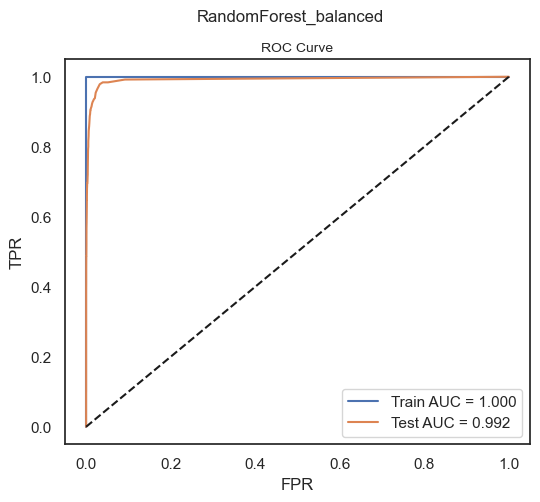

In [70]:
model ="RandomForest_balanced"
rf_bal = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    class_weight='balanced',  # balanced the class
    random_state=42,
    n_jobs=-1
)

rf_bal.fit(X_train_final, y_train_final)

y_train_pred = rf_bal.predict(X_train_final)
y_test_pred = rf_bal.predict(X_test_final)
y_train_prob = rf_bal.predict_proba(X_train_final)[:, 1]
y_test_prob = rf_bal.predict_proba(X_test_final)[:, 1]

#confusion matrix

cm_train = confusion_matrix(y_train_final, y_train_pred)
cm_test = confusion_matrix(y_test_final, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)


train_error = 1 - accuracy_score(y_train_final, y_train_pred)
test_error = 1 - accuracy_score(y_test_final, y_test_pred)

print("Train Error:", train_error)
print("Test Error:", test_error)

oob_error = 1 - rf.oob_score_
print("OOB Error:", oob_error)

fpr_train, tpr_train, _ = roc_curve(y_train_final, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test_final, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.suptitle(model, fontsize=12)   
plt.title("ROC Curve", fontsize=10) 
plt.legend()
plt.savefig(f"../images/{model}_ROC_Curve.png")
plt.show()

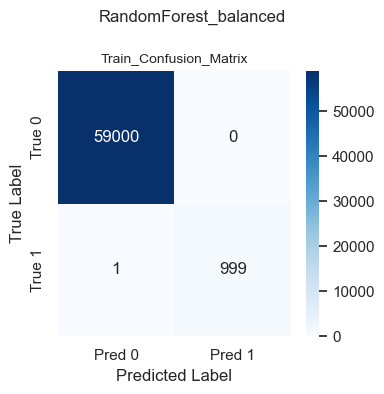

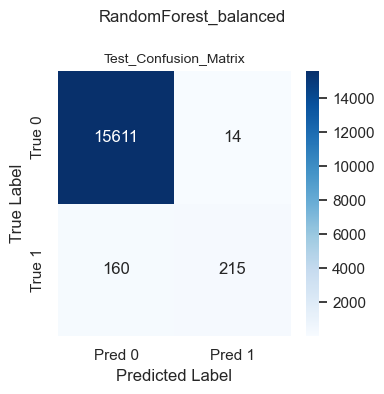

In [71]:
plot_confusion_matrix(model,cm_train, "Train_Confusion_Matrix")
plot_confusion_matrix(model,cm_test, "Test_Confusion_Matrix")

The performance between these two models does not have signficant difference.

### Research class imbalance in random forest with SMOTE

Train Confusion Matrix:
 [[59000     0]
 [    0  1000]]
Test Confusion Matrix:
 [[15541    84]
 [   61   314]]
Train Error: 0.0
Test Error: 0.009062499999999973
Train AUC: 1.0
Test AUC: 0.9933592746666667


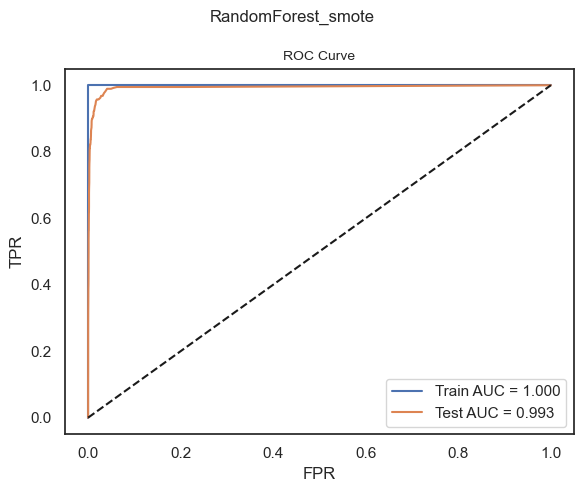

In [72]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

model = "RandomForest_smote"

pipeline = Pipeline([
    ('smote', SMOTE(random_state=404)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=404,
        n_jobs=-1
    ))
])

pipeline.fit(X_train_final, y_train_final)

y_train_pred = pipeline.predict(X_train_final)
y_test_pred = pipeline.predict(X_test_final)

y_train_prob = pipeline.predict_proba(X_train_final)[:, 1]
y_test_prob = pipeline.predict_proba(X_test_final)[:, 1]

# confusion matrix
cm_train = confusion_matrix(y_train_final, y_train_pred)
cm_test = confusion_matrix(y_test_final, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)

train_error = 1 - accuracy_score(y_train_final, y_train_pred)
test_error = 1 - accuracy_score(y_test_final, y_test_pred)

print("Train Error:", train_error)
print("Test Error:", test_error)

fpr_train, tpr_train, _ = roc_curve(y_train_final, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test_final, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.suptitle(model, fontsize=12)
plt.title("ROC Curve", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(f"../images/{model}_ROC_Curve.png")
plt.show()

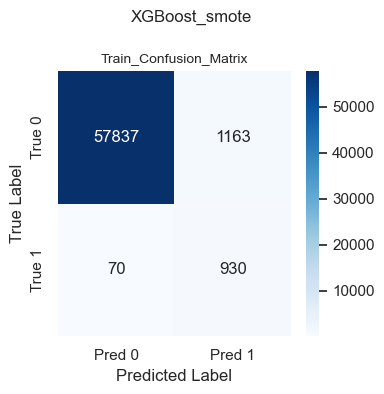

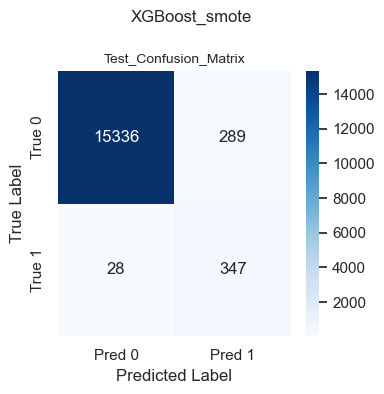

In [78]:
plot_confusion_matrix(model,cm_train, "Train_Confusion_Matrix")
plot_confusion_matrix(model,cm_test, "Test_Confusion_Matrix")

### (e) XGBoost and Model Trees

In [80]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold

# For L-2 regulation log-scale grid search 0.1 no restriction <> 100 strong restriction: reference XGboost tuning guide
# param_grid = {
#     'reg_lambda': [0.1, 1, 10, 100]
# }

# Find L1 regularization alpha (= reg_alpha)

model = "XGBoost"
param_grid = {
    "reg_alpha": np.logspace(-2, 2, 10)  # run faster
}

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,  # learn fast may overfit. 1.0 is moderate para
    subsample=0.8,
    colsample_bytree=0.8, # every tree use 80% feature
    eval_metric='logloss',
    random_state=404
)

#CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=404)
grid = GridSearchCV(
    xgb,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_final, y_train_final)

print("Best alpha:", grid.best_params_)

Best alpha: {'reg_alpha': np.float64(0.21544346900318834)}


Train Confusion Matrix:
 [[58939    61]
 [  213   787]]
Test Confusion Matrix:
 [[15597    28]
 [  111   264]]
Train Error: 0.004566666666666719
Test Error: 0.00868749999999996
Train AUC: 0.9957291186440678
Test AUC: 0.9958882986666667


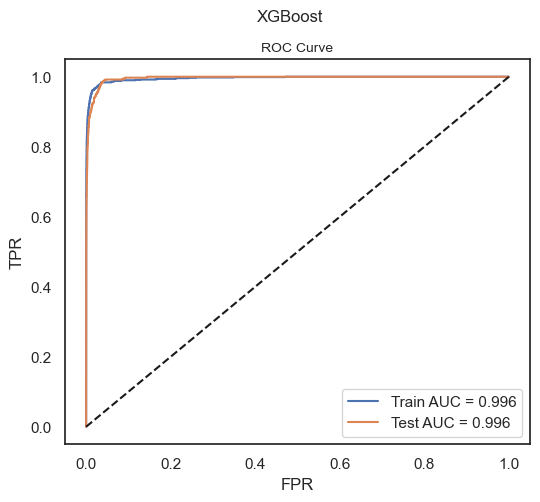

In [81]:
best_xgb = grid.best_estimator_


best_xgb.fit(X_train_final, y_train_final)
y_train_pred = best_xgb.predict(X_train_final)
y_test_pred = best_xgb.predict(X_test_final)

y_train_prob = best_xgb.predict_proba(X_train_final)[:,1]
y_test_prob = best_xgb.predict_proba(X_test_final)[:,1]


#confusion matrix

cm_train = confusion_matrix(y_train_final, y_train_pred)
cm_test = confusion_matrix(y_test_final, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)


train_error = 1 - accuracy_score(y_train_final, y_train_pred)
test_error = 1 - accuracy_score(y_test_final, y_test_pred)

print("Train Error:", train_error)
print("Test Error:", test_error)

fpr_train, tpr_train, _ = roc_curve(y_train_final, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test_final, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.suptitle(model, fontsize=12)   
plt.title("ROC Curve", fontsize=10) 
plt.legend()
plt.savefig(f"../images/{model}_ROC_Curve.png")
plt.show()

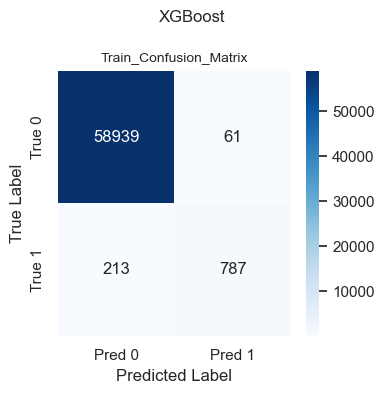

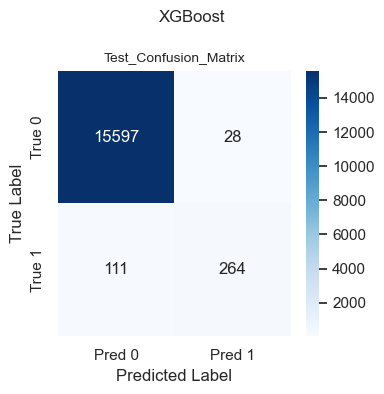

In [82]:
plot_confusion_matrix(model,cm_train, "Train_Confusion_Matrix")
plot_confusion_matrix(model,cm_test, "Test_Confusion_Matrix")

### (f) Use SMOTE to pre-process your data

Train Confusion Matrix:
 [[57837  1163]
 [   70   930]]
Test Confusion Matrix:
 [[15336   289]
 [   28   347]]
Train Error: 0.020549999999999957
Test Error: 0.01981250000000001
Train AUC: 0.9932728983050848
Test AUC: 0.9942946133333334


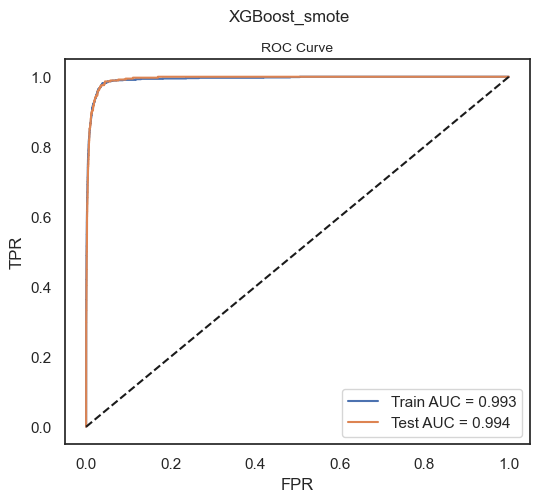

In [76]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

model="XGBoost_smote"
param_grid = {
    'xgb__reg_alpha': np.logspace(-2, 2, 10)
}

pipeline = Pipeline([
    ('smote', SMOTE(random_state=404)),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=404
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_final, y_train_final)

best_xgb = grid.best_estimator_


best_xgb.fit(X_train_final, y_train_final)
y_train_pred = best_xgb.predict(X_train_final)
y_test_pred = best_xgb.predict(X_test_final)

y_train_prob = best_xgb.predict_proba(X_train_final)[:,1]
y_test_prob = best_xgb.predict_proba(X_test_final)[:,1]


#confusion matrix

cm_train = confusion_matrix(y_train_final, y_train_pred)
cm_test = confusion_matrix(y_test_final, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)


train_error = 1 - accuracy_score(y_train_final, y_train_pred)
test_error = 1 - accuracy_score(y_test_final, y_test_pred)

print("Train Error:", train_error)
print("Test Error:", test_error)

fpr_train, tpr_train, _ = roc_curve(y_train_final, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test_final, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.suptitle(model, fontsize=12)   
plt.title("ROC Curve", fontsize=10) 
plt.legend()
plt.savefig(f"../images/{model}_ROC_Curve.png")
plt.show()

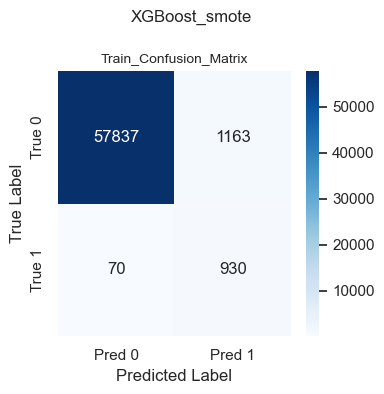

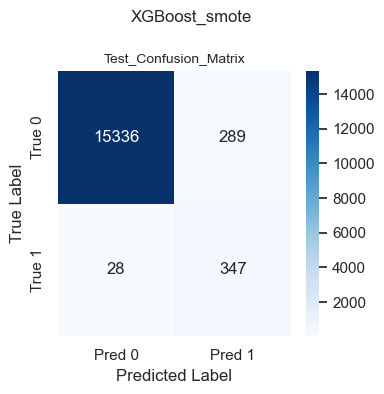

In [77]:
plot_confusion_matrix(model,cm_train, "Train_Confusion_Matrix")
plot_confusion_matrix(model,cm_test, "Test_Confusion_Matrix")

After applying SMOTE, the model significantly improves its ability to detect positive samples. The number of false negatives decreases substantially (from 108 to 28), indicating a much higher recall for the minority class.

However, this improvement comes at the cost of a large increase in false positives, leading to a higher overall misclassification error.

The AUC remains similar. This indicate that SMOTE focus more on the classification thresold and decision boundary.